In [ ]:
# In Jupyter Notebook
import sys
import os

sys.path.append(r"C:/Users/Phong/OneDrive - ICB Construction/Phong/data/Python_ETL/DS/ML_Models")
from experiments.run_model import run_experiment

# Run experiment
run_experiment(r"C:/Users/Phong/OneDrive - ICB Construction/Phong/data/Python_ETL/DS/ML_Models/configs/lightgbm_config.yaml")

In [ ]:
# In Jupyter Notebook
import sys
import os

# Set project path
project_path = r"C:/Users/Phong/OneDrive - ICB Construction/Phong/data/Python_ETL/DS/ML_Models"

# Change working directory to project folder
os.chdir(project_path)

# Add to path
sys.path.append(project_path)

from experiments.run_model import run_experiment

# Now relative path works
run_experiment("configs/xgboost_config.yaml")

In [ ]:
# In Jupyter cell
%run predictions/run_prediction.py --model models/catboost_model.pkl --config configs/catboost_config.yaml --data "C:/Users/Phong/OneDrive - ICB Construction/Phong/data/Python_ETL/DS/Database/Jobs to be Predicted.xlsx" --output "predictions/catboost_jobs_results.xlsx"

In [69]:
# Load data
import pandas as pd

job_data_path = r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Jobs Data.xlsx"

job_data_df = pd.read_excel(job_data_path)
job_data_df.describe()
job_data_df.columns


Index(['Job_Number', 'Job_Value', 'Contract_Establishment', 'Estimator',
       'Foreman', 'Job_Area', 'Main_Contractor', 'Suburb', 'Supervisor',
       'Job_Description', 'Saving_or_Loss', 'Timber_RW', 'RC_Piles',
       'Steel_Beam', 'Driven_Timber', 'Driven_Steel', 'Sheetpile', 'Anchors',
       'Blocks', 'Shotcrete', 'Capping_Beam', 'Walers', 'Earthworks',
       'Concrete_Slab', 'Precast', 'No_Wall_Types', 'Code',
       'Total_to_Date_Claimed', 'Amount_Increased', 'Adjusted_Savings',
       'Profitable'],
      dtype='object')

In [ ]:
# Linear Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# Split data into features and target
X = job_data_df.drop(['Estimator',
                      'Foreman', 
                      'Job_Area', 
                      'Main_Contractor', 
                      'Suburb', 
                      'Supervisor',
                      'Job_Description',
                      'Saving_or_Loss'], 
                      axis=1)

y = job_data_df['Saving_or_Loss']

# Train - Test data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
Y_pred = model.predict(X_test)

# Print Coefficients
print(f"Intercept: {model.intercept_}")
print(f"Slope: {model.coef_}")

# Evaluate
print(f"R² Score: {r2_score(y_test, Y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, Y_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, Y_pred):.4f}")

Z_pred = model.predict([[10000, 2000, 3000, 40000]])
print(Z_pred)


In [ ]:
# Polynomial Regression - Without Pipeline and Tuning

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import numpy as np
import pandas as pd

# Split data into features and target
X = job_data_df.drop(['Estimator',
                      'Foreman', 
                      'Job_Area', 
                      'Main_Contractor', 
                      'Suburb', 
                      'Supervisor',
                      'Job_Description',
                      'Saving_or_Loss'], 
                      axis=1)

y = job_data_df['Saving_or_Loss']

# Train - Test data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Polynomial features
degree = 2
poly = PolynomialFeatures(degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

# Train model on polynomial features
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

# Predict
Y_pred = model_poly.predict(X_test_poly)

# Print Coefficients
print(f'Intercept: {model_poly.intercept_}')
print(f'Coefficients: {model_poly.coef_}')


Z_pred = model.predict([[10000, 2000, 3000, 40000]])
print(Z_pred)


In [ ]:
# Polynomial Regression - With Pipeline but no Tuning

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# Split data into features and target
X = job_data_df.drop(['Estimator',
                      'Foreman', 
                      'Job_Area', 
                      'Main_Contractor', 
                      'Suburb', 
                      'Supervisor',
                      'Job_Description',
                      'Saving_or_Loss'], 
                      axis=1)

y = job_data_df['Saving_or_Loss']

# Train - Test data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create conprehensive pipeline
pipeline = Pipeline([
    # Step 1: Handle missing values
    ('imputer', SimpleImputer(strategy='median')),
    # Step 2: Scale features
    ('scaler', StandardScaler()),
    # Step 3: Create polynomial features
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    # Step 4: Final Estimator
    ('model', LinearRegression())
])

# Train model 
pipeline.fit(X_train, y_train)

# Predict
Y_pred = pipeline.predict(X_test)

# Model performance
score = pipeline.score(X_test, y_test)
print(f'R2 Score: {score}')

# Get parameters
params = pipeline.get_params()
print(params['poly__degree'])  # Access nested parameters

# Print Coefficients
print(f'Intercept: {pipeline.named_steps["model"].intercept_}')
print(f'Coefficients shape: {pipeline.named_steps["model"].coef_.shape}')
print(f'Coefficients: {pipeline.named_steps["model"].coef_}')


Z_pred = pipeline.predict([[10000, 2000, 3000, 40000]])
print(Z_pred)


In [ ]:
# Polynomial Regression - With Pipeline and Tuning

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1, Split data into features and target
X = job_data_df.drop(['Estimator',
                      'Foreman', 
                      'Job_Area', 
                      'Main_Contractor', 
                      'Suburb', 
                      'Supervisor',
                      'Job_Description',
                      'Saving_or_Loss'], 
                      axis=1)

y = job_data_df['Saving_or_Loss']

# 2, Train - Test data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3, Create pipeline with scaling and polynomial features + linear regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Important for polynomial features
    ('poly', PolynomialFeatures()),
    ('model', LinearRegression())
])

# 4, Define parameter grid
param_grid = {
    'poly__degree': [1, 2, 3, 4, 5],  # Try different polynomial degrees
    'poly__include_bias': [True, False],  # Include intercept term
    'poly__interaction_only': [True, False]  # Only interaction terms vs all terms
}

# 5, Perform grid search with cross-validation
grid_search = GridSearchCV(
    pipeline, 
    param_grid,
    cv=5,           # 5-fold cross-validation
    scoring='r2',   # Optimize for R-squared
    n_jobs=-1,      # Use all CPU cores
    verbose=1
)

print("performing Grid Search for best Polynomial parameter ...")

# 6, Train model
grid_search.fit(X_train, y_train)

  # Best parameters
print("\n" + "="*50)
print("BEST PARAMETERS FOUND:")
print("="*50)
print(f"Best Degree: {grid_search.best_params_['poly__degree']}")
print(f"Best include_bias: {grid_search.best_params_['poly__include_bias']}")
print(f"Best interaction_only: {grid_search.best_params_['poly__interaction_only']}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

  # Best model
best_poly_model = grid_search.best_estimator_

# 7, Predictions
y_pred = best_poly_model.predict(X_test)

# 8, Evaluate
print("\n" + "="*50)
print("MODEL EVALUATION ON TEST SET:")
print("="*50)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

# 9, Usage
Z_pred = model.predict([[10000, 2000, 3000, 40000]])
print(Z_pred)


In [ ]:
# Polynomial Regression - With Pipeline and Tuning and Encode for Categorical Features

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# 1, Define which columns are numeric and which are categorical
numeric_features = ['Job_Number', 'Job_Value', 'Total_Claimed', 'Total_Cost']
categorical_features = ['Estimator', 'Foreman', 'Supervisor']

# 2, Prepare the data
X = job_data_df[numeric_features + categorical_features]
y = job_data_df['Saving_or_Loss']

# 3, Data Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4, Create preprocessing for numeric columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 5, Create preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 6, Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 7, Create full pipeline with preprocessor, polu features and model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures()),
    ('model', Ridge())    
    # 'preprocessor__num__imputer__strategy': ['mean', 'median', 'most_frequent'] --For tuning imputer
])

# 8, Define parameter grid tuning
param_grid = {
    'poly__degree': [1, 2, 3, 4],
    #'poly__include_bias': [True, False],
    'poly__interaction_only': [True, False],
    'model__alpha': [0.1, 1.0, 10.0]  # Regularization strength
}

# 9, Perform grid search with cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1    
)

print("Performing Grid Search for the best parameters...")
grid_search.fit(X_train, y_train)


# 10. Best parameters
print("\n" + "="*70)
print("BEST PARAMETERS FOUND:")
print("="*70)
print(f"Best Degree: {grid_search.best_params_['poly__degree']}")
# print(f"Best include_bias: {grid_search.best_params_['poly__include_bias']}")
print(f"Best interaction_only: {grid_search.best_params_['poly__interaction_only']}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

# 11. Best model
best_model = grid_search.best_estimator_

# 12. Predictions
y_pred = best_model.predict(X_test)

# 13. Evaluate
print("\n" + "="*70)
print("MODEL EVALUATION ON TEST SET:")
print("="*70)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

# 14. Get feature information
preprocessor_fitted = best_model.named_steps['preprocessor']
poly_fitted = best_model.named_steps['poly']

# Get feature names after preprocessing
feature_names = []
for name, transformer, columns in preprocessor_fitted.transformers_:
    if name == 'num':
        feature_names.extend(columns)
    elif name == 'cat':
        # Get one-hot encoded feature names
        encoder = transformer.named_steps['onehot']
        feature_names.extend(encoder.get_feature_names_out(columns))

# Get polynomial feature names
poly_feature_names = poly_fitted.get_feature_names_out(feature_names)
print(f"\nTotal features after polynomial transformation: {len(poly_feature_names)}")
print(f"First 10 polynomial features: {poly_feature_names[:10]}")

# 15. Make predictions for new data WITH categorical variables
# Create new job data with both numeric and categorical values
new_job = pd.DataFrame({
    'Job_Number': [10003],
    'Job_Value': [300000], 
    'Total_Claimed': [200000], 
    'Total_Cost': [150000],
    'Estimator': ['John Doe'],  # Categorical
    'Foreman': ['Jane Smith'],  # Categorical
    'Supervisor': ['Bob Johnson']  # Categorical
})

Z_pred = best_model.predict(new_job)
print(f"\nPrediction for new job: ${Z_pred[0]:,.2f}")

#Categorical + Polynomial = Problems - One-hot encoded columns create sparse matrices that blow up with polynomial features
#Use interaction_only=True - This avoids x² terms which cause the most issues


In [ ]:
# POLYNOMIAL RIDGE REGRESSION PIPELINE (SAFE VERSION)
# ==========================================================

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# ==========================================================
# COLUMNS
# ==========================================================

binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]

numeric_features = ["Job_Value", "Contract_Establishment", "No_Wall_Types"]
categorical_features = ["Estimator", "Foreman", "Job_Area", "Main_Contractor", "Suburb", "Supervisor"]

X = job_data_df[binary_features + numeric_features + categorical_features]
y = job_data_df['Adjusted_Savings'] # Keeping target naming aligned

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================================
# PREPROCESSING SUB-PIPELINES
# ==========================================================

binary_transformer = SimpleImputer(strategy='constant', fill_value=0)

# SAFE PRACTICE: Polynomial features applied exclusively to numeric variables
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(include_bias=False)), # Dynamic tuning handled inside here
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine Preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('binary', binary_transformer, binary_features),
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Complete Operational Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())    
])

# ==========================================================
# HYPERPARAMETER TUNING BOUNDS
# ==========================================================

param_grid = {
    'preprocessor__num__poly__degree': [1, 2, 3], # Safely scales continuous terms
    'preprocessor__num__poly__interaction_only': [True, False],
    'model__alpha': [0.1, 1.0, 10.0, 50.0]  # Robust range for low-sample stabilization
}

grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1    
)

print("🚀 Starting Grid Search with safe numerical poly-isolation...")
grid_search.fit(X_train, y_train)

# ==========================================================
# BEST MODEL HIGHLIGHTS
# ==========================================================

print("\n" + "="*70)
print("🏆 OPTIMAL PARAMETERS FOUND")
print("="*70)
print(f"Best Numeric Degree      : {grid_search.best_params_['preprocessor__num__poly__degree']}")
print(f"Best Interaction Strategy: {grid_search.best_params_['preprocessor__num__poly__interaction_only']}")
print(f"Best Regularization Alpha: {grid_search.best_params_['model__alpha']}")
print(f"Best CV R² Score         : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# ==========================================================
# MODEL ASSESSMENT
# ==========================================================

y_pred = best_model.predict(X_test)

print("\n" + "="*70)
print("📊 PERFORMANCE EVALUATION ON TEST SET")
print("="*70)
print(f"R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE     : ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
print(f"MAE      : ${mean_absolute_error(y_test, y_pred):,.2f}")

# ==========================================================
# RECONSTRUCTING EXACT FEATURE NAME LIST
# ==========================================================

preprocessor_fitted = best_model.named_steps['preprocessor']

# Extract properly ordered, transformed columns
final_feature_names = []

# 1. Binary Features (Unchanged order)
final_feature_names.extend(binary_features)

# 2. Extract Polynomial Continuous Feature Names
num_pipeline = preprocessor_fitted.named_transformers_['num']
poly_step = num_pipeline.named_steps['poly']
num_features_out = poly_step.get_feature_names_out(numeric_features)
final_feature_names.extend(num_features_out)

# 3. Extract One-Hot Encoded Categorical Names
cat_pipeline = preprocessor_fitted.named_transformers_['cat']
onehot_step = cat_pipeline.named_steps['onehot']
cat_features_out = onehot_step.get_feature_names_out(categorical_features)
final_feature_names.extend(cat_features_out)

print(f"\nTotal structural attributes passed to Ridge model: {len(final_feature_names)}")

# ==========================================================
# TEST PREDICTION INPUT WITH UNIFIED COLUMNS
# ==========================================================

new_job_data = {col: [0] for col in binary_features}
new_job_data.update({
    'Job_Value': [300000], 
    'Contract_Establishment': [25000], 
    'No_Wall_Types': [2],
    'Estimator': ['John Doe'],  
    'Foreman': ['Jane Smith'],  
    'Job_Area': ['Auckland'],
    'Main_Contractor': ['Tier 1 Build'],
    'Suburb': ['Central'],
    'Supervisor': ['Bob Johnson']
})

# Turn specific binary indicators on
new_job_data['Steel_Beam'] = [1]
new_job_data['Concrete_Slab'] = [1]

new_job = pd.DataFrame(new_job_data)

# Reorder columns to match original operational structure
new_job = new_job[binary_features + numeric_features + categorical_features]

prediction = best_model.predict(new_job)
print(f"\n🔮 Corrected Inference Prediction for New Job: ${prediction[0]:,.2f}")

In [ ]:
# Regularized Polynomial Regression

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
X = job_data_df.drop(['Estimator', 'Foreman', 'Job_Area', 'Main_Contractor', 
                      'Suburb', 'Supervisor', 'Job_Description', 'Saving_or_Loss'], axis=1)
y = job_data_df['Saving_or_Loss']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create base pipeline (without regularization for comparison)
base_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

# Ridge pipeline
ridge_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1.0))
])

# Lasso pipeline
lasso_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lasso', Lasso(alpha=1.0, max_iter=10000))
])

# ElasticNet pipeline
elastic_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('elastic', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))
])

# Train all models
base_pipeline.fit(X_train, y_train)
ridge_pipeline.fit(X_train, y_train)
lasso_pipeline.fit(X_train, y_train)
elastic_pipeline.fit(X_train, y_train)

# Compare results
print("="*60)
print("MODEL COMPARISON (Without Hyperparameter Tuning)")
print("="*60)

models = {
    'Linear Regression (No Reg)': base_pipeline,
    'Ridge (L2)': ridge_pipeline,
    'Lasso (L1)': lasso_pipeline,
    'ElasticNet (L1+L2)': elastic_pipeline
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Get coefficient statistics
    if 'ridge' in model.named_steps:
        coef = model.named_steps['ridge'].coef_
    elif 'lasso' in model.named_steps:
        coef = model.named_steps['lasso'].coef_
    elif 'elastic' in model.named_steps:
        coef = model.named_steps['elastic'].coef_
    else:
        coef = model.named_steps['model'].coef_
    
    print(f"\n{name}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  Non-zero coeffs: {np.sum(coef != 0)} / {len(coef)}")
    print(f"  Max coefficient: {np.abs(coef).max():.2f}")
    print(f"  Mean coefficient: {np.abs(coef).mean():.2f}")

In [ ]:
# Regularized Polynomial Regression - Tuning

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
X = job_data_df.drop(['Estimator', 'Foreman', 'Job_Area', 'Main_Contractor', 
                      'Suburb', 'Supervisor', 'Job_Description', 'Saving_or_Loss'], axis=1)
y = job_data_df['Saving_or_Loss']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge pipeline
ridge_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1.0))
])

# Lasso pipeline
lasso_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lasso', Lasso(alpha=1.0, max_iter=10000))
])

# ElasticNet pipeline
elastic_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('elastic', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))
])

# Ridge Hyperparameter Tuning
print("\n" + "="*60)
print("RIDGE REGRESSION TUNING")
print("="*60)

ridge_param_grid = {
    'poly__degree': [1, 2, 3, 4],
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'ridge__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag']
}

ridge_search = GridSearchCV(
    ridge_pipeline, 
    ridge_param_grid, 
    cv=5, 
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
ridge_search.fit(X_train, y_train)

print(f"Best Ridge Parameters: {ridge_search.best_params_}")
print(f"Best Ridge CV R²: {ridge_search.best_score_:.4f}")
print(f"Ridge Test R²: {ridge_search.score(X_test, y_test):.4f}")

# Lasso Hyperparameter Tuning
print("\n" + "="*60)
print("LASSO REGRESSION TUNING")
print("="*60)

lasso_param_grid = {
    'poly__degree': [1, 2, 3],
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'lasso__selection': ['cyclic', 'random']
}

lasso_search = GridSearchCV(
    lasso_pipeline, 
    lasso_param_grid, 
    cv=5, 
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
lasso_search.fit(X_train, y_train)

print(f"Best Lasso Parameters: {lasso_search.best_params_}")
print(f"Best Lasso CV R²: {lasso_search.best_score_:.4f}")
print(f"Lasso Test R²: {lasso_search.score(X_test, y_test):.4f}")

# Count features selected by Lasso
best_lasso = lasso_search.best_estimator_
lasso_coef = best_lasso.named_steps['lasso'].coef_
print(f"Features selected by Lasso: {np.sum(lasso_coef != 0)} / {len(lasso_coef)}")

# ElasticNet Hyperparameter Tuning
print("\n" + "="*60)
print("ELASTICNET REGRESSION TUNING")
print("="*60)

elastic_param_grid = {
    'poly__degree': [1, 2, 3],
    'elastic__alpha': [0.001, 0.01, 0.1, 1, 10],
    'elastic__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],  # 0=Ridge, 1=Lasso
    'elastic__selection': ['cyclic', 'random']
}

elastic_search = GridSearchCV(
    elastic_pipeline, 
    elastic_param_grid, 
    cv=5, 
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
elastic_search.fit(X_train, y_train)

print(f"Best ElasticNet Parameters: {elastic_search.best_params_}")
print(f"Best ElasticNet CV R²: {elastic_search.best_score_:.4f}")
print(f"ElasticNet Test R²: {elastic_search.score(X_test, y_test):.4f}")

# Compare all tuned models
print("\n" + "="*60)
print("FINAL COMPARISON (Tuned Models)")
print("="*60)

tuned_models = {
    'Ridge (Tuned)': ridge_search,
    'Lasso (Tuned)': lasso_search,
    'ElasticNet (Tuned)': elastic_search
}

best_r2 = -np.inf
best_name = None
best_model = None

for name, model in tuned_models.items():
    test_r2 = model.score(X_test, y_test)
    print(f"\n{name}:")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Best Params: {model.best_params_}")
    
    if test_r2 > best_r2:
        best_r2 = test_r2
        best_name = name
        best_model = model

print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_name} with R² = {best_r2:.4f}")
print("="*60)

In [ ]:
# Visualize the effect of alpha on coefficients
import matplotlib.pyplot as plt

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
coefficient_paths = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2)),
        ('ridge', ridge)
    ])
    ridge_pipeline.fit(X_train, y_train)
    coefs = ridge_pipeline.named_steps['ridge'].coef_
    coefficient_paths.append(coefs)

coefficient_paths = np.array(coefficient_paths)

# Plot coefficient paths
plt.figure(figsize=(10, 6))
for i in range(min(10, coefficient_paths.shape[1])):  # Plot first 10 coefficients
    plt.plot(alphas, coefficient_paths[:, i], label=f'Feature {i}')

plt.xscale('log')
plt.xlabel('Alpha (regularization strength)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Coefficient Paths\n(As alpha increases, coefficients shrink toward zero)')
plt.legend(loc='best', ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1, Define which columns are numeric and which are categorical
binary_job_type_feature = [
    'Timber_RW', 'RC_Piles', 'Steel_Beam', 'Driven_Timber',	'Driven_Steel',
    'Sheetpile', 'Anchors',	'Blocks', 'Shotcrete', 'Capping_Beam', 'Walers',
    'Earthworks', 'Concrete_Slab',	'Precast'
]
numeric_features = ['Job_Number', 'Job_Value', 'Contract_Establishment', 'No_Wall_Types']
categorical_features = ['Estimator', 'Foreman', 'Job_Area', 'Main_Contractor', 'Suburb', 'Supervisor']

# 2, Prepare the data
X = job_data_df[numeric_features + categorical_features + binary_job_type_feature]
y = job_data_df['Adjusted_Savings']

# 3, Data Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4, Create preprocessing for numeric and binary columns
binary_transformer = SimpleImputer(strategy='constant', fill_value=0)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# 5, Create preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 6, Combined preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('binary', binary_transformer, binary_job_type_feature),
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 7. Create the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeRegressor(random_state=42))
])
    
# 8, Param Grid
param_grid = {
    'dt__max_depth': [8, 10, 12, 15],  # Moderate depths
    'dt__min_samples_split': [5, 10, 15, 20],  # Moderate splits
    'dt__min_samples_leaf': [2, 3, 5, 8],  # Moderate leaf sizes
    'dt__max_features': ['sqrt', 'log2'],  # Not None
    'dt__criterion': ['squared_error', 'absolute_error'],
    'dt__min_impurity_decrease': [0.0, 0.001, 0.005, 0.01],
    'dt__ccp_alpha': [0.0, 0.0001, 0.001, 0.005, 0.01]  # Small pruning values
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Performing Grid Search for Decision Tree...")
grid_search.fit(X_train, y_train)

print("\n" + "="*60)
print("BEST DECISION TREE PARAMETERS")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV R²: {grid_search.best_score_:.4f}")

# 10, Best model
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)

# 11, Evaluate
print("="*60)
print("DECISION TREE WITH CATEGORICAL FEATURES")
print("="*60)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")

# 12. Baseline comparison
y_test_mean = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, y_test_mean)
baseline_r2 = r2_score(y_test, y_test_mean)

print("\n" + "="*60)
print("BASELINE COMPARISON")
print("="*60)
print(f"Baseline (predict mean) MAE: {baseline_mae:.2f}")
print(f"Model MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Improvement: {((baseline_mae - mean_absolute_error(y_test, y_pred)) / baseline_mae * 100):.1f}%")

if mean_absolute_error(y_test, y_pred) < baseline_mae:
    print("✅ Model learned useful patterns (better than baseline)")
else:
    print("❌ Model failed to learn (worse than baseline)")



'''
# 8. Find optimal alpha for pruning (FIXED: need to fit on processed data)
# First, preprocess the data to find ccp_alphas
X_train_processed = preprocessor.fit_transform(X_train)
path = DecisionTreeRegressor().cost_complexity_pruning_path(X_train_processed, y_train)
ccp_alphas = path.ccp_alphas
# Take only reasonable alphas (avoid too many or too large)
ccp_alphas = ccp_alphas[ccp_alphas < 0.1]  # Limit alpha range
if len(ccp_alphas) > 20:  # Limit number of alphas
    ccp_alphas = np.linspace(ccp_alphas[0], ccp_alphas[-1], 20)
'''


In [ ]:
# Decision Tree Regression - With RandomizedSearchCV

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Define which columns are numeric, binary, and categorical
binary_job_type_feature = [
    'Timber_RW', 'RC_Piles', 'Steel_Beam', 'Driven_Timber', 'Driven_Steel',
    'Sheetpile', 'Anchors', 'Blocks', 'Shotcrete', 'Capping_Beam', 'Walers',
    'Earthworks', 'Concrete_Slab', 'Precast'
]

numeric_features = ['Job_Number', 'Job_Value', 'Contract_Establishment', 'No_Wall_Types']
categorical_features = ['Estimator', 'Foreman', 'Job_Area', 'Main_Contractor', 'Suburb', 'Supervisor']

# 2. Prepare the data
X = job_data_df[numeric_features + categorical_features + binary_job_type_feature]
y = job_data_df['Adjusted_Savings']

# 3. Data Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check for missing values
missing_counts = X_train.isnull().sum()
if missing_counts.sum() > 0:
    print("\nColumns with missing values:")
    print(missing_counts[missing_counts > 0])
else:
    print("\n✅ No missing values found in training data")

# 4. Create preprocessing for numeric and binary columns
# Binary features - just impute with 0 (no scaling needed for trees)
binary_transformer = SimpleImputer(strategy='constant', fill_value=0)

# Numeric features - impute with median (no scaling needed for trees)
numeric_transformer = SimpleImputer(strategy='median')

# 5. Create preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 6. Combined preprocessor - FIXED: Added comma between transformers!
preprocessor = ColumnTransformer(
    transformers=[
        ('binary', binary_transformer, binary_job_type_feature),  
        ('num', numeric_transformer, numeric_features),           
        ('cat', categorical_transformer, categorical_features)  
    ]
)

# 7. Create the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeRegressor(random_state=42))
])

# 8. Param Grid - Balanced for your data
param_grid = {
    'dt__max_depth': [8, 10, 12, 15],  # Moderate depths
    'dt__min_samples_split': [5, 10, 15, 20],  # Moderate splits
    'dt__min_samples_leaf': [2, 3, 5, 8],  # Moderate leaf sizes
    'dt__max_features': ['sqrt', 'log2'],  # Not None for randomness
    'dt__criterion': ['squared_error', 'absolute_error'],
    'dt__min_impurity_decrease': [0.0, 0.001, 0.005, 0.01],
    'dt__ccp_alpha': [0.0, 0.0001, 0.001, 0.005, 0.01]  # Small pruning values
}

# Calculate total combinations
total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal parameter combinations: {total_combinations:,}")

# Reduce grid if too large
if total_combinations > 1000:
    print("⚠️ Large grid detected. Consider reducing parameters for faster search.")
    # Option: Use RandomizedSearchCV instead
    print("Using RandomizedSearchCV for efficiency...")
    
    grid_search = RandomizedSearchCV(
        pipeline,
        param_grid,
        n_iter=100,  # Try 100 random combinations
        cv=5,
        scoring='r2',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
else:
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )

print("\nPerforming Grid Search for Decision Tree...")
grid_search.fit(X_train, y_train)

# 9. Best parameters
print("\n" + "="*60)
print("BEST DECISION TREE PARAMETERS")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV R²: {grid_search.best_score_:.4f}")

# 10. Best model
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)

# 11. Evaluate
print("\n" + "="*60)
print("DECISION TREE PERFORMANCE")
print("="*60)
test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {test_r2:.4f}")
print(f"RMSE: ${test_rmse:,.2f}")
print(f"MAE: ${test_mae:,.2f}")

# 12. Baseline comparison
y_test_mean = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, y_test_mean)
baseline_r2 = r2_score(y_test, y_test_mean)

print("\n" + "="*60)
print("BASELINE COMPARISON")
print("="*60)
print(f"Baseline (predict mean) MAE: ${baseline_mae:,.2f}")
print(f"Model MAE: ${test_mae:,.2f}")
print(f"Improvement: {((baseline_mae - test_mae) / baseline_mae * 100):.1f}%")

if test_mae < baseline_mae:
    print("✅ Model learned useful patterns (better than baseline)")
else:
    print("❌ Model failed to learn (worse than baseline)")

# 13. Overfitting check
train_pred = best_dt.predict(X_train)
train_r2 = r2_score(y_train, train_pred)
overfit_gap = train_r2 - test_r2

print("\n" + "="*60)
print("OVERFITTING ANALYSIS")
print("="*60)
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Overfitting Gap: {overfit_gap:.4f}")

if overfit_gap > 0.2:
    print("⚠️ HIGH OVERFITTING - Model is too complex")
    print("   Consider: reducing max_depth, increasing min_samples_split")
elif overfit_gap > 0.1:
    print("⚠️ MODERATE OVERFITTING - Some regularization needed")
else:
    print("✅ Good generalization - Model complexity is appropriate")

# 14. Cross-validation score
cv_scores = cross_val_score(best_dt, X_train, y_train, cv=5, scoring='r2')
print(f"\nCross-validation R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# 15. Feature importance
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

# Get feature names after preprocessing
feature_names = []
for name, transformer, columns in best_dt.named_steps['preprocessor'].transformers_:
    if name == 'binary':
        feature_names.extend(columns)
    elif name == 'num':
        feature_names.extend(columns)
    elif name == 'cat':
        # Get one-hot encoded feature names
        encoder = transformer.named_steps['onehot']
        feature_names.extend(encoder.get_feature_names_out(columns))

# Get importance
importances = best_dt.named_steps['dt'].feature_importances_

# Create and sort importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 15 most important features:")
print(importance_df.head(15).to_string(index=False))

# 16. Tree statistics
tree_depth = best_dt.named_steps['dt'].get_depth()
tree_nodes = best_dt.named_steps['dt'].tree_.node_count
tree_leaves = best_dt.named_steps['dt'].get_n_leaves()

print(f"\nTree Statistics:")
print(f"  Depth: {tree_depth}")
print(f"  Number of nodes: {tree_nodes}")
print(f"  Number of leaves: {tree_leaves}")


✅ No missing values found in training data

Total parameter combinations: 5,120
⚠️ Large grid detected. Consider reducing parameters for faster search.
Using RandomizedSearchCV for efficiency...

Performing Grid Search for Decision Tree...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

BEST DECISION TREE PARAMETERS
dt__min_samples_split: 5
dt__min_samples_leaf: 5
dt__min_impurity_decrease: 0.01
dt__max_features: sqrt
dt__max_depth: 10
dt__criterion: absolute_error
dt__ccp_alpha: 0.0001

Best CV R²: 0.0026

DECISION TREE PERFORMANCE
R² Score: 0.1461
RMSE: $78,631.74
MAE: $38,222.69

BASELINE COMPARISON
Baseline (predict mean) MAE: $41,533.61
Model MAE: $38,222.69
Improvement: 8.0%
✅ Model learned useful patterns (better than baseline)

OVERFITTING ANALYSIS
Train R²: 0.0364
Test R²: 0.1461
Overfitting Gap: -0.1097
✅ Good generalization - Model complexity is appropriate

Cross-validation R²: 0.0026 (+/- 0.0662)

FEATURE IMPORTANCE
Top 15 most important features:
        

In [5]:
# Random Forest Regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ===============================================================================================
# Feature Engineering
# ===============================================================================================
# 1, Create more meaningful features from existing ones
def engineer_features(df):
    """Create additional features to improve predictive power"""
    df_eng = df.copy()
        
    # 1.1 Project Required Drill
    df_eng['Required_Drill_Job'] = (
        (df_eng['Steel_Beam'] == 1) | 
        (df_eng['RC_Piles'] == 1) | 
        (df_eng['Timber_RW'] == 1)
    ).astype(int)

    # 1.2 Project Required Attachments
    df_eng['Required_Attachments_Job'] = (
        (df_eng['Driven_Timber'] == 1) | 
        (df_eng['Driven_Steel'] == 1) | 
        (df_eng['Sheetpile'] == 1)
    ).astype(int)
        
    # 1.3 Establishment and Total Value Ratio
    df_eng['Est_to_Total_Value_Ratio'] = df_eng['Contract_Establishment'] / df_eng['Job_Value']
    
    # 1.4 Project size category
    df_eng['Job_Value_Category'] = pd.cut(
        df_eng['Job_Value'],
        bins=[0, 100000, 500000, 1000000, float('inf')],
        labels=['Small', 'Medium', 'Large', 'Very Large']
    )
    
    return df_eng

# Apply feature engineering
job_data_df_eng = engineer_features(job_data_df)

# 2, Group rare categories into 'Other' to prevent overfitting
def group_rare_categories(df, column, min_frequency=0.05):
    """
    Group rare categories into 'Other' to prevent overfitting
    """
    # Calculate frequency
    freq = df[column].value_counts(normalize=True) # normalize=true to return proportions of count values
    
    # Identify rare categories
    rare_categories = freq[freq < min_frequency].index.tolist() # create a list of all rare categories
    
    # Group them
    df_clean = df.copy()
    df_clean[column] = df_clean[column].apply(
        lambda x: 'Other' if x in rare_categories else x
    )
    
    print(f"{column}: Grouped {len(rare_categories)} rare categories into 'Other'")
    return df_clean

# Apply to categorical columns
categorical_features_to_group = ['Estimator', 'Foreman', 'Main_Contractor', 'Supervisor', 'Suburb']

for col in categorical_features_to_group:
    job_data_df_eng = group_rare_categories(job_data_df_eng, col, min_frequency=0.03)

# ================================================================================================
# Model Training
# ================================================================================================

# 1. Define which columns are numeric, binary, and categorical
binary_job_type_feature = [
    'Timber_RW', 'RC_Piles', 'Steel_Beam', 'Driven_Timber', 'Driven_Steel',
    'Sheetpile', 'Anchors', 'Blocks', 'Shotcrete', 'Capping_Beam', 'Walers',
    'Earthworks', 'Concrete_Slab', 'Precast', 'Required_Attachments_Job', 'Required_Drill_Job'
]

numeric_features = ['Job_Number', 'Job_Value', 'Contract_Establishment', 'No_Wall_Types', 'Est_to_Total_Value_Ratio']
categorical_features = ['Estimator', 'Foreman', 'Job_Area', 'Main_Contractor', 'Suburb', 'Supervisor', 'Job_Value_Category']

# 2. Prepare the data
X = job_data_df_eng[numeric_features + categorical_features + binary_job_type_feature]
y = job_data_df_eng['Adjusted_Savings']

# 3. Data Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check for missing values
missing_counts = X_train.isnull().sum()
if missing_counts.sum() > 0:
    print("\nColumns with missing values:")
    print(missing_counts[missing_counts > 0])
else:
    print("\n✅ No missing values found in training data")

# 4 Create preprocessing for numeric and binary columns
binary_transformer = SimpleImputer(strategy='constant', fill_value=0)
numeric_transformer = SimpleImputer(strategy='median')

# 5 Create prprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 6 Combine preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('binary', binary_transformer, binary_job_type_feature),  
        ('num', numeric_transformer, numeric_features),           
        ('cat', categorical_transformer, categorical_features) 
    ]
)

# 7 Create Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(random_state=42))
])

# 8 Param Grid
rf_param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [10, 15, None],
    'rf__min_samples_split': [5, 10, 20],
    'rf__min_samples_leaf': [2, 5, 10],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__bootstrap': [True]
}

rf_search = RandomizedSearchCV(
    rf_pipeline, 
    rf_param_grid, 
    n_iter=100,
    cv=5, 
    scoring='r2', 
    n_jobs=-1,
    random_state=42,
    verbose=1
)   

rf_search.fit(X_train, y_train)

# 9 Best parameters
print("\n" + "="*60)
print("Best Random Forest Tree Parameters")
print("="*60)
for param, value in rf_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV R2: {rf_search.best_score_:.4f}")

# 10 Best model
best_rf = rf_search.best_estimator_
y_pred = best_rf.predict(X_test)

# 11. Evaluate
print("\n" + "="*60)
print("DECISION TREE PERFORMANCE")
print("="*60)
test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {test_r2:.4f}")
print(f"RMSE: ${test_rmse:,.2f}")
print(f"MAE: ${test_mae:,.2f}")

# 12. Baseline comparison
y_test_mean = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, y_test_mean)
baseline_r2 = r2_score(y_test, y_test_mean)

print("\n" + "="*60)
print("BASELINE COMPARISON")
print("="*60)
print(f"Baseline (predict mean) MAE: ${baseline_mae:,.2f}")
print(f"Model MAE: ${test_mae:,.2f}")
print(f"Improvement: {((baseline_mae - test_mae) / baseline_mae * 100):.1f}%")

if test_mae < baseline_mae:
    print("✅ Model learned useful patterns (better than baseline)")
else:
    print("❌ Model failed to learn (worse than baseline)")

# 13. Cross-validation score
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='r2')
print(f"\nCross-validation R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# 14. Feature importance
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

# Get feature names after preprocessing
feature_names = []
for name, transformer, columns in best_rf.named_steps['preprocessor'].transformers_:
    if name == 'binary':
        feature_names.extend(columns)
    elif name == 'num':
        feature_names.extend(columns)
    elif name == 'cat':
        # Get one-hot encoded feature names
        encoder = transformer.named_steps['onehot']
        feature_names.extend(encoder.get_feature_names_out(columns))

# Get importance
importances = best_rf.named_steps['rf'].feature_importances_

# Create and sort importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 15 most important features:")
print(importance_df.head(15).to_string(index=False))

Estimator: Grouped 0 rare categories into 'Other'
Foreman: Grouped 0 rare categories into 'Other'
Main_Contractor: Grouped 0 rare categories into 'Other'
Supervisor: Grouped 0 rare categories into 'Other'
Suburb: Grouped 0 rare categories into 'Other'

✅ No missing values found in training data
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Random Forest Tree Parameters
rf__n_estimators: 50
rf__min_samples_split: 20
rf__min_samples_leaf: 2
rf__max_features: sqrt
rf__max_depth: 10
rf__bootstrap: True

Best CV R2: 0.0540

DECISION TREE PERFORMANCE
R² Score: 0.0657
RMSE: $82,250.28
MAE: $43,221.64

BASELINE COMPARISON
Baseline (predict mean) MAE: $41,533.61
Model MAE: $43,221.64
Improvement: -4.1%
❌ Model failed to learn (worse than baseline)

Cross-validation R²: 0.0540 (+/- 0.1728)

FEATURE IMPORTANCE
Top 15 most important features:
                      feature  importance
                    Job_Value    0.315212
     Est_to_Total_Value_Ratio    0.131792
        

In [ ]:
# Create more meaningful features from existing ones

def engineer_features(df):
    """Create additional features to improve predictive power"""
    
    df_eng = df.copy()
        
    # 1. Project Required Drill
    df_eng['Required_Drill_Job'] = (
        (df_eng['Steel_Beam'] == 1) | 
        (df_eng['RC_Piles'] == 1) | 
        (df_eng['Timber_RW'] == 1)
    ).astype(int)

    # 2. Project Required Attachments
    df_eng['Required_Attachments_Job'] = (
        (df_eng['Driven_Timber'] == 1) | 
        (df_eng['Driven_Steel'] == 1) | 
        (df_eng['Sheetpile'] == 1)
    ).astype(int)
        
    # 3. Establishment and Total Value Ratio
    df_eng['Est_to_Total_Value_Ratio'] = df_eng['Contract_Establishment'] / df_eng['Job_Value']
    
    # 4. Project size category
    df_eng['Job_Value_Category'] = pd.cut(
        df_eng['Job_Value'],
        bins=[0, 100000, 500000, 1000000, float('inf')],
        labels=['Small', 'Medium', 'Large', 'Very Large']
    )
    
    return df_eng

# Apply feature engineering
job_data_df_eng = engineer_features(job_data_df)

job_data_df_eng.head()

In [ ]:
# Group rare categories into Other to prevent overfitting

def group_rare_categories(df, column, min_frequency=0.05):
    """
    Group rare categories into 'Other' to prevent overfitting
    """
    # Calculate frequency
    freq = df[column].value_counts(normalize=True) # normalize=true to return proportions of count values
    
    # Identify rare categories
    rare_categories = freq[freq < min_frequency].index.tolist() # create a list of all rare categories
    
    # Group them
    df_clean = df.copy()
    df_clean[column] = df_clean[column].apply(
        lambda x: 'Other' if x in rare_categories else x
    )
    
    print(f"{column}: Grouped {len(rare_categories)} rare categories into 'Other'")
    return df_clean

# Apply to categorical columns
categorical_features_to_group = ['Estimator', 'Foreman', 'Main_Contractor', 'Supervisor', 'Suburb']

for col in categorical_features_to_group:
    job_data_df = group_rare_categories(job_data_df, col, min_frequency=0.03)

job_data_df.head(20)

In [44]:
# ✅ # Random Forest Regression - CORRECT - No Data Leakage

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ================================================================================================
# Custom Transformers for Feature Engineering
# ================================================================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Custom transformer for feature engineering
    """
    def __init__(self):
        # Stores binary feature names
        self.binary_cols = [
            'Timber_RW', 'RC_Piles', 'Steel_Beam', 'Driven_Timber', 'Driven_Steel',
            'Sheetpile', 'Anchors', 'Blocks', 'Shotcrete', 'Capping_Beam', 'Walers',
            'Earthworks', 'Concrete_Slab', 'Precast'
        ]
        # Stores numeric feature names
        self.numeric_cols = ['Contract_Establishment', 'Job_Value']
        self.feature_names_ = None # Create an attribute
        
    def fit(self, X, y=None):
        # Just return self - no fitting needed
        return self
    
    def transform(self, X):
        X_eng = X.copy()
        
        # 1. Required Drill Job
        X_eng['Required_Drill_Job'] = (
            (X_eng['Steel_Beam'] == 1) | 
            (X_eng['RC_Piles'] == 1) | 
            (X_eng['Timber_RW'] == 1)
        ).astype(int)
        
        # 2. Required Attachments Job
        X_eng['Required_Attachments_Job'] = (
            (X_eng['Driven_Timber'] == 1) | 
            (X_eng['Driven_Steel'] == 1) | 
            (X_eng['Sheetpile'] == 1)
        ).astype(int)
        
        # 3. Establishment to Total Value Ratio
        X_eng['Est_to_Total_Value_Ratio'] = X_eng['Contract_Establishment'] / X_eng['Job_Value']
        
        # 4. Total Material Types
        X_eng['Total_Material_Types'] = X_eng[self.binary_cols].sum(axis=1)
        
        # 5. Complex Structure
        X_eng['Has_Complex_Structure'] = (
            (X_eng['Steel_Beam'] == 1) & 
            (X_eng['Concrete_Slab'] == 1) & 
            (X_eng['RC_Piles'] == 1)
        ).astype(int)
        
        # 6. Job Value Category (binning)
        X_eng['Job_Value_Category'] = pd.cut(
            X_eng['Job_Value'],
            bins=[0, 100000, 500000, 1000000, float('inf')],
            labels=['Small', 'Medium', 'Large', 'Very Large']
        )
        
        return X_eng

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """
    Group rare categories in categorical columns
    """
    def __init__(self, columns, min_frequency=0.03):
        self.columns = columns
        self.min_frequency = min_frequency
        self.rare_categories_ = {}  # attribute, initial empty, fill after fitting
        
    def fit(self, X, y=None):
        # Identify rare categories using ONLY training data
        for col in self.columns:
            if col in X.columns:
                freq = X[col].value_counts(normalize=True)
                rare = freq[freq < self.min_frequency].index.tolist()
                self.rare_categories_[col] = rare
        return self  # store back to self.rare_categories_
    
    def transform(self, X):
        X_clean = X.copy()
        for col in self.columns:
            if col in X_clean.columns and col in self.rare_categories_:
                rare = self.rare_categories_[col]
                X_clean[col] = X_clean[col].apply(
                    lambda x: 'Other' if x in rare else x
                )
        return X_clean

# ================================================================================================
# Complete Pipeline with Feature Engineering
# ================================================================================================

# 1. Define columns
binary_job_type_feature = [
    'Timber_RW', 'RC_Piles', 'Steel_Beam', 'Driven_Timber', 'Driven_Steel',
    'Sheetpile', 'Anchors', 'Blocks', 'Shotcrete', 'Capping_Beam', 'Walers',
    'Earthworks', 'Concrete_Slab', 'Precast'
]

numeric_features = ['Job_Value', 'Contract_Establishment', 'No_Wall_Types']
categorical_features = ['Estimator', 'Foreman', 'Job_Area', 'Main_Contractor', 'Suburb', 'Supervisor']

# 2. Prepare data (NO feature engineering here!)
X = job_data_df[numeric_features + categorical_features + binary_job_type_feature]
y = job_data_df['Adjusted_Savings']

# 3. Split FIRST - this is critical!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Create preprocessing pipeline
# Preprocessing for binary columns
binary_transformer = SimpleImputer(strategy='constant', fill_value=0)

# Preprocessing for numeric columns
numeric_transformer = SimpleImputer(strategy='median')

# Preprocessing for categorical columns
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 5. Create ColumnTransformer
preprocessor = ColumnTransformer([
    ('binary', binary_transformer, binary_job_type_feature),
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# 6. Create FULL pipeline with feature engineering

rf_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineer()),  # Custom transformer
    ('rare_category_grouper', RareCategoryGrouper(
        columns=['Estimator', 'Foreman', 'Main_Contractor', 'Supervisor', 'Suburb'],
        min_frequency=0.03
    )),
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# 8 Param Grid
rf_param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [10, 15, None],
    'rf__min_samples_split': [5, 10, 20],
    'rf__min_samples_leaf': [2, 5, 10],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__bootstrap': [True]
}

rf_search = RandomizedSearchCV(
    rf_pipeline, 
    rf_param_grid, 
    n_iter=100,
    cv=5, 
    scoring='r2', 
    n_jobs=-1,
    random_state=42,
    verbose=1
)   

# 7. Train (NO data leakage!)
print("Training with NO data leakage...")
rf_search.fit(X_train, y_train)
# 9 Best parameters
print("\n" + "="*60)
print("Best Random Forest Tree Parameters")
print("="*60)
for param, value in rf_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV R2: {rf_search.best_score_:.4f}")

# 10 Best model
best_rf = rf_search.best_estimator_
y_pred = best_rf.predict(X_test)

# 11. Evaluate
print("\n" + "="*60)
print("DECISION TREE PERFORMANCE")
print("="*60)
test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {test_r2:.4f}")
print(f"RMSE: ${test_rmse:,.2f}")
print(f"MAE: ${test_mae:,.2f}")

# 12. Baseline comparison
y_test_mean = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, y_test_mean)
baseline_r2 = r2_score(y_test, y_test_mean)

print("\n" + "="*60)
print("BASELINE COMPARISON")
print("="*60)
print(f"Baseline (predict mean) MAE: ${baseline_mae:,.2f}")
print(f"Model MAE: ${test_mae:,.2f}")
print(f"Improvement: {((baseline_mae - test_mae) / baseline_mae * 100):.1f}%")

if test_mae < baseline_mae:
    print("✅ Model learned useful patterns (better than baseline)")
else:
    print("❌ Model failed to learn (worse than baseline)")

Training with NO data leakage...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Random Forest Tree Parameters
rf__n_estimators: 50
rf__min_samples_split: 10
rf__min_samples_leaf: 2
rf__max_features: sqrt
rf__max_depth: None
rf__bootstrap: True

Best CV R2: 0.0285

DECISION TREE PERFORMANCE
R² Score: 0.0187
RMSE: $84,292.83
MAE: $44,291.78

BASELINE COMPARISON
Baseline (predict mean) MAE: $41,533.61
Model MAE: $44,291.78
Improvement: -6.6%
❌ Model failed to learn (worse than baseline)


In [ ]:
# Make prediction from data file

import pandas as pd
import joblib

# Load test data
test_path = r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Jobs Data - Test.xlsx"
df_test = pd.read_excel(test_path)

# Split X (same features as training)
X_test = df_test[numeric_features + categorical_features + binary_job_type_feature]

# Load trained model (IMPORTANT: pipeline object)
model = best_rf   # or joblib.load("rf_model.pkl")

# Predict
predictions = model.predict(X_test)

df_test["Predictions"] = predictions

print(df_test.head(9))

In [ ]:
# XGBoost - REAL EXAMPLE CALCULATION: Predicting Construction Savings
# ================================================================================================

import numpy as np
import pandas as pd

# Sample data (simplified)
data = pd.DataFrame({
    'Job_Value': [100000, 200000, 150000, 250000, 180000],
    'Labor_Hours': [1000, 1500, 1200, 1800, 1400],
    'Actual_Saving': [10000, 15000, 12000, 18000, 14000]
})

print("Training Data:")
print(data)

# ================================================================================================
# STEP 1: Initial Prediction (F₀)
# ================================================================================================

# In XGBoost, initial prediction is the mean
F0 = data['Actual_Saving'].mean()
print(f"\nStep 1: Initial Prediction F₀ = {F0:.2f}")

# ================================================================================================
# STEP 2: Calculate Residuals (Errors)
# ================================================================================================

data['Residual'] = data['Actual_Saving'] - F0
print(f"\nStep 2: Residuals (Actual - Prediction)")
print(data[['Actual_Saving', 'Residual']])

# ================================================================================================
# STEP 3: Calculate Gradients and Hessians
# ================================================================================================

# For MSE loss: L = (y - ŷ)²
# Gradient: g = ∂L/∂ŷ = -2(y - ŷ)
# Hessian: h = ∂²L/∂ŷ² = 2

data['Gradient'] = -2 * data['Residual']  # g = -2 * residual
data['Hessian'] = 2  # h = 2 (constant for MSE)

print(f"\nStep 3: Gradients and Hessians")
print(data[['Residual', 'Gradient', 'Hessian']])

# ================================================================================================
# STEP 4: Build a Tree to Predict Residuals
# ================================================================================================

# Simplify: Suppose we have a tree that splits on Job_Value
# Split at Job_Value = 170000

left_split = data[data['Job_Value'] <= 170000]
right_split = data[data['Job_Value'] > 170000]

print(f"\nStep 4: Tree Split")
print(f"Left split (Job_Value ≤ 170000):")
print(left_split)
print(f"\nRight split (Job_Value > 170000):")
print(right_split)

# ================================================================================================
# STEP 5: Calculate Leaf Weights (with Regularization)
# ================================================================================================

def calculate_leaf_weight(gradients, hessians, lambda_reg=1):
    """
    Leaf weight = -Σ(gᵢ) / (Σ(hᵢ) + λ)
    Where:
    - gᵢ are gradients in the leaf
    - hᵢ are hessians in the leaf
    - λ is L2 regularization parameter
    """
    sum_g = np.sum(gradients)
    sum_h = np.sum(hessians)
    weight = -sum_g / (sum_h + lambda_reg)
    return weight

# Left leaf weight
left_gradients = left_split['Gradient'].values
left_hessians = left_split['Hessian'].values
left_weight = calculate_leaf_weight(left_gradients, left_hessians, lambda_reg=1)

# Right leaf weight
right_gradients = right_split['Gradient'].values
right_hessians = right_split['Hessian'].values
right_weight = calculate_leaf_weight(right_gradients, right_hessians, lambda_reg=1)

print(f"\nStep 5: Leaf Weights")
print(f"Left leaf weight: {left_weight:.4f}")
print(f"Right leaf weight: {right_weight:.4f}")

# ================================================================================================
# STEP 6: Make Predictions with Learning Rate (η)
# ================================================================================================

# Learning rate (shrinkage)
learning_rate = 0.3  # η

def predict_with_tree(data, split_value, left_weight, right_weight, learning_rate):
    """Make predictions using the tree"""
    predictions = []
    for job_value in data['Job_Value']:
        if job_value <= split_value:
            pred = learning_rate * left_weight
        else:
            pred = learning_rate * right_weight
        predictions.append(pred)
    return predictions

# Get tree predictions
data['Tree_Prediction'] = predict_with_tree(
    data, 170000, left_weight, right_weight, learning_rate
)

# Update predictions
data['New_Prediction'] = F0 + data['Tree_Prediction']

print(f"\nStep 6: Updated Predictions")
print(data[['Job_Value', 'Actual_Saving', 'Tree_Prediction', 'New_Prediction']])

# ================================================================================================
# STEP 7: Calculate New Residuals
# ================================================================================================

data['New_Residual'] = data['Actual_Saving'] - data['New_Prediction']

print(f"\nStep 7: New Residuals (after one tree)")
print(data[['Actual_Saving', 'New_Prediction', 'New_Residual']])

# ================================================================================================
# STEP 8: Calculate Total Loss
# ================================================================================================

def mse_loss(actual, predicted):
    return np.mean((actual - predicted) ** 2)

initial_loss = mse_loss(data['Actual_Saving'], [F0] * len(data))
new_loss = mse_loss(data['Actual_Saving'], data['New_Prediction'])

print(f"\nStep 8: Loss Reduction")
print(f"Initial MSE: {initial_loss:.2f}")
print(f"New MSE: {new_loss:.2f}")
print(f"Improvement: {initial_loss - new_loss:.2f} ({((initial_loss - new_loss)/initial_loss*100):.1f}%)")

# ================================================================================================
# STEP 9: The Full XGBoost Formula
# ================================================================================================

print("\n" + "="*70)
print("THE COMPLETE XGBOOST FORMULA")
print("="*70)

print("""
XGBoost Prediction After T Trees:

ŷᵢ = F₀ + η * Σₜ fₜ(xᵢ)

Where:
- F₀ = Initial prediction (mean of target)
- η = Learning rate (shrinkage parameter)
- fₜ(xᵢ) = Prediction from tree t for sample i

Tree Prediction (Leaf Weight):
wⱼ* = -Σᵢ∈leafⱼ gᵢ / (Σᵢ∈leafⱼ hᵢ + λ)

Where:
- gᵢ = Gradient (first derivative of loss)
- hᵢ = Hessian (second derivative of loss)
- λ = L2 regularization parameter

Regularization:
Ω(f) = γT + (1/2)λ||w||²

Where:
- T = Number of leaves
- γ = Penalty per leaf
- λ = L2 penalty on leaf weights

Objective Function (to minimize):
Obj = Σᵢ L(yᵢ, ŷᵢ) + Σₜ Ω(fₜ)
""")

Training Data:
   Job_Value  Labor_Hours  Actual_Saving
0     100000         1000          10000
1     200000         1500          15000
2     150000         1200          12000
3     250000         1800          18000
4     180000         1400          14000

Step 1: Initial Prediction F₀ = 13800.00

Step 2: Residuals (Actual - Prediction)
   Actual_Saving  Residual
0          10000   -3800.0
1          15000    1200.0
2          12000   -1800.0
3          18000    4200.0
4          14000     200.0

Step 3: Gradients and Hessians
   Residual  Gradient  Hessian
0   -3800.0    7600.0        2
1    1200.0   -2400.0        2
2   -1800.0    3600.0        2
3    4200.0   -8400.0        2
4     200.0    -400.0        2

Step 4: Tree Split
Left split (Job_Value ≤ 170000):
   Job_Value  Labor_Hours  Actual_Saving  Residual  Gradient  Hessian
0     100000         1000          10000   -3800.0    7600.0        2
2     150000         1200          12000   -1800.0    3600.0        2

Right split 

In [ ]:
# LIGHTGBM HISTOGRAM ALGORITHM - COMPLETE EXAMPLE CALCULATION
# ================================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sample data
data = pd.DataFrame({
    'Job_Value': [100000, 200000, 150000, 250000, 180000, 120000, 220000, 300000, 130000, 280000],
    'Labor_Hours': [1000, 1500, 1200, 1800, 1400, 1100, 1600, 2000, 1150, 1900],
    'Savings': [10000, 15000, 12000, 18000, 14000, 11000, 16000, 20000, 11500, 19000]
})

print("="*70)
print("LIGHTGBM HISTOGRAM ALGORITHM - STEP BY STEP")
print("="*70)
print("\nTraining Data:")
print(data)

# ================================================================================================
# STEP 1: Initial Prediction (Like XGBoost)
# ================================================================================================

F0 = data['Savings'].mean()
print(f"\n1. Initial Prediction F₀ = {F0:.2f}")

# Calculate residuals
data['Residual'] = data['Savings'] - F0
print(f"\nResiduals (errors):")
print(data[['Job_Value', 'Savings', 'Residual']].to_string(index=False))

# ================================================================================================
# STEP 2: Gradient and Hessian (Same as XGBoost)
# ================================================================================================

# For MSE loss: L = (y - ŷ)²
# Gradient: g = -2 * (y - ŷ)
# Hessian: h = 2 (constant)

data['Gradient'] = -2 * data['Residual']
data['Hessian'] = 2

print(f"\n2. Gradients and Hessians:")
print(data[['Job_Value', 'Residual', 'Gradient', 'Hessian']].to_string(index=False))

# ================================================================================================
# STEP 3: KEY DIFFERENCE - HISTOGRAM BINNING (LightGBM)
# ================================================================================================

print("\n" + "="*70)
print("STEP 3: HISTOGRAM BINNING (LIGHTGBM UNIQUE FEATURE)")
print("="*70)

def create_histogram(feature, n_bins=5):
    """Create histogram bins for a feature"""
    min_val = feature.min()
    max_val = feature.max()
    
    # Create equal-width bins
    bin_edges = np.linspace(min_val, max_val, n_bins + 1)
    
    # Bin the values
    bins = np.digitize(feature, bin_edges[1:-1])  # 0-indexed bins
    bins = np.clip(bins, 0, n_bins - 1)  # Ensure within range
    
    return bins, bin_edges

# Bin Job_Value into 5 bins
n_bins = 5
job_value_bins, job_value_edges = create_histogram(data['Job_Value'], n_bins)

print(f"\nHistogram Binning for Job_Value:")
print(f"Bin edges: {job_value_edges}")
print(f"\nBinned values:")
for i, (val, bin_id) in enumerate(zip(data['Job_Value'], job_value_bins)):
    print(f"  Job {i+1}: {val:.0f} → Bin {bin_id} ({job_value_edges[bin_id]:.0f}-{job_value_edges[bin_id+1]:.0f})")

# ================================================================================================
# STEP 4: HISTOGRAM AGGREGATION (LightGBM)
# ================================================================================================

print("\n" + "="*70)
print("STEP 4: HISTOGRAM AGGREGATION (LIGHTGBM UNIQUE FEATURE)")
print("="*70)

def aggregate_histogram(bins, gradients, hessians):
    """Aggregate gradients and hessians by bin"""
    n_bins = len(np.unique(bins))
    sum_g = np.zeros(n_bins)
    sum_h = np.zeros(n_bins)
    counts = np.zeros(n_bins)
    
    for i in range(len(bins)):
        bin_id = bins[i]
        sum_g[bin_id] += gradients[i]
        sum_h[bin_id] += hessians[i]
        counts[bin_id] += 1
    
    return sum_g, sum_h, counts

sum_g, sum_h, counts = aggregate_histogram(
    job_value_bins, 
    data['Gradient'].values, 
    data['Hessian'].values
)

print("\nHistogram Aggregation (by bin):")
print(f"{'Bin':<8} {'Range':<15} {'Count':<8} {'ΣGradient':<12} {'ΣHessian':<12}")
print("-"*65)
for i in range(len(sum_g)):
    bin_range = f"{job_value_edges[i]:.0f}-{job_value_edges[i+1]:.0f}"
    print(f"{i:<8} {bin_range:<15} {counts[i]:<8.0f} {sum_g[i]:<12.2f} {sum_h[i]:<12.2f}")

# ================================================================================================
# STEP 5: FIND BEST SPLIT (Using Histogram)
# ================================================================================================

print("\n" + "="*70)
print("STEP 5: FIND BEST SPLIT (HISTOGRAM-BASED)")
print("="*70)

def calculate_gain(sum_g_left, sum_h_left, sum_g_right, sum_h_right, lambda_reg=1):
    """Calculate gain for split"""
    gain = (sum_g_left**2 / (sum_h_left + lambda_reg) + 
            sum_g_right**2 / (sum_h_right + lambda_reg) -
            (sum_g_left + sum_g_right)**2 / (sum_h_left + sum_h_right + lambda_reg))
    return gain / 2  # LightGBM uses 1/2 factor

# Try splits between bins
splits = []
for split_bin in range(1, len(sum_g)):
    # Left = bins < split_bin, Right = bins >= split_bin
    g_left = sum_g[:split_bin].sum()
    g_right = sum_g[split_bin:].sum()
    h_left = sum_h[:split_bin].sum()
    h_right = sum_h[split_bin:].sum()
    
    gain = calculate_gain(g_left, h_left, g_right, h_right)
    splits.append((split_bin, gain, job_value_edges[split_bin]))

print("Split Analysis:")
print(f"{'Split Bin':<12} {'Threshold':<15} {'Gain':<15} {'Left Count':<12} {'Right Count':<12}")
print("-"*70)
for i, (split_bin, gain, threshold) in enumerate(splits):
    left_count = counts[:split_bin].sum()
    right_count = counts[split_bin:].sum()
    print(f"{split_bin:<12} {threshold:<15.0f} {gain:<15.4f} {left_count:<12.0f} {right_count:<12.0f}")

# Find best split
best_split_idx = np.argmax([s[1] for s in splits])
best_split_bin, best_gain, best_threshold = splits[best_split_idx]

print(f"\nBest Split:")
print(f"  Split between Bin {best_split_bin-1} and Bin {best_split_bin}")
print(f"  Threshold: {best_threshold:.0f}")
print(f"  Gain: {best_gain:.4f}")

# ================================================================================================
# STEP 6: LEAF WEIGHTS (Same as XGBoost)
# ================================================================================================

print("\n" + "="*70)
print("STEP 6: LEAF WEIGHTS (WITH LIGHTGBM REGULARIZATION)")
print("="*70)

lambda_reg = 1.0  # L2 regularization

# Split data based on best histogram split
left_mask = data['Job_Value'] <= best_threshold
right_mask = ~left_mask

# Calculate leaf weights
sum_g_left = sum_g[:best_split_bin].sum()
sum_h_left = sum_h[:best_split_bin].sum()
sum_g_right = sum_g[best_split_bin:].sum()
sum_h_right = sum_h[best_split_bin:].sum()

left_weight = -sum_g_left / (sum_h_left + lambda_reg)
right_weight = -sum_g_right / (sum_h_right + lambda_reg)

print(f"Left Leaf (Job_Value ≤ {best_threshold:.0f}):")
print(f"  ΣG: {sum_g_left:.2f}, ΣH: {sum_h_left:.2f}")
print(f"  Weight: {left_weight:.4f} = -{sum_g_left:.2f} / ({sum_h_left:.2f} + {lambda_reg:.1f})")
print(f"\nRight Leaf (Job_Value > {best_threshold:.0f}):")
print(f"  ΣG: {sum_g_right:.2f}, ΣH: {sum_h_right:.2f}")
print(f"  Weight: {right_weight:.4f} = -{sum_g_right:.2f} / ({sum_h_right:.2f} + {lambda_reg:.1f})")

# ================================================================================================
# STEP 7: MAKE PREDICTIONS (With Learning Rate)
# ================================================================================================

learning_rate = 0.3  # LightGBM default
data['Leaf_Prediction'] = np.where(
    data['Job_Value'] <= best_threshold,
    learning_rate * left_weight,
    learning_rate * right_weight
)

data['New_Prediction'] = F0 + data['Leaf_Prediction']

print("\n" + "="*70)
print("STEP 7: UPDATED PREDICTIONS")
print("="*70)
print(data[['Job_Value', 'Savings', 'Leaf_Prediction', 'New_Prediction']].to_string(index=False))

# ================================================================================================
# STEP 8: COMPARE LIGHTGBM vs XGBOOST SPLIT
# ================================================================================================

print("\n" + "="*70)
print("STEP 8: LIGHTGBM vs XGBOOST SPLIT COMPARISON")
print("="*70)

# XGBoost exact split (considering all unique values)
def xgboost_exact_split(feature, gradients, hessians):
    """XGBoost exact greedy algorithm"""
    best_gain = -float('inf')
    best_threshold = None
    n = len(feature)
    total_g = gradients.sum()
    total_h = hessians.sum()
    
    for i in range(1, n):
        g_left = gradients[:i].sum()
        g_right = total_g - g_left
        h_left = hessians[:i].sum()
        h_right = total_h - h_left
        
        gain = (g_left**2 / (h_left + lambda_reg) + 
                g_right**2 / (h_right + lambda_reg) -
                total_g**2 / (total_h + lambda_reg))
        gain = gain / 2
        
        if gain > best_gain:
            best_gain = gain
            best_threshold = (feature[i-1] + feature[i]) / 2
    
    return best_threshold, best_gain

# Sort by Job_Value for XGBoost
sorted_idx = np.argsort(data['Job_Value'].values)
gradients_sorted = data['Gradient'].values[sorted_idx]
hessians_sorted = data['Hessian'].values[sorted_idx]
job_values_sorted = data['Job_Value'].values[sorted_idx]

xgboost_threshold, xgboost_gain = xgboost_exact_split(
    job_values_sorted, gradients_sorted, hessians_sorted
)

print("Split Comparison:")
print(f"XGBoost (Exact):    Threshold = {xgboost_threshold:.0f}, Gain = {xgboost_gain:.4f}")
print(f"LightGBM (Histogram): Threshold = {best_threshold:.0f}, Gain = {best_gain:.4f}")
print(f"Gain Difference: {xgboost_gain - best_gain:.4f}")

# ================================================================================================
# STEP 9: LIGHTGBM UNIQUE FEATURE - GRADIENT-BASED ONE-SIDE SAMPLING (GOSS)
# ================================================================================================

print("\n" + "="*70)
print("STEP 9: LIGHTGBM UNIQUE FEATURE - GOSS")
print("="*70)

def goss_sampling(gradients, hessians, top_ratio=0.2, bottom_ratio=0.1):
    """
    Gradient-based One-Side Sampling (GOSS)
    - Keep top a% samples (large gradients)
    - Randomly sample b% of bottom (small gradients)
    - Upsample bottom samples
    """
    n = len(gradients)
    top_n = int(n * top_ratio)
    bottom_n = int(n * bottom_ratio)
    
    # Get absolute gradients
    abs_grad = np.abs(gradients)
    
    # Sort indices by gradient magnitude
    sorted_idx = np.argsort(abs_grad)[::-1]  # Descending
    
    # Keep top a%
    top_idx = sorted_idx[:top_n]
    
    # Randomly sample from bottom (1-a)%
    bottom_candidates = sorted_idx[top_n:]
    bottom_sample_idx = np.random.choice(
        bottom_candidates, 
        size=min(bottom_n, len(bottom_candidates)), 
        replace=False
    )
    
    # Combine indices
    selected_idx = np.concatenate([top_idx, bottom_sample_idx])
    
    # Calculate weights for bottom samples
    weights = np.ones(len(selected_idx))
    weights[top_n:] = (n - top_n) / bottom_n  # Weight to compensate
    
    return selected_idx, weights

# Apply GOSS
selected_idx, weights = goss_sampling(data['Gradient'].values, data['Hessian'].values)

print("GOSS Sampling Results:")
print(f"Original samples: {len(data)}")
print(f"Selected samples: {len(selected_idx)} (saving {(1-len(selected_idx)/len(data))*100:.0f}% computation)")
print(f"\nSelected samples:")
for i, idx in enumerate(selected_idx):
    print(f"  Sample {idx+1}: Gradient = {data['Gradient'].values[idx]:.2f}, Weight = {weights[i]:.2f}")

# ================================================================================================
# STEP 10: LIGHTGBM UNIQUE FEATURE - EXCLUSIVE FEATURE BUNDLING (EFB)
# ================================================================================================

print("\n" + "="*70)
print("STEP 10: LIGHTGBM UNIQUE FEATURE - EFB")
print("="*70)

# Create some exclusive features (they rarely appear together)
data['Has_Steel'] = [1, 0, 0, 1, 0, 0, 0, 1, 0, 0]
data['Has_Timber'] = [0, 1, 1, 0, 1, 1, 0, 0, 1, 0]
data['Has_Concrete'] = [0, 0, 0, 0, 0, 0, 1, 0, 0, 1]

print("Exclusive Features (rarely appear together):")
print(data[['Has_Steel', 'Has_Timber', 'Has_Concrete']].head(10))

# Check exclusivity (how often they appear together)
def check_exclusivity(features):
    """Check exclusivity of features"""
    n = len(features)
    exclusive_count = 0
    total_active = 0
    
    for i in range(n):
        active_features = features.iloc[i].sum()
        total_active += active_features
        if active_features <= 1:
            exclusive_count += 1
    
    exclusivity_rate = exclusive_count / n
    average_active = total_active / n
    
    print(f"Exclusivity Rate: {exclusivity_rate:.1%} (features appear alone)")
    print(f"Average active features: {average_active:.2f}")
    
    return exclusivity_rate, average_active

exclusivity_rate, avg_active = check_exclusivity(data[['Has_Steel', 'Has_Timber', 'Has_Concrete']])

# Bundling (simplified)
print("\nEFB Bundling:")
print("Feature bundle: [Has_Steel, Has_Timber, Has_Concrete] → 'Material_Type'")
print("This reduces 3 features to 1 feature, saving computation!")

# ================================================================================================
# STEP 11: LIGHTGBM FULL MATHEMATICAL FORMULA
# ================================================================================================

print("\n" + "="*70)
print("LIGHTGBM FULL MATHEMATICAL FORMULA")
print("="*70)

print("""
LIGHTGBM COMPLETE FORMULA:

1. INITIALIZATION:
   F₀(x) = argmin_γ Σᵢ L(yᵢ, γ)
   
2. FOR t = 1 TO T:
   a. CALCULATE GRADIENTS:
      gᵢ = [∂L(yᵢ, F(xᵢ))/∂F(xᵢ)]_{F=F_{t-1}}
      hᵢ = [∂²L(yᵢ, F(xᵢ))/∂F(xᵢ)²]_{F=F_{t-1}}
   
   b. GOSS (LightGBM Unique):
      - Sort |gᵢ| descending
      - Keep top a% (large gradients)
      - Randomly sample b% of bottom
      - Weight bottom samples: (1-a)/b
   
   c. BUILD TREE USING HISTOGRAM:
      - Bin features into discrete buckets
      - Aggregate gradients in each bin:
        Gⱼ = Σᵢ∈binⱼ gᵢ
        Hⱼ = Σᵢ∈binⱼ hᵢ
      - Find split maximizing gain:
        Gain = ½[G_L²/(H_L+λ) + G_R²/(H_R+λ) - G_Total²/(H_Total+λ)]
      - Use leaf-wise growth (grow leaf with max gain)
   
   d. LEAF WEIGHTS:
      wⱼ* = -Gⱼ / (Hⱼ + λ)
   
   e. UPDATE:
      Fₜ(x) = F_{t-1}(x) + η·Σⱼ wⱼ·I(x∈leafⱼ)

3. REGULARIZATION:
   Ω(f) = γ·T + ½λ·Σⱼ wⱼ²
   Where:
   - T = number of leaves
   - γ = penalty per leaf
   - λ = L2 regularization

4. OBJECTIVE:
   Obj(t) = Σᵢ L(yᵢ, Fₜ(xᵢ)) + Σⱼ Ω(fⱼ)
""")

# ================================================================================================
# STEP 12: INTERPRETATION OF LIGHTGBM PARAMETERS
# ================================================================================================

print("\n" + "="*70)
print("LIGHTGBM PARAMETER INTERPRETATION")
print("="*70)

print("""
CORE PARAMETERS:
─────────────────────────────────────────────────────
1. num_leaves: Number of leaves in one tree
   - LightGBM uses leaf-wise growth
   - Affects model complexity
   - Rule of thumb: num_leaves ≤ 2^max_depth
   
2. max_depth: Maximum tree depth
   - Controls overfitting
   - Used to limit num_leaves
   
3. learning_rate (eta): Step size
   - Smaller = more conservative
   - Trade-off: speed vs accuracy
   - Range: 0.01 to 0.3

4. n_estimators: Number of trees
   - More trees = better (to a point)
   - Early stopping can find optimal

REGULARIZATION:
─────────────────────────────────────────────────────
5. reg_alpha (L1): L1 regularization on weights
   - Encourages sparsity
   - Can set some weights to zero
   - Range: 0 to 1

6. reg_lambda (L2): L2 regularization on weights
   - Shrinks weights toward zero
   - Prevents overfitting
   - Default: 0

7. min_child_samples: Minimum samples in leaf
   - Prevents overfitting
   - Larger = more conservative
   - Default: 20

8. min_child_weight: Minimum sum of hessians in leaf
   - Similar to min_child_samples but in weight space
   - Larger = more conservative

SAMPLING:
─────────────────────────────────────────────────────
9. subsample: Fraction of samples to use
   - Adds randomness
   - Prevents overfitting
   - Range: 0.5 to 1.0

10. colsample_bytree: Fraction of features per tree
    - Adds randomness
    - Prevents overfitting
    - Range: 0.5 to 1.0

11. subsample_freq: Frequency of subsampling
    - How often to resample
    - Default: 0 (no subsampling)

HISTOGRAM:
─────────────────────────────────────────────────────
12. max_bin: Maximum number of bins
    - Higher = more accurate but slower
    - Lower = faster but less accurate
    - Default: 255

13. min_data_in_bin: Minimum data in one bin
    - Prevents empty bins
    - Default: 3

GOSS:
─────────────────────────────────────────────────────
14. top_rate: Top a% samples to keep
    - Default: 0.2

15. other_rate: Bottom b% samples to sample
    - Default: 0.1

16. goss_ratio: Total samples to use with GOSS
    - Default: 1.0 (no GOSS)

EFB:
─────────────────────────────────────────────────────
17. is_enable_sparse: Enable EFB
    - Default: True

18. feature_pre_filter: Pre-filter zero features
    - Default: True
""")


LIGHTGBM HISTOGRAM ALGORITHM - STEP BY STEP

Training Data:
   Job_Value  Labor_Hours  Savings
0     100000         1000    10000
1     200000         1500    15000
2     150000         1200    12000
3     250000         1800    18000
4     180000         1400    14000
5     120000         1100    11000
6     220000         1600    16000
7     300000         2000    20000
8     130000         1150    11500
9     280000         1900    19000

1. Initial Prediction F₀ = 14650.00

Residuals (errors):
 Job_Value  Savings  Residual
    100000    10000   -4650.0
    200000    15000     350.0
    150000    12000   -2650.0
    250000    18000    3350.0
    180000    14000    -650.0
    120000    11000   -3650.0
    220000    16000    1350.0
    300000    20000    5350.0
    130000    11500   -3150.0
    280000    19000    4350.0

2. Gradients and Hessians:
 Job_Value  Residual  Gradient  Hessian
    100000   -4650.0    9300.0        2
    200000     350.0    -700.0        2
    150000   -2650.

In [37]:
# XGBoost Model Training with data

import xgboost as xgb
from xgboost import XGBRFRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ================================================================================================
# Data Preparation (NO LEAKAGE!)
# ================================================================================================

# Define columns
binary_job_type_feature = [
    'Timber_RW', 'RC_Piles', 'Steel_Beam', 'Driven_Timber', 'Driven_Steel',
    'Sheetpile', 'Anchors', 'Blocks', 'Shotcrete', 'Capping_Beam', 'Walers',
    'Earthworks', 'Concrete_Slab', 'Precast'
]

numeric_features = ['Job_Number', 'Job_Value', 'Contract_Establishment', 'No_Wall_Types']
categorical_features = ['Estimator', 'Foreman', 'Job_Area', 'Main_Contractor', 'Suburb', 'Supervisor']

# Prepare data
X = job_data_df[numeric_features + categorical_features + binary_job_type_feature]
y = job_data_df['Adjusted_Savings']

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ================================================================================================
# Custom Transformers (from previous section)
# ================================================================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.binary_cols = binary_job_type_feature
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_eng = X.copy()

        X_eng['Required_Drill_Job'] = (
            (X_eng['Steel_Beam'] == 1) |
            (X_eng['RC_Piles'] == 1) |
            (X_eng['Timber_RW'] == 1)
        ).astype(int)

        X_eng['Required_Attachments_Job'] = (
            (X_eng['Driven_Timber'] == 1) | 
            (X_eng['Driven_Steel'] == 1) | 
            (X_eng['Sheetpile'] == 1)
        ).astype(int)
        
        X_eng['Est_to_Total_Value_Ratio'] = X_eng['Contract_Establishment'] / X_eng['Job_Value']
                
        X_eng['Has_Complex_Structure'] = (
            (X_eng['Steel_Beam'] == 1) & 
            (X_eng['Concrete_Slab'] == 1) & 
            (X_eng['RC_Piles'] == 1)
        ).astype(int)
        
        X_eng['Job_Value_Category'] = pd.cut(
            X_eng['Job_Value'],
            bins=[0, 100000, 500000, 1000000, float('inf')],
            labels=['Small', 'Medium', 'Large', 'Very Large']
        )
        
        return X_eng
        
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, columns, min_frequency=0.3, unknown_value='Other'):
        self.columns = columns
        self.min_frequency = min_frequency
        self.unknown_value = unknown_value
        self.rare_categories_ = {}
        self.common_categories_ = {}
        
    def fit(self, X, y=None):
        for col in self.columns:
            if col in X.columns:
                freq = X[col].value_counts(normalize=True)
                self.rare_categories_[col] = set(freq[freq < self.min_frequency].index.tolist())
                self.common_categories_[col] = set(freq[freq >= self.min_frequency].index.tolist())
        return self
    
    def transform(self, X):
        X_clean = X.copy()
        for col in self.columns:
            if col in X_clean.columns and col in self.common_categories_:
                common = self.common_categories_[col]
                X_clean[col] = X_clean[col].apply(
                    lambda x: x if x in common else self.unknown_value
                )
        return X_clean    

# ================================================================================================
# XGBoost Pipeline
# ================================================================================================
# Preprocessor
binary_transformer = SimpleImputer(strategy='constant', fill_value=0)
numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('binary', binary_transformer, binary_job_type_feature),
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# XGBoost Pipeline
xgb_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('rare_grouper', RareCategoryGrouper(
        columns=['Estimator', 'Foreman', 'Main_Contractor', 'Supervisor', 'Suburb'], min_frequency=0.03
    )),
    ('preprocessor', preprocessor),
    ('model', XGBRFRegressor(
        random_state=42, n_jobs=-1, verbosity=0
    ))
])

# ================================================================================================
# XGBoost Hyperparameter Tuning
# ================================================================================================

xgb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7, 10],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.3],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5],
    'model__reg_alpha': [0, 0.1, 1],  # L1 regularization
    'model__reg_lambda': [1, 1.5, 2]   # L2 regularization
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("="*60)
print("TRAINING XGBOOST...")
print("="*60)
xgb_search.fit(X_train, y_train)

# Best parameters
print("\n" + "="*60)
print("BEST XGBOOST PARAMETERS")
print("="*60)
for param, value in xgb_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV R²: {xgb_search.best_score_:.4f}")

# Evaluate
best_xgb = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("\n" + "="*60)
print("XGBOOST PERFORMANCE")
print("="*60)
test_r2_xgb = r2_score(y_test, y_pred_xgb)
test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
test_mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"R² Score: {test_r2_xgb:.4f}")
print(f"RMSE: ${test_rmse_xgb:,.2f}")
print(f"MAE: ${test_mae_xgb:,.2f}")

# Baseline comparison
baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))
print(f"\nBaseline MAE: ${baseline_mae:,.2f}")
print(f"Improvement: {((baseline_mae - test_mae_xgb) / baseline_mae * 100):.1f}%")

# Feature importance
print("\n" + "="*60)
print("XGBOOST FEATURE IMPORTANCE")
print("="*60)

# Get feature names
feature_names = []
for name, transformer, columns in best_xgb.named_steps['preprocessor'].transformers_:
    if name == 'binary':
        feature_names.extend(columns)
    elif name == 'num':
        feature_names.extend(columns)
    elif name == 'cat':
        encoder = transformer.named_steps['onehot']
        feature_names.extend(encoder.get_feature_names_out(columns))

# Get importance
importances = best_xgb.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 15 most important features:")
print(importance_df.head(15).to_string(index=False))


TRAINING XGBOOST...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

BEST XGBOOST PARAMETERS
model__subsample: 0.8
model__reg_lambda: 1
model__reg_alpha: 0.1
model__n_estimators: 300
model__min_child_weight: 3
model__max_depth: 5
model__learning_rate: 0.3
model__colsample_bytree: 1.0

Best CV R²: 0.0169

XGBOOST PERFORMANCE
R² Score: -0.0200
RMSE: $85,938.91
MAE: $42,385.61

Baseline MAE: $41,533.61
Improvement: -2.1%

XGBOOST FEATURE IMPORTANCE
Top 15 most important features:
                   feature  importance
                 Job_Value    0.088918
             Job_Area_West    0.052769
             Foreman_Other    0.045201
            Job_Area_North    0.038633
    Main_Contractor_Ventia    0.036672
     Main_Contractor_Hicks    0.036655
              Driven_Steel    0.035781
                Earthworks    0.034055
              Capping_Beam    0.031841
                   Anchors    0.031240
    Supervisor_Joshua Ryan    0.030297
  Estimator_Sheryl Pettett    0.0282

In [42]:
# LightGBM Model Training with data

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ================================================================================================
# Data Preparation (NO LEAKAGE!)
# ================================================================================================

# Define columns
binary_job_type_feature = [
    'Timber_RW', 'RC_Piles', 'Steel_Beam', 'Driven_Timber', 'Driven_Steel',
    'Sheetpile', 'Anchors', 'Blocks', 'Shotcrete', 'Capping_Beam', 'Walers',
    'Earthworks', 'Concrete_Slab', 'Precast'
]

numeric_features = ['Job_Value', 'Contract_Establishment', 'No_Wall_Types']
categorical_features = ['Estimator', 'Foreman', 'Job_Area', 'Main_Contractor', 'Suburb', 'Supervisor']

# Prepare data
X = job_data_df[numeric_features + categorical_features + binary_job_type_feature]
y = job_data_df['Adjusted_Savings']

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ================================================================================================
# Custom Transformers (from previous section)
# ================================================================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.binary_cols = binary_job_type_feature
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_eng = X.copy()

        X_eng['Required_Drill_Job'] = (
            (X_eng['Steel_Beam'] == 1) |
            (X_eng['RC_Piles'] == 1) |
            (X_eng['Timber_RW'] == 1)
        ).astype(int)

        X_eng['Required_Attachments_Job'] = (
            (X_eng['Driven_Timber'] == 1) | 
            (X_eng['Driven_Steel'] == 1) | 
            (X_eng['Sheetpile'] == 1)
        ).astype(int)
        
        # X_eng['Est_to_Total_Value_Ratio'] = X_eng['Contract_Establishment'] / X_eng['Job_Value']
        X_eng["Est_to_Total_Value_Ratio"] = np.where(
            X_eng["Job_Value"] == 0,
            0,
            X_eng["Contract_Establishment"] /
            X_eng["Job_Value"]
        )

        X_eng['Has_Complex_Structure'] = (
            (X_eng['Steel_Beam'] == 1) & 
            (X_eng['Concrete_Slab'] == 1) & 
            (X_eng['RC_Piles'] == 1)
        ).astype(int)
        
        X_eng['Job_Value_Category'] = pd.cut(
            X_eng['Job_Value'],
            bins=[0, 100000, 500000, 1000000, float('inf')],
            labels=['Small', 'Medium', 'Large', 'Very Large']
        )
        
        return X_eng
        
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, columns, min_frequency=0.3, unknown_value='Other'):
        self.columns = columns
        self.min_frequency = min_frequency
        self.unknown_value = unknown_value
        self.rare_categories_ = {}
        self.common_categories_ = {}
        
    def fit(self, X, y=None):
        for col in self.columns:
            if col in X.columns:
                freq = X[col].value_counts(normalize=True)
                self.rare_categories_[col] = set(freq[freq < self.min_frequency].index.tolist())
                self.common_categories_[col] = set(freq[freq >= self.min_frequency].index.tolist())
        return self
    
    def transform(self, X):
        X_clean = X.copy()
        for col in self.columns:
            if col in X_clean.columns and col in self.common_categories_:
                common = self.common_categories_[col]
                X_clean[col] = X_clean[col].apply(
                    lambda x: x if x in common else self.unknown_value
                )
        return X_clean    

# ================================================================================================
# LightGBM Pipeline
# ================================================================================================
# Preprocessor
binary_transformer = SimpleImputer(strategy='constant', fill_value=0)
numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer([
    ('binary', binary_transformer, binary_job_type_feature),
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# LightGBM Pipeline
lgb_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('rare_grouper', RareCategoryGrouper(
        columns=['Estimator', 'Foreman', 'Main_Contractor', 'Supervisor', 'Suburb'],
        min_frequency=0.03
    )),
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=-1  # Suppress warnings
    ))
])

# ================================================================================================
# LightGBM Hyperparameter Tuning
# ================================================================================================

lgb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7, 10, -1],  # -1 means no limit
    'model__learning_rate': [0.01, 0.05, 0.1, 0.3],
    'model__num_leaves': [15, 31, 63, 127],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_samples': [5, 10, 20],
    'model__reg_alpha': [0, 0.1, 1],  # L1
    'model__reg_lambda': [0, 0.1, 1]   # L2
}

lgb_search = RandomizedSearchCV(
    lgb_pipeline,
    lgb_param_grid,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\n" + "="*60)
print("TRAINING LIGHTGBM...")
print("="*60)
lgb_search.fit(X_train, y_train)

# Best parameters
print("\n" + "="*60)
print("BEST LIGHTGBM PARAMETERS")
print("="*60)
for param, value in lgb_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV R²: {lgb_search.best_score_:.4f}")

# Evaluate
best_lgb = lgb_search.best_estimator_
y_pred_lgb = best_lgb.predict(X_test)

print("\n" + "="*60)
print("LIGHTGBM PERFORMANCE")
print("="*60)
test_r2_lgb = r2_score(y_test, y_pred_lgb)
test_rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
test_mae_lgb = mean_absolute_error(y_test, y_pred_lgb)

print(f"R² Score: {test_r2_lgb:.4f}")
print(f"RMSE: ${test_rmse_lgb:,.2f}")
print(f"MAE: ${test_mae_lgb:,.2f}")

# Baseline comparison
baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))
print(f"\nBaseline MAE: ${baseline_mae:,.2f}")
print(f"Improvement: {((baseline_mae - test_mae_lgb) / baseline_mae * 100):.1f}%")

# Feature importance
feature_names = (
    best_lgb
    .named_steps["preprocessor"]
    .get_feature_names_out()
)
importances_lgb = best_lgb.named_steps['model'].feature_importances_
importance_df_lgb = pd.DataFrame({
    'feature': feature_names,
    'importance': importances_lgb
}).sort_values('importance', ascending=False)

print("\nTop 15 LightGBM features:")
print(importance_df_lgb.head(15).to_string(index=False))



TRAINING LIGHTGBM...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

BEST LIGHTGBM PARAMETERS
model__subsample: 1.0
model__reg_lambda: 0
model__reg_alpha: 0.1
model__num_leaves: 63
model__n_estimators: 100
model__min_child_samples: 20
model__max_depth: 5
model__learning_rate: 0.01
model__colsample_bytree: 0.6

Best CV R²: -0.0532

LIGHTGBM PERFORMANCE
R² Score: 0.1500
RMSE: $78,450.99
MAE: $40,831.09

Baseline MAE: $41,533.61
Improvement: 1.7%

Top 15 LightGBM features:
                    feature  importance
             num__Job_Value         232
num__Contract_Establishment         143
            cat__Supervisor          65
              cat__Job_Area          60
       cat__Main_Contractor          57
             cat__Estimator          44
               cat__Foreman          44
          binary__Timber_RW          36
         num__No_Wall_Types          24
           binary__RC_Piles          14
             binary__Blocks           8
         binary__Steel_Beam  

c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [51]:
# CATBOOST TARGET-BASED ENCODING - REAL EXAMPLE CALCULATION
# ================================================================================================

import numpy as np
import pandas as pd
from collections import defaultdict

# Create sample data with categorical feature
data = pd.DataFrame({
    'Job_ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Estimator': ['John', 'Jane', 'John', 'Bob', 'Jane', 'John', 'Bob', 'Jane', 'John', 'Bob'],
    'Savings': [10000, 15000, 12000, 18000, 14000, 11000, 16000, 20000, 11500, 19000]
})

print("="*70)
print("CATBOOST TARGET-BASED ENCODING")
print("="*70)
print("\nOriginal Data:")
print(data)

# ================================================================================================
# METHOD 1: ONE-HOT ENCODING (Problem)
# ================================================================================================

print("\n" + "="*70)
print("METHOD 1: ONE-HOT ENCODING (Traditional)")
print("="*70)

one_hot = pd.get_dummies(data['Estimator'], prefix='Estimator')
print("\nOne-Hot Encoded Features:")
print(one_hot)

print("\nProblems with One-Hot Encoding:")
print("  - Creates 3 columns instead of 1")
print("  - Sparse (most values are 0)")
print("  - Loses ordinal information (no ordering)")
print("  - No relationship between 'John' and 'Bob'")

# ================================================================================================
# METHOD 2: TARGET-BASED ENCODING (CatBoost)
# ================================================================================================

print("\n" + "="*70)
print("METHOD 2: CATBOOST TARGET-BASED ENCODING")
print("="*70)

def catboost_target_encoding(data, category_col, target_col, prior_weight=1.0):
    """
    CatBoost target-based encoding formula:
    
    enc(v) = (Σⱼ<ᵢ [yⱼ = v] * yⱼ + prior * prior_value) / (Σⱼ<ᵢ [yⱼ = v] + prior)
    
    Where:
    - Σⱼ<ᵢ [yⱼ = v] = Count of previous samples with category v
    - Σⱼ<ᵢ [yⱼ = v] * yⱼ = Sum of target values for previous samples with category v
    - prior = Prior weight (hyperparameter)
    - prior_value = Global mean target value
    """
    
    # Global mean target (prior value)
    prior_value = data[target_col].mean()
    n = len(data)
    
    # Create encoding for each data point
    encoded_values = np.zeros(n)
    
    # For each category, track running statistics
    category_counts = defaultdict(int)  # Count of each category seen so far
    category_sums = defaultdict(float)  # Sum of target values for each category seen so far
    
    # Process data sequentially (ordered boosting)
    for i in range(n):
        category = data[category_col].iloc[i]
        
        # Calculate encoding for this data point
        if category_counts[category] > 0:
            # Use previous data only (no target leakage!)
            encoded_values[i] = (category_sums[category] + prior_weight * prior_value) / (category_counts[category] + prior_weight)
        else:
            # No previous data for this category → use prior
            encoded_values[i] = prior_value
        
        # Update statistics AFTER encoding (for future data points)
        category_counts[category] += 1
        category_sums[category] += data[target_col].iloc[i]
    
    return encoded_values

# Apply CatBoost encoding
data['Estimator_Encoded'] = catboost_target_encoding(
    data, 'Estimator', 'Savings', prior_weight=1.0
)

print("\nCatBoost Encoded Data:")
print(data[['Job_ID', 'Estimator', 'Savings', 'Estimator_Encoded']].to_string(index=False))

# ================================================================================================
# STEP-BY-STEP CALCULATION
# ================================================================================================

print("\n" + "="*70)
print("STEP-BY-STEP CATBOOST ENCODING CALCULATION")
print("="*70)

def show_catboost_encoding_step_by_step(data, category_col, target_col, prior_weight=1.0):
    """Show step-by-step CatBoost encoding calculation"""
    
    prior_value = data[target_col].mean()
    n = len(data)
    
    category_counts = defaultdict(int)
    category_sums = defaultdict(float)
    
    print(f"Global Mean (Prior Value): {prior_value:.2f}")
    print(f"Prior Weight: {prior_weight}")
    print("\nStep-by-step encoding:")
    print("-" * 70)
    
    for i in range(n):
        category = data[category_col].iloc[i]
        target = data[target_col].iloc[i]
        
        # Calculate encoding
        if category_counts[category] > 0:
            # Using previous data only
            numerator = category_sums[category] + prior_weight * prior_value
            denominator = category_counts[category] + prior_weight
            enc_value = numerator / denominator
            
            previous_data_info = f"Previous {category_counts[category]} samples: sum={category_sums[category]:.2f}, count={category_counts[category]}"
        else:
            enc_value = prior_value
            previous_data_info = "No previous data for this category"
        
        print(f"Sample {i+1}: Estimator={category}, Savings={target}")
        print(f"  Encoding: ({category_sums[category]:.2f} + {prior_weight}×{prior_value:.2f}) / ({category_counts[category]} + {prior_weight}) = {enc_value:.4f}")
        print(f"  {previous_data_info}")
        print()
        
        # Update for future
        category_counts[category] += 1
        category_sums[category] += target

show_catboost_encoding_step_by_step(data, 'Estimator', 'Savings', prior_weight=1.0)


# ================================================================================================
# ORDERED BOOSTING - PREVENTING TARGET LEAKAGE
# ================================================================================================

print("\n" + "="*70)
print("ORDERED BOOSTING - CATBOOST UNIQUE FEATURE")
print("="*70)

class OrderedBoostingDemo:
    """
    Demonstrates CatBoost's Ordered Boosting algorithm
    """
    
    def __init__(self, n_estimators=5, learning_rate=0.3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.base_prediction = None
        self.trees = []
        
    def fit(self, X, y):
        """Train using ordered boosting"""
        
        # Initialize
        self.base_prediction = np.mean(y)
        current_pred = np.full(len(y), self.base_prediction)
        
        print("\nOrdered Boosting Process:")
        print(f"Base Prediction: {self.base_prediction:.4f}")
        
        for t in range(self.n_estimators):
            # For each data point, use only previous data
            tree_preds = np.zeros(len(y))
            
            for i in range(len(y)):
                # Use data points 0 to i-1 only (ordered)
                if i > 0:
                    # Calculate gradients using previous data only
                    prev_gradients = -2 * (y[:i] - current_pred[:i])
                    prev_hessians = np.ones(i) * 2
                    
                    # Find best split using previous data
                    best_split = self._find_best_split(
                        X[:i], prev_gradients, prev_hessians
                    )
                    
                    # Calculate leaf weight
                    if best_split is not None:
                        # Only use previous data to calculate leaf weight
                        left_mask = X[:i, best_split['feature']] <= best_split['threshold']
                        g_left = prev_gradients[left_mask].sum()
                        g_right = prev_gradients[~left_mask].sum()
                        h_left = prev_hessians[left_mask].sum()
                        h_right = prev_hessians[~left_mask].sum()
                        
                        # Leaf weight for current point
                        if X[i, best_split['feature']] <= best_split['threshold']:
                            tree_preds[i] = -g_left / (h_left + 1)
                        else:
                            tree_preds[i] = -g_right / (h_right + 1)
                else:
                    # First data point - use prior
                    tree_preds[i] = 0
            
            # Update predictions
            current_pred += self.learning_rate * tree_preds
            self.trees.append(tree_preds)
            
            mse = np.mean((y - current_pred)**2)
            print(f"Tree {t+1}: MSE = {mse:.4f}")
    
    def _find_best_split(self, X, gradients, hessians):
        """Find best split using previous data only"""
        best_gain = -float('inf')
        best_split = None
        
        for feature_idx in range(X.shape[1]):
            feature = X[:, feature_idx]
            sorted_idx = np.argsort(feature)
            
            total_g = gradients.sum()
            total_h = hessians.sum()
            
            for i in range(1, len(feature)):
                left_mask = sorted_idx[:i]
                right_mask = sorted_idx[i:]
                
                g_left = gradients[left_mask].sum()
                g_right = total_g - g_left
                h_left = hessians[left_mask].sum()
                h_right = total_h - h_left
                
                gain = (g_left**2 / (h_left + 1) + 
                       g_right**2 / (h_right + 1) -
                       total_g**2 / (total_h + 1))
                gain = gain / 2
                
                if gain > best_gain:
                    best_gain = gain
                    best_split = {
                        'feature': feature_idx,
                        'threshold': (feature[sorted_idx[i-1]] + feature[sorted_idx[i]]) / 2
                    }
        
        return best_split

# Demo with sample data
np.random.seed(42)
X = np.random.randn(20, 1)
y = 5*X[:, 0] + np.random.randn(20) * 0.5

ordered_boost = OrderedBoostingDemo(n_estimators=10, learning_rate=0.1)
ordered_boost.fit(X, y)

print("\n" + "="*70)
print("WHY ORDERED BOOSTING PREVENTS LEAKAGE")
print("="*70)

print("""
Traditional Boosting (Problem):
─────────────────────────────────────────────────────
For each tree, use ALL training data to find splits
This means data point i uses information from data point j>i
Target leakage! (Using future information)

CatBoost Ordered Boosting (Solution):
─────────────────────────────────────────────────────
For data point i, ONLY use data points 1, 2, ..., i-1
This is like online learning
No target leakage!
But slower to train (especially for large datasets)

Why it works:
    - Mimics real-world scenario (predicting future)
    - Prevents overfitting
    - More robust predictions
    
CatBoost makes it efficient using:
    - Online processing (streaming)
    - GPU acceleration
    - Random permutations of data
""")

# ================================================================================================
# SYMMETRIC TREES - CATBOOST UNIQUE FEATURE
# ================================================================================================

print("\n" + "="*70)
print("SYMMETRIC TREES (OBLIVIOUS TREES)")
print("="*70)

def compare_tree_structures():
    """Compare traditional trees vs symmetric trees"""
    
    print("""
TRADITIONAL TREE (XGBoost/LightGBM):
─────────────────────────────────────────────────────
        [Feature A > 10]
         /            \\
    [Feat B > 5]    [Feat C > 3]
     /     \\         /     \\
   Leaf1  Leaf2   Leaf3   Leaf4
   
   Different splits at each node
   More flexible, but slower for prediction
   Less parallelizable

SYMMETRIC TREE (CatBoost):
─────────────────────────────────────────────────────
        [Feature A > 10]
         /            \\
    [Feature B > 5]  [Feature B > 5]  ← Same split!
     /     \\         /     \\
   Leaf1  Leaf2   Leaf3   Leaf4
   
   Same split at all nodes on same level
   Less flexible, but:
   - Faster predictions (O(log n) vs O(depth))
   - Easier to train on GPU
   - Less overfitting
   - More interpretable

Why CatBoost uses symmetric trees:
    1. Faster inference (balanced tree)
    2. Better GPU utilization (same operations)
    3. Natural regularization (less overfitting)
    4. Can be converted to decision trees (interpretable)
    
Performance Impact:
    - Prediction speed: 2-5x faster than asymmetric
    - Training speed: 1.5-2x faster on GPU
    - Slight accuracy loss (but negligible for most tasks)
""")


CATBOOST TARGET-BASED ENCODING

Original Data:
   Job_ID Estimator  Savings
0       1      John    10000
1       2      Jane    15000
2       3      John    12000
3       4       Bob    18000
4       5      Jane    14000
5       6      John    11000
6       7       Bob    16000
7       8      Jane    20000
8       9      John    11500
9      10       Bob    19000

METHOD 1: ONE-HOT ENCODING (Traditional)

One-Hot Encoded Features:
   Estimator_Bob  Estimator_Jane  Estimator_John
0          False           False            True
1          False            True           False
2          False           False            True
3           True           False           False
4          False            True           False
5          False           False            True
6           True           False           False
7          False            True           False
8          False           False            True
9           True           False           False

Problems with One-Hot Enc

In [29]:
# Catboost Model Training with data - V1
# ==========================================================
# CATBOOST MODEL TRAINING & EVALUATION PIPELINE
# ==========================================================

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from catboost import CatBoostRegressor
from sklearn.impute import SimpleImputer

import pandas as pd
import numpy as np
import joblib
from datetime import datetime

# ==========================================================
# FEATURE GROUP DEFINITIONS
# ==========================================================

binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]

numeric_features = [
    "Job_Value", "Contract_Establishment", "No_Wall_Types"
]

categorical_features = [
    "Estimator", "Foreman", "Job_Area", "Main_Contractor", 
    "Suburb", "Supervisor"
]

target = "Adjusted_Savings"

# ==========================================================
# ROBUST FEATURE ENGINEERING & LEAKAGE-PROOF IMPUTATION
# ==========================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []

        # Internal stateful imputers to encapsulate data processing safely within folds
        self.num_imputer = SimpleImputer(strategy='median')
        self.bin_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
            
    def fit(self, X, y=None):
        if self.numeric_features:
            self.num_imputer.fit(X[self.numeric_features])
        if self.binary_features:
            self.bin_imputer.fit(X[self.binary_features])
        if self.categorical_features:
            self.cat_imputer.fit(X[self.categorical_features].astype(str))
        return self

    def transform(self, X):
        X = X.copy()

        # Apply safe isolated transformations
        if self.numeric_features:
            X[self.numeric_features] = self.num_imputer.transform(X[self.numeric_features])
        if self.binary_features:
            X[self.binary_features] = self.bin_imputer.transform(X[self.binary_features])
        if self.categorical_features:
            X[self.categorical_features] = self.cat_imputer.transform(X[self.categorical_features].astype(str))

        # 1. Binary feature interactions
        X["Required_Drill_Job"] = ((X["Steel_Beam"] == 1) | (X["RC_Piles"] == 1) | (X["Timber_RW"] == 1)).astype(int)
        X["Required_Attachments_Job"] = ((X["Driven_Timber"] == 1) | (X["Driven_Steel"] == 1) | (X["Sheetpile"] == 1)).astype(int)

        # 2. Ratio features
        X["Est_to_Total_Value_Ratio"] = np.where(X["Job_Value"] == 0, 0, X["Contract_Establishment"] / X["Job_Value"])

        # 3. Complex structure indicators
        X["Has_Complex_Structure"] = ((X["Steel_Beam"] == 1) & (X["Concrete_Slab"] == 1) & (X["RC_Piles"] == 1)).astype(int)

        # 4. Complexity scoring
        X["Complexity_Score"] = (
            X["Steel_Beam"] * 3 + X["RC_Piles"] * 3 + X["Concrete_Slab"] * 2 +
            X["Sheetpile"] * 2 + X["Timber_RW"] * 1 + X["Driven_Steel"] * 1 + X["Driven_Timber"] * 1
        )

        # 5. Categorical transformations
        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"],
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)
        
        # 6. Total material types
        X["Total_Material_Types"] = X[self.binary_features].sum(axis=1)

        return X

# ==========================================================
# DATA PREPARATION & TRAIN/TEST SPLIT
# ==========================================================

X = job_data_df[numeric_features + categorical_features + binary_features]
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42
)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Test samples: {len(X_test)}")

# Combined categorical features tracker including the newly engineered tier
cat_features = ["Estimator", "Foreman", "Job_Area", "Main_Contractor", "Suburb", "Supervisor", "Job_Value_Category"]

# ==========================================================
# MODEL PIPELINE DEFINITION
# ==========================================================

pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer(
        binary_features=binary_features,
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )),
    ("model", CatBoostRegressor(
        random_seed=42,
        verbose=False,
        one_hot_max_size=10,
        nan_mode='Min',
        grow_policy='Lossguide',
        min_data_in_leaf=5,
        loss_function='RMSE',
        eval_metric='R2'
    ))
])

# Tuning Grid bounds
param_grid = {
    "model__iterations": [200, 500, 800],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__l2_leaf_reg": [1, 3, 5],
    "model__border_count": [32, 64, 128]
}

# ==========================================================
# HYPERPARAMETER OPTIMIZATION (RANDOM SEARCH)
# ==========================================================

print("\n" + "="*60)
print("🔍 STARTING HYPERPARAMETER TUNING & VALIDATION")
print("="*60)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    error_score='raise'
)

search.fit(X_train, y_train, model__cat_features=cat_features)

# Extract best results (search.best_estimator_ is auto-fitted on 100% of X_train)
best_model = search.best_estimator_
best_params = search.best_params_
best_cv_score = search.best_score_

print("\n" + "="*60)
print("🏆 OPTIMAL HYPERPARAMETERS FOUND")
print("="*60)
for param, value in best_params.items():
    print(f"{param}: {value}")
print(f"\n📈 Best Cross-Validated R²: {best_cv_score:.4f}")

# ==========================================================
# PREDICTIONS & EVALUATION METRICS
# ==========================================================

y_pred = best_model.predict(X_test)

# Calculate model performance metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mape = mean_absolute_percentage_error(y_test, y_pred) * 100

# Residual parsing
residuals = y_test - y_pred

print("\n" + "="*60)
print("📊 FINAL MODEL ASSESSMENT METRICS")
print("="*60)
print(f"R² (Coefficient of Determination) : {test_r2:.4f}")
print(f"RMSE (Root Mean Squared Error)   : ${test_rmse:,.2f}")
print(f"MAE (Mean Absolute Error)        : ${test_mae:,.2f}")
print(f"MAPE (Mean Absolute % Error)     : {test_mape:.2f}%")

print("\n" + "="*60)
print("📊 RESIDUAL STATISTICS ANALYSIS")
print("="*60)
print(f"Mean Residual (Prediction Bias)  : ${np.mean(residuals):,.2f}")
print(f"Std Deviation of Residuals       : ${np.std(residuals):,.2f}")
print(f"Max Over-prediction Error        : ${np.max(residuals):,.2f}")
print(f"Max Under-prediction Error       : ${np.min(residuals):,.2f}")

# ==========================================================
# BASELINE EVALUATION COMPARISON
# ==========================================================

baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

improvement_mae = ((baseline_mae - test_mae) / baseline_mae) * 100
improvement_rmse = ((baseline_rmse - test_rmse) / baseline_rmse) * 100

print("\n" + "="*60)
print("📊 BENCHMARK BASELINE COMPARISON")
print("="*60)
print(f"Baseline Mean MAE  : ${baseline_mae:,.2f}  |  Model Final MAE : ${test_mae:,.2f}")
print(f"📈 Total MAE Improvement vs Baseline  : {improvement_mae:.1f}%")
print(f"Baseline Mean RMSE : ${baseline_rmse:,.2f}  |  Model Final RMSE: ${test_rmse:,.2f}")
print(f"📈 Total RMSE Improvement vs Baseline : {improvement_rmse:.1f}%")

if test_mae < baseline_mae:
    print("✅ Model comfortably out-performs baseline.")
else:
    print("❌ Model underperforms baseline - requires variance tuning.")

# ==========================================================
# FEATURE IMPORTANCE REPORT
# ==========================================================

model_step = best_model.named_steps["model"]
fe_step = best_model.named_steps["feature_engineering"]

# Correct pipeline feature extraction sequence
X_train_engineered = fe_step.transform(X_train)
feature_names = X_train_engineered.columns.tolist()

importances = model_step.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n" + "="*60)
print("🔥 TOP 15 INFLUENTIAL FEATURES")
print("="*60)
print(importance_df.head(15).to_string(index=False))

# ==========================================================
# PRODUCTION PERSISTENCE SAVE
# ==========================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save complete inference asset path
model_path = f"catboost_pipeline_production_{timestamp}.pkl"
joblib.dump(best_model, model_path)
print(f"\n💾 Production pipeline successfully compiled and exported to: {model_path}")

importance_path = f"feature_importance_{timestamp}.csv"
importance_df.to_csv(importance_path, index=False)
print(f"💾 Metric feature importances saved to: {importance_path}")

print("\n✅ Model training execution completed safely!")

📊 Training samples: 326
📊 Test samples: 82

🔍 STARTING HYPERPARAMETER TUNING & VALIDATION
Fitting 5 folds for each of 15 candidates, totalling 75 fits

🏆 OPTIMAL HYPERPARAMETERS FOUND
model__learning_rate: 0.03
model__l2_leaf_reg: 5
model__iterations: 200
model__depth: 4
model__border_count: 32

📈 Best Cross-Validated R²: -0.0515

📊 FINAL MODEL ASSESSMENT METRICS
R² (Coefficient of Determination) : 0.3263
RMSE (Root Mean Squared Error)   : $69,844.69
MAE (Mean Absolute Error)        : $39,545.63
MAPE (Mean Absolute % Error)     : 200.99%

📊 RESIDUAL STATISTICS ANALYSIS
Mean Residual (Prediction Bias)  : $10,702.36
Std Deviation of Residuals       : $69,019.85
Max Over-prediction Error        : $386,596.22
Max Under-prediction Error       : $-212,434.83

📊 BENCHMARK BASELINE COMPARISON
Baseline Mean MAE  : $41,533.61  |  Model Final MAE : $39,545.63
📈 Total MAE Improvement vs Baseline  : 4.8%
Baseline Mean RMSE : $85,951.59  |  Model Final RMSE: $69,844.69
📈 Total RMSE Improvement vs Ba

In [ ]:
# CATBOOST MODEL TRAINING - TARGET TRANSFORMED - R2 Loss Fucntion, Eval_Metrix, Scoring
# ==========================================================

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from catboost import CatBoostRegressor
from sklearn.impute import SimpleImputer

import pandas as pd
import numpy as np
import joblib
from datetime import datetime

# ==========================================================
# MATHEMATICAL SYMLOG FUNCTIONS FOR TARGET HANDLING
# ==========================================================

def symlog(x):
    """Applies a sign-preserving log transform to handle negatives and zeros."""
    return np.sign(x) * np.log1p(np.abs(x))

def symexp(x):
    """Inverts the sign-preserving log transform back into raw dollars."""
    return np.sign(x) * (np.exp(np.abs(x)) - 1)

# ==========================================================
# FEATURE GROUP DEFINITIONS
# ==========================================================

binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]

numeric_features = [
    "Job_Value", "Contract_Establishment", "No_Wall_Types"
]

categorical_features = [
    "Estimator", "Foreman", "Job_Area", "Main_Contractor", 
    "Suburb", "Supervisor"
]

target = "Adjusted_Savings"

# ==========================================================
# ROBUST FEATURE ENGINEERING & LEAKAGE-PROOF IMPUTATION
# ==========================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []

        # Internal stateful imputers to encapsulate data processing safely within folds
        self.num_imputer = SimpleImputer(strategy='median')
        self.bin_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
            
    def fit(self, X, y=None):
        if self.numeric_features:
            self.num_imputer.fit(X[self.numeric_features])
        if self.binary_features:
            self.bin_imputer.fit(X[self.binary_features])
        if self.categorical_features:
            self.cat_imputer.fit(X[self.categorical_features].astype(str))
        return self

    def transform(self, X):
        X = X.copy()

        # Apply safe isolated transformations
        if self.numeric_features:
            X[self.numeric_features] = self.num_imputer.transform(X[self.numeric_features])
        if self.binary_features:
            X[self.binary_features] = self.bin_imputer.transform(X[self.binary_features])
        if self.categorical_features:
            X[self.categorical_features] = self.cat_imputer.transform(X[self.categorical_features].astype(str))

        # 1. Binary feature interactions
        X["Required_Drill_Job"] = (
            (X["Steel_Beam"] == 1) | 
            (X["RC_Piles"] == 1) | 
            (X["Timber_RW"] == 1)).astype(int)
        
        X["Required_Attachments_Job"] = (
            (X["Driven_Timber"] == 1) |
            (X["Driven_Steel"] == 1) | 
            (X["Sheetpile"] == 1)).astype(int)

        # 2. Ratio features
        X["Est_to_Total_Value_Ratio"] = np.where(
            X["Job_Value"] == 0, 
            0, 
            X["Contract_Establishment"] / X["Job_Value"])

        # 3. Complex structure indicators
        X["Has_Complex_Structure"] = (
            (X["Steel_Beam"] == 1) &
            (X["Concrete_Slab"] == 1) & 
            (X["RC_Piles"] == 1)).astype(int)

        # 4. Complexity scoring
        X["Complexity_Score"] = (
            X["Steel_Beam"] * 3 + 
            X["RC_Piles"] * 3 + 
            X["Concrete_Slab"] * 2 +
            X["Sheetpile"] * 2 + 
            X["Timber_RW"] * 1 + 
            X["Driven_Steel"] * 1 + 
            X["Driven_Timber"] * 1
        )

        # 5. Categorical transformations
        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"],
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)
        
        return X

# ==========================================================
# DATA PREPARATION & TRAIN/TEST SPLIT
# ==========================================================

X = job_data_df[numeric_features + categorical_features + binary_features]
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42
)

# Transform the targets cleanly
y_train_transformed = symlog(y_train)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Test samples: {len(X_test)}")

# Combined categorical features tracker including the newly engineered tier
cat_features = ["Estimator", "Foreman", "Job_Area", "Main_Contractor", "Suburb", "Supervisor", "Job_Value_Category"]

# ==========================================================
# MODEL PIPELINE DEFINITION
# ==========================================================

pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer(
        binary_features=binary_features,
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )),
    ("model", CatBoostRegressor(
        random_seed=42,
        verbose=False,
        one_hot_max_size=10,
        nan_mode='Min',
        grow_policy='Lossguide',
        min_data_in_leaf=20,
        loss_function='RMSE',
        eval_metric='R2'
    ))
])

# Tuning Grid bounds
param_grid = {
    "model__iterations": [50, 100, 150],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__l2_leaf_reg": [1, 3, 5],
    "model__border_count": [32, 64, 128]
}

# ==========================================================
# HYPERPARAMETER OPTIMIZATION (RANDOM SEARCH)
# ==========================================================

print("\n" + "="*60)
print("🔍 STARTING HYPERPARAMETER TUNING & VALIDATION")
print("="*60)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train_transformed, model__cat_features=cat_features)

# Extract best results (search.best_estimator_ is auto-fitted on 100% of X_train)
best_model = search.best_estimator_
best_params = search.best_params_
best_cv_score = search.best_score_

print("\n" + "="*60)
print("🏆 OPTIMAL HYPERPARAMETERS FOUND")
print("="*60)
for param, value in best_params.items():
    print(f"{param}: {value}")
print(f"\n📈 Best Cross-Validated R²: {best_cv_score:.4f}")

# ==========================================================
# PREDICTIONS & EVALUATION METRICS
# ==========================================================

# y_pred = best_model.predict(X_test)
# 1. Generate predictions (these will output on the symlog scale)
y_pred_transformed = best_model.predict(X_test)

# 2. Revert predictions back to original raw dollar format
y_pred = symexp(y_pred_transformed)

# Calculate model performance metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mape = mean_absolute_percentage_error(y_test, y_pred) * 100

# Residual parsing
residuals = y_test - y_pred

print("\n" + "="*60)
print("📊 FINAL MODEL ASSESSMENT METRICS")
print("="*60)
print(f"R² (Coefficient of Determination) : {test_r2:.4f}")
print(f"RMSE (Root Mean Squared Error)   : ${test_rmse:,.2f}")
print(f"MAE (Mean Absolute Error)        : ${test_mae:,.2f}")
print(f"MAPE (Mean Absolute % Error)     : {test_mape:.2f}%")

print("\n" + "="*60)
print("📊 RESIDUAL STATISTICS ANALYSIS")
print("="*60)
print(f"Mean Residual (Prediction Bias)  : ${np.mean(residuals):,.2f}")
print(f"Std Deviation of Residuals       : ${np.std(residuals):,.2f}")
print(f"Max Over-prediction Error        : ${np.max(residuals):,.2f}")
print(f"Max Under-prediction Error       : ${np.min(residuals):,.2f}")

# ==========================================================
# BASELINE EVALUATION COMPARISON
# ==========================================================

baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

improvement_mae = ((baseline_mae - test_mae) / baseline_mae) * 100
improvement_rmse = ((baseline_rmse - test_rmse) / baseline_rmse) * 100

print("\n" + "="*60)
print("📊 BENCHMARK BASELINE COMPARISON")
print("="*60)
print(f"Baseline Mean MAE  : ${baseline_mae:,.2f}  |  Model Final MAE : ${test_mae:,.2f}")
print(f"📈 Total MAE Improvement vs Baseline  : {improvement_mae:.1f}%")
print(f"Baseline Mean RMSE : ${baseline_rmse:,.2f}  |  Model Final RMSE: ${test_rmse:,.2f}")
print(f"📈 Total RMSE Improvement vs Baseline : {improvement_rmse:.1f}%")

if test_mae < baseline_mae:
    print("✅ Model comfortably out-performs baseline.")
else:
    print("❌ Model underperforms baseline - requires variance tuning.")

# ==========================================================
# FEATURE IMPORTANCE REPORT
# ==========================================================

model_step = best_model.named_steps["model"]
fe_step = best_model.named_steps["feature_engineering"]

# Correct pipeline feature extraction sequence
X_train_engineered = fe_step.transform(X_train)
feature_names = X_train_engineered.columns.tolist()

importances = model_step.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n" + "="*60)
print("🔥 TOP 15 INFLUENTIAL FEATURES")
print("="*60)
print(importance_df.head(15).to_string(index=False))

# ==========================================================
# PRODUCTION PERSISTENCE SAVE
# ==========================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save complete inference asset path
model_path = f"catboost_pipeline_production_{timestamp}.pkl"
joblib.dump(best_model, model_path)
print(f"\n💾 Production pipeline successfully compiled and exported to: {model_path}")

importance_path = f"feature_importance_{timestamp}.csv"
importance_df.to_csv(importance_path, index=False)
print(f"💾 Metric feature importances saved to: {importance_path}")

print("\n✅ Model training execution completed safely!")

📊 Training samples: 326
📊 Test samples: 82

🔍 STARTING HYPERPARAMETER TUNING & VALIDATION
Fitting 5 folds for each of 15 candidates, totalling 75 fits

🏆 OPTIMAL HYPERPARAMETERS FOUND
model__learning_rate: 0.03
model__l2_leaf_reg: 5
model__iterations: 150
model__depth: 4
model__border_count: 32

📈 Best Cross-Validated R²: 0.0082

📊 FINAL MODEL ASSESSMENT METRICS
R² (Coefficient of Determination) : -0.0341
RMSE (Root Mean Squared Error)   : $86,532.77
MAE (Mean Absolute Error)        : $42,008.49
MAPE (Mean Absolute % Error)     : 99.20%

📊 RESIDUAL STATISTICS ANALYSIS
Mean Residual (Prediction Bias)  : $15,682.92
Std Deviation of Residuals       : $85,099.74
Max Over-prediction Error        : $530,507.22
Max Under-prediction Error       : $-210,906.50

📊 BENCHMARK BASELINE COMPARISON
Baseline Mean MAE  : $41,533.61  |  Model Final MAE : $42,008.49
📈 Total MAE Improvement vs Baseline  : -1.1%
Baseline Mean RMSE : $85,951.59  |  Model Final RMSE: $86,532.77
📈 Total RMSE Improvement vs Ba

In [35]:
# CATBOOST MODEL TRAINING - Strip some Cat Features - MAE Loss Fucntion, Eval_Metrix, Scoring
# ==========================================================

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from catboost import CatBoostRegressor
from sklearn.impute import SimpleImputer

import pandas as pd
import numpy as np
import joblib
from datetime import datetime

# ==========================================================
# FEATURE GROUP DEFINITIONS
# ==========================================================

binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]

numeric_features = [
    "Job_Value", "Contract_Establishment", "No_Wall_Types"
]

categorical_features = ["Job_Area"]

target = "Adjusted_Savings"

# ==========================================================
# ROBUST FEATURE ENGINEERING & LEAKAGE-PROOF IMPUTATION
# ==========================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []

        # Internal stateful imputers to encapsulate data processing safely within folds
        self.num_imputer = SimpleImputer(strategy='median')
        self.bin_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
            
    def fit(self, X, y=None):
        if self.numeric_features:
            self.num_imputer.fit(X[self.numeric_features])
        if self.binary_features:
            self.bin_imputer.fit(X[self.binary_features])
        if self.categorical_features:
            self.cat_imputer.fit(X[self.categorical_features].astype(str))
        return self

    def transform(self, X):
        X = X.copy()

        # Apply safe isolated transformations
        if self.numeric_features:
            X[self.numeric_features] = self.num_imputer.transform(X[self.numeric_features])
        if self.binary_features:
            X[self.binary_features] = self.bin_imputer.transform(X[self.binary_features])
        if self.categorical_features:
            X[self.categorical_features] = self.cat_imputer.transform(X[self.categorical_features].astype(str))

        # 1. Binary feature interactions
        X["Required_Drill_Job"] = (
            (X["Steel_Beam"] == 1) | 
            (X["RC_Piles"] == 1) | 
            (X["Timber_RW"] == 1)).astype(int)
        
        X["Required_Attachments_Job"] = (
            (X["Driven_Timber"] == 1) |
            (X["Driven_Steel"] == 1) | 
            (X["Sheetpile"] == 1)).astype(int)

        # 2. Ratio features
        X["Est_to_Total_Value_Ratio"] = np.where(
            X["Job_Value"] == 0, 
            0, 
            X["Contract_Establishment"] / X["Job_Value"])

        # 3. Complex structure indicators
        X["Has_Complex_Structure"] = (
            (X["Steel_Beam"] == 1) &
            (X["Concrete_Slab"] == 1) & 
            (X["RC_Piles"] == 1)).astype(int)

        # 4. Complexity scoring
        X["Complexity_Score"] = (
            X["Steel_Beam"] * 3 + 
            X["RC_Piles"] * 3 + 
            X["Concrete_Slab"] * 2 +
            X["Sheetpile"] * 2 + 
            X["Timber_RW"] * 1 + 
            X["Driven_Steel"] * 1 + 
            X["Driven_Timber"] * 1
        )

        # 5. Categorical transformations
        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"],
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)
        
        return X

# ==========================================================
# DATA PREPARATION & TRAIN/TEST SPLIT
# ==========================================================

X = job_data_df[numeric_features + categorical_features + binary_features]
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42
)

# Transform the targets cleanly
y_train_transformed = symlog(y_train)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Test samples: {len(X_test)}")

# Combined categorical features tracker including the newly engineered tier
cat_features = ["Job_Area", "Job_Value_Category"]

# ==========================================================
# MODEL PIPELINE DEFINITION
# ==========================================================

pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer(
        binary_features=binary_features,
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )),
    ("model", CatBoostRegressor(
        random_seed=42,
        verbose=False,
        one_hot_max_size=10,
        nan_mode='Min',
        grow_policy='Lossguide',
        min_data_in_leaf=20,
        loss_function='MAE',
        eval_metric='MAE'
    ))
])

# Tuning Grid bounds
param_grid = {
    "model__iterations": [50, 100, 150],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__l2_leaf_reg": [1, 3, 5],
    "model__border_count": [32, 64, 128]
}

# ==========================================================
# HYPERPARAMETER OPTIMIZATION (RANDOM SEARCH)
# ==========================================================

print("\n" + "="*60)
print("🔍 STARTING HYPERPARAMETER TUNING & VALIDATION")
print("="*60)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring="neg_mean_absolute_error", # ← Optimizes for the lowest dollar error
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train, model__cat_features=cat_features)

# Extract best results (search.best_estimator_ is auto-fitted on 100% of X_train)
best_model = search.best_estimator_
best_params = search.best_params_
best_cv_score = search.best_score_

print("\n" + "="*60)
print("🏆 OPTIMAL HYPERPARAMETERS FOUND")
print("="*60)
for param, value in best_params.items():
    print(f"{param}: {value}")
print(f"\n📈 Best Cross-Validated MAE: {abs(best_cv_score):.4f}")

# ==========================================================
# PREDICTIONS & EVALUATION METRICS
# ==========================================================

y_pred = best_model.predict(X_test)

# Calculate model performance metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mape = mean_absolute_percentage_error(y_test, y_pred) * 100

# Residual parsing
residuals = y_test - y_pred

print("\n" + "="*60)
print("📊 FINAL MODEL ASSESSMENT METRICS")
print("="*60)
print(f"R² (Coefficient of Determination) : {test_r2:.4f}")
print(f"RMSE (Root Mean Squared Error)   : ${test_rmse:,.2f}")
print(f"MAE (Mean Absolute Error)        : ${test_mae:,.2f}")
print(f"MAPE (Mean Absolute % Error)     : {test_mape:.2f}%")

print("\n" + "="*60)
print("📊 RESIDUAL STATISTICS ANALYSIS")
print("="*60)
print(f"Mean Residual (Prediction Bias)  : ${np.mean(residuals):,.2f}")
print(f"Std Deviation of Residuals       : ${np.std(residuals):,.2f}")
print(f"Max Over-prediction Error        : ${np.max(residuals):,.2f}")
print(f"Max Under-prediction Error       : ${np.min(residuals):,.2f}")

# ==========================================================
# BASELINE EVALUATION COMPARISON
# ==========================================================

baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

improvement_mae = ((baseline_mae - test_mae) / baseline_mae) * 100
improvement_rmse = ((baseline_rmse - test_rmse) / baseline_rmse) * 100

print("\n" + "="*60)
print("📊 BENCHMARK BASELINE COMPARISON")
print("="*60)
print(f"Baseline Mean MAE  : ${baseline_mae:,.2f}  |  Model Final MAE : ${test_mae:,.2f}")
print(f"📈 Total MAE Improvement vs Baseline  : {improvement_mae:.1f}%")
print(f"Baseline Mean RMSE : ${baseline_rmse:,.2f}  |  Model Final RMSE: ${test_rmse:,.2f}")
print(f"📈 Total RMSE Improvement vs Baseline : {improvement_rmse:.1f}%")

if test_mae < baseline_mae:
    print("✅ Model comfortably out-performs baseline.")
else:
    print("❌ Model underperforms baseline - requires variance tuning.")

# ==========================================================
# FEATURE IMPORTANCE REPORT
# ==========================================================

model_step = best_model.named_steps["model"]
fe_step = best_model.named_steps["feature_engineering"]

# Correct pipeline feature extraction sequence
X_train_engineered = fe_step.transform(X_train)
feature_names = X_train_engineered.columns.tolist()

importances = model_step.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n" + "="*60)
print("🔥 TOP 15 INFLUENTIAL FEATURES")
print("="*60)
print(importance_df.head(15).to_string(index=False))

# ==========================================================
# PRODUCTION PERSISTENCE SAVE
# ==========================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save complete inference asset path
model_path = f"catboost_pipeline_production_{timestamp}.pkl"
joblib.dump(best_model, model_path)
print(f"\n💾 Production pipeline successfully compiled and exported to: {model_path}")

importance_path = f"feature_importance_{timestamp}.csv"
importance_df.to_csv(importance_path, index=False)
print(f"💾 Metric feature importances saved to: {importance_path}")

print("\n✅ Model training execution completed safely!")

📊 Training samples: 326
📊 Test samples: 82

🔍 STARTING HYPERPARAMETER TUNING & VALIDATION
Fitting 5 folds for each of 15 candidates, totalling 75 fits

🏆 OPTIMAL HYPERPARAMETERS FOUND
model__learning_rate: 0.05
model__l2_leaf_reg: 1
model__iterations: 50
model__depth: 4
model__border_count: 64

📈 Best Cross-Validated MAE: 56627.4265

📊 FINAL MODEL ASSESSMENT METRICS
R² (Coefficient of Determination) : 0.1220
RMSE (Root Mean Squared Error)   : $79,734.05
MAE (Mean Absolute Error)        : $40,997.05
MAPE (Mean Absolute % Error)     : 141.84%

📊 RESIDUAL STATISTICS ANALYSIS
Mean Residual (Prediction Bias)  : $11,072.71
Std Deviation of Residuals       : $78,961.47
Max Over-prediction Error        : $467,361.80
Max Under-prediction Error       : $-212,659.72

📊 BENCHMARK BASELINE COMPARISON
Baseline Mean MAE  : $41,533.61  |  Model Final MAE : $40,997.05
📈 Total MAE Improvement vs Baseline  : 1.3%
Baseline Mean RMSE : $85,951.59  |  Model Final RMSE: $79,734.05
📈 Total RMSE Improvement vs

In [63]:
# CATBOOST PIPELINE WITH AUTOMATED CATEGORICAL TIER GROUPING - Not using Bayesian Smoothing Mean
# ==========================================================

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from catboost import CatBoostRegressor
from sklearn.impute import SimpleImputer

import pandas as pd
import numpy as np
import joblib
from datetime import datetime

# ==========================================================
# CUSTOM COGNITIVE STEP: TRANSFORM HIGH-CARDINALITY TO TIERS
# ==========================================================

class TierGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, high_cardinality_features, target_col):
        self.high_cardinality_features = high_cardinality_features
        self.target_col = target_col
        self.mappings_ = {}
        
    def fit(self, X, y):
        # Create a temporary dataframe to compute historical target stats safely
        df_temp = X.copy()
        df_temp['__target'] = y
        
        for col in self.high_cardinality_features:
            # 1. Calculate the mean outcome for each unique entity
            stats = df_temp.groupby(col)['__target'].mean()
            
            # 2. Bin them cleanly into 3 explicit operational tiers based on quantiles
            # If an entity historically has high savings -> Tier_1, low/negative -> Tier_3
            try:
                tiers = pd.qcut(stats, q=3, labels=['Tier_3', 'Tier_2', 'Tier_1'], duplicates='drop')
                self.mappings_[col] = tiers.to_dict()
            except ValueError:
                # Fallback if data is too sparse to calculate exact tertiles
                self.mappings_[col] = stats.apply(lambda v: 'Tier_2').to_dict()
                
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.high_cardinality_features:
            mapping = self.mappings_.get(col, {})
            # Map name to its respective Tier. Default to Tier_2 if it's a brand new name.
            X[f"{col}_Tier"] = X[col].map(mapping).fillna('Tier_2').astype(str)
            # Drop raw name so the model isn't tempted to overfit to it
            X = X.drop(columns=[col])
        return X

# ==========================================================
# FEATURE GROUP DEFINITIONS
# ==========================================================

binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]

numeric_features = [
    "Job_Value", "Contract_Establishment", "No_Wall_Types"
]

# Broad macro region
categorical_features = ["Job_Area"]

# High cardinality names we want to group into Tiers
high_cardinality_features = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]

target = "Saving_or_Loss"

# ==========================================================
# BASELINE STRUCTURAL FEATURE ENGINEER
# ==========================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []
        self.num_imputer = SimpleImputer(strategy='median')
        self.bin_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
            
    def fit(self, X, y=None):
        if self.numeric_features:
            self.num_imputer.fit(X[self.numeric_features])
        if self.binary_features:
            self.bin_imputer.fit(X[self.binary_features])
        if self.categorical_features:
            self.cat_imputer.fit(X[self.categorical_features].astype(str))
        return self

    def transform(self, X):
        X = X.copy()
        if self.numeric_features:
            X[self.numeric_features] = self.num_imputer.transform(X[self.numeric_features])
        if self.binary_features:
            X[self.binary_features] = self.bin_imputer.transform(X[self.binary_features])
        if self.categorical_features:
            X[self.categorical_features] = self.cat_imputer.transform(X[self.categorical_features].astype(str))

        # Interactions
        X["Required_Drill_Job"] = (
            (X["Steel_Beam"] == 1) | 
            (X["RC_Piles"] == 1) | 
            (X["Timber_RW"] == 1)).astype(int)
        
        X["Required_Attachments_Job"] = (
            (X["Driven_Timber"] == 1) | 
            (X["Driven_Steel"] == 1) | 
            (X["Sheetpile"] == 1)).astype(int)
        
        X["Est_to_Total_Value_Ratio"] = np.where(
            X["Job_Value"] == 0, 
            0, 
            X["Contract_Establishment"] / X["Job_Value"])
        
        X["Complexity_Score"] = (
            X["Steel_Beam"] * 3 + X["RC_Piles"] * 3 + X["Concrete_Slab"] * 2 +
            X["Sheetpile"] * 2 + X["Timber_RW"] * 1 + X["Driven_Steel"] * 1 + X["Driven_Timber"] * 1
        )

        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"],
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)
        
        return X

# ==========================================================
# PREPARE DATA SPLITS
# ==========================================================

# Include everything in X now
X = job_data_df[numeric_features + categorical_features + high_cardinality_features + binary_features]
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Test samples: {len(X_test)}")

# Dynamic list of categorical strings CatBoost needs to track after Tier transformation occurs
cat_features_for_model = [
    "Job_Area", "Job_Value_Category", "Estimator_Tier", "Foreman_Tier", 
    "Main_Contractor_Tier", "Suburb_Tier", "Supervisor_Tier"
]

# ==========================================================
# INTEGRATED ASSEMBLY LINE PIPELINE
# ==========================================================

pipeline = Pipeline([
    ("tier_grouping", TierGrouper(high_cardinality_features=high_cardinality_features, target_col=target)),
    ("feature_engineering", FeatureEngineer(
        binary_features=binary_features,
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )),
    ("model", CatBoostRegressor(
        random_seed=42,
        verbose=False,
        one_hot_max_size=10,
        nan_mode='Min',
        grow_policy='Lossguide',
        min_data_in_leaf=15, 
        loss_function='MAE',     # Optimized for direct stable business metrics
        eval_metric='MAE'
    ))
])

param_grid = {
    "model__iterations": [50, 100, 200],
    "model__depth": [4, 6],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__l2_leaf_reg": [3, 5, 10]
}

# ==========================================================
# RUN SEARCH & ASSESS
# ==========================================================

print("🔍 Tuning model with structured historical tiers...")
search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_grid,
    n_iter=15, 
    cv=5, 
    scoring="neg_mean_absolute_error", 
    random_state=42, 
    n_jobs=-1, 
    verbose=1
)

search.fit(X_train, y_train, model__cat_features=cat_features_for_model)

# Extract best results (search.best_estimator_ is auto-fitted on 100% of X_train)
best_model = search.best_estimator_
best_params = search.best_params_
best_cv_score = search.best_score_

print("\n" + "="*60)
print("🏆 OPTIMAL HYPERPARAMETERS FOUND")
print("="*60)
for param, value in best_params.items():
    print(f"{param}: {value}")
print(f"\n📈 Best Cross-Validated MAE: {abs(best_cv_score):.4f}")

# ==========================================================
# PREDICTIONS & EVALUATION METRICS
# ==========================================================

y_pred = best_model.predict(X_test)

# Calculate model performance metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mape = mean_absolute_percentage_error(y_test, y_pred) * 100

# Residual parsing
residuals = y_test - y_pred

print("\n" + "="*60)
print("📊 FINAL MODEL ASSESSMENT METRICS")
print("="*60)
print(f"R² (Coefficient of Determination) : {test_r2:.4f}")
print(f"RMSE (Root Mean Squared Error)   : ${test_rmse:,.2f}")
print(f"MAE (Mean Absolute Error)        : ${test_mae:,.2f}")
print(f"MAPE (Mean Absolute % Error)     : {test_mape:.2f}%")

print("\n" + "="*60)
print("📊 RESIDUAL STATISTICS ANALYSIS")
print("="*60)
print(f"Mean Residual (Prediction Bias)  : ${np.mean(residuals):,.2f}")
print(f"Std Deviation of Residuals       : ${np.std(residuals):,.2f}")
print(f"Max Over-prediction Error        : ${np.max(residuals):,.2f}")
print(f"Max Under-prediction Error       : ${np.min(residuals):,.2f}")

# ==========================================================
# BASELINE EVALUATION COMPARISON
# ==========================================================

baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

improvement_mae = ((baseline_mae - test_mae) / baseline_mae) * 100
improvement_rmse = ((baseline_rmse - test_rmse) / baseline_rmse) * 100

print("\n" + "="*60)
print("📊 BENCHMARK BASELINE COMPARISON")
print("="*60)
print(f"Baseline Mean MAE  : ${baseline_mae:,.2f}  |  Model Final MAE : ${test_mae:,.2f}")
print(f"📈 Total MAE Improvement vs Baseline  : {improvement_mae:.1f}%")
print(f"Baseline Mean RMSE : ${baseline_rmse:,.2f}  |  Model Final RMSE: ${test_rmse:,.2f}")
print(f"📈 Total RMSE Improvement vs Baseline : {improvement_rmse:.1f}%")

if test_mae < baseline_mae:
    print("✅ Model comfortably out-performs baseline.")
else:
    print("❌ Model underperforms baseline - requires variance tuning.")

# ==========================================================
# FEATURE IMPORTANCE REPORT
# ==========================================================

model_step = best_model.named_steps["model"]
fe_step = best_model.named_steps["feature_engineering"]

# Correct pipeline feature extraction sequence
X_train_engineered = fe_step.transform(X_train)
feature_names = X_train_engineered.columns.tolist()

importances = model_step.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n" + "="*60)
print("🔥 TOP 15 INFLUENTIAL FEATURES")
print("="*60)
print(importance_df.head(15).to_string(index=False))

📊 Training samples: 326
📊 Test samples: 82
🔍 Tuning model with structured historical tiers...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

🏆 OPTIMAL HYPERPARAMETERS FOUND
model__learning_rate: 0.03
model__l2_leaf_reg: 10
model__iterations: 50
model__depth: 4

📈 Best Cross-Validated MAE: 58749.3771

📊 FINAL MODEL ASSESSMENT METRICS
R² (Coefficient of Determination) : 0.0300
RMSE (Root Mean Squared Error)   : $76,465.14
MAE (Mean Absolute Error)        : $38,564.69
MAPE (Mean Absolute % Error)     : 189.20%

📊 RESIDUAL STATISTICS ANALYSIS
Mean Residual (Prediction Bias)  : $8,264.04
Std Deviation of Residuals       : $76,017.26
Max Over-prediction Error        : $483,646.25
Max Under-prediction Error       : $-221,514.39

📊 BENCHMARK BASELINE COMPARISON
Baseline Mean MAE  : $43,383.08  |  Model Final MAE : $38,564.69
📈 Total MAE Improvement vs Baseline  : 11.1%
Baseline Mean RMSE : $79,240.98  |  Model Final RMSE: $76,465.14
📈 Total RMSE Improvement vs Baseline : 3.5%
✅ 

In [ ]:
# CATBOOST PIPELINE WITH AUTOMATED CATEGORICAL TIER GROUPING - Using Bayesian Smoothing Mean
# ==========================================================

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from catboost import CatBoostRegressor
from sklearn.impute import SimpleImputer

import pandas as pd
import numpy as np
import joblib
from datetime import datetime

# ==========================================================
# CUSTOM COGNITIVE STEP: TRANSFORM HIGH-CARDINALITY TO TIERS
# ==========================================================

class TierGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, high_cardinality_features, target_col, m=10):
        self.high_cardinality_features = high_cardinality_features
        self.target_col = target_col
        self.m=m #The smoothing parameter(weight given to global mean)
        self.mappings_ = {}
        
    def fit(self, X, y):
        # Create a temporary dataframe to compute historical target stats safely
        df_temp = X.copy()
        df_temp['__target'] = y

        # Calculate the global baseline mean across the entire training set
        global_mean = df_temp['__target'].mean()
        
        for col in self.high_cardinality_features:
            # 1. Get count (n) and mean for each unique entity
            stats = df_temp.groupby(col)['__target'].agg(['count', 'mean'])
            
            # 2 Apply Bayesian Smoothing Formula
            n = stats['count']
            local_mean = stats['mean']
            smoothed_mean = (n * local_mean + self.m * global_mean) / (n + self.m)

            # 2. Bin them cleanly into 3 explicit operational tiers based on quantiles
            # If an entity historically has high savings -> Tier_1, low/negative -> Tier_3
            try:
                tiers = pd.qcut(smoothed_mean, q=3, labels=['Tier_3', 'Tier_2', 'Tier_1'], duplicates='drop')
                self.mappings_[col] = tiers.to_dict()
            except ValueError:
                # Fallback if data is too sparse to calculate exact tertiles
                self.mappings_[col] = smoothed_mean.apply(lambda v: 'Tier_2').to_dict()
                
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.high_cardinality_features:
            mapping = self.mappings_.get(col, {})
            # Map name to its respective Tier. Default to Tier_2 if it's a brand new name.
            X[f"{col}_Tier"] = X[col].map(mapping).fillna('Tier_2').astype(str)
            # Drop raw name so the model isn't tempted to overfit to it
            X = X.drop(columns=[col])
        return X

# ==========================================================
# FEATURE GROUP DEFINITIONS
# ==========================================================

binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]

numeric_features = [
    "Job_Value", "Contract_Establishment", "No_Wall_Types"
]

# Broad macro region
categorical_features = ["Job_Area"]

# High cardinality names we want to group into Tiers
high_cardinality_features = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]

target = "Saving_or_Loss"

# ==========================================================
# BASELINE STRUCTURAL FEATURE ENGINEER
# ==========================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []
        self.num_imputer = SimpleImputer(strategy='median')
        self.bin_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
            
    def fit(self, X, y=None):
        if self.numeric_features:
            self.num_imputer.fit(X[self.numeric_features])
        if self.binary_features:
            self.bin_imputer.fit(X[self.binary_features])
        if self.categorical_features:
            self.cat_imputer.fit(X[self.categorical_features].astype(str))
        return self

    def transform(self, X):
        X = X.copy()
        if self.numeric_features:
            X[self.numeric_features] = self.num_imputer.transform(X[self.numeric_features])
        if self.binary_features:
            X[self.binary_features] = self.bin_imputer.transform(X[self.binary_features])
        if self.categorical_features:
            X[self.categorical_features] = self.cat_imputer.transform(X[self.categorical_features].astype(str))

        # Interactions
        X["Required_Drill_Job"] = (
            (X["Steel_Beam"] == 1) | 
            (X["RC_Piles"] == 1) | 
            (X["Timber_RW"] == 1)).astype(int)
        
        X["Required_Attachments_Job"] = (
            (X["Driven_Timber"] == 1) | 
            (X["Driven_Steel"] == 1) | 
            (X["Sheetpile"] == 1)).astype(int)
        
        X["Est_to_Total_Value_Ratio"] = np.where(
            X["Job_Value"] == 0, 
            0, 
            X["Contract_Establishment"] / X["Job_Value"])
        
        X["Complexity_Score"] = (
            X["Steel_Beam"] * 3 + X["RC_Piles"] * 3 + X["Concrete_Slab"] * 2 +
            X["Sheetpile"] * 2 + X["Timber_RW"] * 1 + X["Driven_Steel"] * 1 + X["Driven_Timber"] * 1
        )

        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"],
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)
        
        return X

# ==========================================================
# PREPARE DATA SPLITS
# ==========================================================

# Include everything in X now
X = job_data_df[numeric_features + categorical_features + high_cardinality_features + binary_features]
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Test samples: {len(X_test)}")

# Dynamic list of categorical strings CatBoost needs to track after Tier transformation occurs
cat_features_for_model = [
    "Job_Area", "Job_Value_Category", "Estimator_Tier", "Foreman_Tier", 
    "Main_Contractor_Tier", "Suburb_Tier", "Supervisor_Tier"
]

# ==========================================================
# INTEGRATED ASSEMBLY LINE PIPELINE
# ==========================================================

pipeline = Pipeline([
    ("tier_grouping", TierGrouper(high_cardinality_features=high_cardinality_features, target_col=target)),
    ("feature_engineering", FeatureEngineer(
        binary_features=binary_features,
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )),
    ("model", CatBoostRegressor(
        random_seed=42,
        verbose=False,
        one_hot_max_size=10, 
        nan_mode='Min',      
        grow_policy='Lossguide',  
        min_data_in_leaf=15,      
        loss_function='MAE',     # Optimized for direct stable business metrics
        eval_metric='MAE'
    ))
])

param_grid = {
    "model__iterations": [50, 100, 200],
    "model__depth": [4, 6],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__l2_leaf_reg": [3, 5, 10]
}

# ==========================================================
# RUN SEARCH & ASSESS
# ==========================================================

print("🔍 Tuning model with structured historical tiers...")
search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_grid,
    n_iter=15, 
    cv=5, 
    scoring="neg_mean_absolute_error", 
    random_state=42, 
    n_jobs=-1, 
    verbose=1
)

search.fit(X_train, y_train, model__cat_features=cat_features_for_model)

# Extract best results (search.best_estimator_ is auto-fitted on 100% of X_train)
best_model = search.best_estimator_
best_params = search.best_params_
best_cv_score = search.best_score_

print("\n" + "="*60)
print("🏆 OPTIMAL HYPERPARAMETERS FOUND")
print("="*60)
for param, value in best_params.items():
    print(f"{param}: {value}")
print(f"\n📈 Best Cross-Validated MAE: {abs(best_cv_score):.4f}")

# ==========================================================
# PREDICTIONS & EVALUATION METRICS
# ==========================================================

y_pred = best_model.predict(X_test)

# Calculate model performance metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mape = mean_absolute_percentage_error(y_test, y_pred) * 100

# Residual parsing
residuals = y_test - y_pred

print("\n" + "="*60)
print("📊 FINAL MODEL ASSESSMENT METRICS")
print("="*60)
print(f"R² (Coefficient of Determination) : {test_r2:.4f}")
print(f"RMSE (Root Mean Squared Error)   : ${test_rmse:,.2f}")
print(f"MAE (Mean Absolute Error)        : ${test_mae:,.2f}")
print(f"MAPE (Mean Absolute % Error)     : {test_mape:.2f}%")

print("\n" + "="*60)
print("📊 RESIDUAL STATISTICS ANALYSIS")
print("="*60)
print(f"Mean Residual (Prediction Bias)  : ${np.mean(residuals):,.2f}")
print(f"Std Deviation of Residuals       : ${np.std(residuals):,.2f}")
print(f"Max Over-prediction Error        : ${np.max(residuals):,.2f}")
print(f"Max Under-prediction Error       : ${np.min(residuals):,.2f}")

# ==========================================================
# BASELINE EVALUATION COMPARISON
# ==========================================================

baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

improvement_mae = ((baseline_mae - test_mae) / baseline_mae) * 100
improvement_rmse = ((baseline_rmse - test_rmse) / baseline_rmse) * 100

print("\n" + "="*60)
print("📊 BENCHMARK BASELINE COMPARISON")
print("="*60)
print(f"Baseline Mean MAE  : ${baseline_mae:,.2f}  |  Model Final MAE : ${test_mae:,.2f}")
print(f"📈 Total MAE Improvement vs Baseline  : {improvement_mae:.1f}%")
print(f"Baseline Mean RMSE : ${baseline_rmse:,.2f}  |  Model Final RMSE: ${test_rmse:,.2f}")
print(f"📈 Total RMSE Improvement vs Baseline : {improvement_rmse:.1f}%")

if test_mae < baseline_mae:
    print("✅ Model comfortably out-performs baseline.")
else:
    print("❌ Model underperforms baseline - requires variance tuning.")

# ==========================================================
# FEATURE IMPORTANCE REPORT
# ==========================================================

model_step = best_model.named_steps["model"]
fe_step = best_model.named_steps["feature_engineering"]

# Correct pipeline feature extraction sequence
X_train_engineered = fe_step.transform(X_train)
feature_names = X_train_engineered.columns.tolist()

importances = model_step.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n" + "="*60)
print("🔥 TOP 15 INFLUENTIAL FEATURES")
print("="*60)
print(importance_df.head(15).to_string(index=False))

📊 Training samples: 326
📊 Test samples: 82
🔍 Tuning model with structured historical tiers...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

🏆 OPTIMAL HYPERPARAMETERS FOUND
model__learning_rate: 0.03
model__l2_leaf_reg: 5
model__iterations: 50
model__depth: 4

📈 Best Cross-Validated MAE: 57409.0714

📊 FINAL MODEL ASSESSMENT METRICS
R² (Coefficient of Determination) : 0.0093
RMSE (Root Mean Squared Error)   : $77,276.73
MAE (Mean Absolute Error)        : $39,610.83
MAPE (Mean Absolute % Error)     : 160.25%

📊 RESIDUAL STATISTICS ANALYSIS
Mean Residual (Prediction Bias)  : $8,575.76
Std Deviation of Residuals       : $76,799.41
Max Over-prediction Error        : $486,509.08
Max Under-prediction Error       : $-219,716.46

📊 BENCHMARK BASELINE COMPARISON
Baseline Mean MAE  : $43,383.08  |  Model Final MAE : $39,610.83
📈 Total MAE Improvement vs Baseline  : 8.7%
Baseline Mean RMSE : $79,240.98  |  Model Final RMSE: $77,276.73
📈 Total RMSE Improvement vs Baseline : 2.5%
✅ Mo

In [ ]:
# CATBOOST PIPELINE WITH RandomizedSearch - Using Bayesian Smoothing Mean - Full data
# ==========================================================

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from catboost import CatBoostRegressor
from sklearn.impute import SimpleImputer

import pandas as pd
import numpy as np
import joblib
from datetime import datetime

# ==========================================================
# CUSTOM COGNITIVE STEP: TRANSFORM HIGH-CARDINALITY TO TIERS
# ==========================================================

class TierGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, high_cardinality_features, target_col, m=10):
        self.high_cardinality_features = high_cardinality_features
        self.target_col = target_col
        self.m=m #The smoothing parameter(weight given to global mean)
        self.mappings_ = {}
        
    def fit(self, X, y):
        # Create a temporary dataframe to compute historical target stats safely
        df_temp = X.copy()
        df_temp['__target'] = y

        # Calculate the global baseline mean across the entire training set
        global_mean = df_temp['__target'].mean()
        
        for col in self.high_cardinality_features:
            # 1. Get count (n) and mean for each unique entity
            stats = df_temp.groupby(col)['__target'].agg(['count', 'mean'])
            
            # 2 Apply Bayesian Smoothing Formula
            n = stats['count']
            local_mean = stats['mean']
            smoothed_mean = (n * local_mean + self.m * global_mean) / (n + self.m)

            # 2. Bin them cleanly into 3 explicit operational tiers based on quantiles
            # If an entity historically has high savings -> Tier_1, low/negative -> Tier_3
            try:
                tiers = pd.qcut(smoothed_mean, q=3, labels=['Tier_3', 'Tier_2', 'Tier_1'], duplicates='drop')
                self.mappings_[col] = tiers.to_dict()
            except ValueError:
                # Fallback if data is too sparse to calculate exact tertiles
                self.mappings_[col] = smoothed_mean.apply(lambda v: 'Tier_2').to_dict()
                
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.high_cardinality_features:
            mapping = self.mappings_.get(col, {})
            # Map name to its respective Tier. Default to Tier_2 if it's a brand new name.
            X[f"{col}_Tier"] = X[col].map(mapping).fillna('Tier_2').astype(str)
            # Drop raw name so the model isn't tempted to overfit to it
            X = X.drop(columns=[col])
        return X

# ==========================================================
# FEATURE GROUP DEFINITIONS
# ==========================================================

binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]

numeric_features = [
    "Job_Value", "Contract_Establishment", "No_Wall_Types"
]

# Broad macro region
categorical_features = ["Job_Area"]

# High cardinality names we want to group into Tiers
high_cardinality_features = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]

target = "Saving_or_Loss"

# ==========================================================
# BASELINE STRUCTURAL FEATURE ENGINEER
# ==========================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []
        self.num_imputer = SimpleImputer(strategy='median')
        self.bin_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
            
    def fit(self, X, y=None):
        if self.numeric_features:
            self.num_imputer.fit(X[self.numeric_features])
        if self.binary_features:
            self.bin_imputer.fit(X[self.binary_features])
        if self.categorical_features:
            self.cat_imputer.fit(X[self.categorical_features].astype(str))
        return self

    def transform(self, X):
        X = X.copy()
        if self.numeric_features:
            X[self.numeric_features] = self.num_imputer.transform(X[self.numeric_features])
        if self.binary_features:
            X[self.binary_features] = self.bin_imputer.transform(X[self.binary_features])
        if self.categorical_features:
            X[self.categorical_features] = self.cat_imputer.transform(X[self.categorical_features].astype(str))

        # Interactions
        X["Required_Drill_Job"] = (
            (X["Steel_Beam"] == 1) | 
            (X["RC_Piles"] == 1) | 
            (X["Timber_RW"] == 1)).astype(int)
        
        X["Required_Attachments_Job"] = (
            (X["Driven_Timber"] == 1) | 
            (X["Driven_Steel"] == 1) | 
            (X["Sheetpile"] == 1)).astype(int)
        
        X["Est_to_Total_Value_Ratio"] = np.where(
            X["Job_Value"] == 0, 
            0, 
            X["Contract_Establishment"] / X["Job_Value"])
        
        X["Complexity_Score"] = (
            X["Steel_Beam"] * 3 + X["RC_Piles"] * 3 + X["Concrete_Slab"] * 2 +
            X["Sheetpile"] * 2 + X["Timber_RW"] * 1 + X["Driven_Steel"] * 1 + X["Driven_Timber"] * 1
        )

        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"],
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)
        
        return X

# ==========================================================
# PREPARE DATA SPLITS
# ==========================================================

# Include everything in X now
X = job_data_df[numeric_features + categorical_features + high_cardinality_features + binary_features]
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Test samples: {len(X_test)}")

# Dynamic list of categorical strings CatBoost needs to track after Tier transformation occurs
cat_features_for_model = [
    "Job_Area", "Job_Value_Category", "Estimator_Tier", "Foreman_Tier", 
    "Main_Contractor_Tier", "Suburb_Tier", "Supervisor_Tier"
]

# ==========================================================
# INTEGRATED ASSEMBLY LINE PIPELINE
# ==========================================================

pipeline = Pipeline([
    ("tier_grouping", TierGrouper(high_cardinality_features=high_cardinality_features, target_col=target)),
    ("feature_engineering", FeatureEngineer(
        binary_features=binary_features,
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )),
    ("model", CatBoostRegressor(
        random_seed=42,
        verbose=False,
        one_hot_max_size=10, # we compressed high-cardinality features into 3 unique values and Job_Value_Category into 4, setting this to 10 ensures all your engineered macro-features are cleanly and quickly split as standard one-hot variables.
        nan_mode='Min',      # handle missing (NaN) values to 'Min', acts as a safety net
        grow_policy='Lossguide',  # grows trees leaf-by-leaf, focusing entirely on splitting the specific leaf that reduces the overall training loss the most.
        min_data_in_leaf=15,      # data has only 326 rows, if this was left at the default (usually 1), the model could isolate 1 or 2 weird projects and memorize them
        loss_function='MAE',     # Optimized for direct stable business metrics
        eval_metric='MAE'
    ))
])

param_grid = {
    "model__iterations": [50, 100, 200],
    "model__depth": [4, 6],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__l2_leaf_reg": [3, 5, 10]
}

# ==========================================================
# RUN SEARCH & ASSESS
# ==========================================================

print("🔍 Tuning model with structured historical tiers...")
search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_grid,
    n_iter=15, 
    cv=5, 
    scoring="neg_mean_absolute_error", 
    random_state=42, 
    n_jobs=-1, 
    verbose=1
)

search.fit(X_train, y_train, model__cat_features=cat_features_for_model)

# Extract best results (search.best_estimator_ is auto-fitted on 100% of X_train)
best_model = search.best_estimator_
best_params = search.best_params_
best_cv_score = search.best_score_

print("\n" + "="*60)
print("🏆 OPTIMAL HYPERPARAMETERS FOUND")
print("="*60)
for param, value in best_params.items():
    print(f"{param}: {value}")
print(f"\n📈 Best Cross-Validated MAE: {abs(best_cv_score):.4f}")

# ==========================================================
# PREDICTIONS & EVALUATION METRICS
# ==========================================================

y_pred = best_model.predict(X_test)

# Calculate model performance metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mape = mean_absolute_percentage_error(y_test, y_pred) * 100

# Residual parsing
residuals = y_test - y_pred

print("\n" + "="*60)
print("📊 FINAL MODEL ASSESSMENT METRICS")
print("="*60)
print(f"R² (Coefficient of Determination) : {test_r2:.4f}")
print(f"RMSE (Root Mean Squared Error)   : ${test_rmse:,.2f}")
print(f"MAE (Mean Absolute Error)        : ${test_mae:,.2f}")
print(f"MAPE (Mean Absolute % Error)     : {test_mape:.2f}%")

print("\n" + "="*60)
print("📊 RESIDUAL STATISTICS ANALYSIS")
print("="*60)
print(f"Mean Residual (Prediction Bias)  : ${np.mean(residuals):,.2f}")
print(f"Std Deviation of Residuals       : ${np.std(residuals):,.2f}")
print(f"Max Over-prediction Error        : ${np.max(residuals):,.2f}")
print(f"Max Under-prediction Error       : ${np.min(residuals):,.2f}")

# ==========================================================
# BASELINE EVALUATION COMPARISON
# ==========================================================

baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

improvement_mae = ((baseline_mae - test_mae) / baseline_mae) * 100
improvement_rmse = ((baseline_rmse - test_rmse) / baseline_rmse) * 100

print("\n" + "="*60)
print("📊 BENCHMARK BASELINE COMPARISON")
print("="*60)
print(f"Baseline Mean MAE  : ${baseline_mae:,.2f}  |  Model Final MAE : ${test_mae:,.2f}")
print(f"📈 Total MAE Improvement vs Baseline  : {improvement_mae:.1f}%")
print(f"Baseline Mean RMSE : ${baseline_rmse:,.2f}  |  Model Final RMSE: ${test_rmse:,.2f}")
print(f"📈 Total RMSE Improvement vs Baseline : {improvement_rmse:.1f}%")

if test_mae < baseline_mae:
    print("✅ Model comfortably out-performs baseline.")
else:
    print("❌ Model underperforms baseline - requires variance tuning.")

# ==========================================================
# FEATURE IMPORTANCE REPORT
# ==========================================================

model_step = best_model.named_steps["model"]
fe_step = best_model.named_steps["feature_engineering"]

# Correct pipeline feature extraction sequence
X_train_engineered = fe_step.transform(X_train)
feature_names = X_train_engineered.columns.tolist()

importances = model_step.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n" + "="*60)
print("🔥 TOP 15 INFLUENTIAL FEATURES")
print("="*60)
print(importance_df.head(15).to_string(index=False))

📊 Training samples: 333
📊 Test samples: 84
🔍 Tuning model with structured historical tiers...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

🏆 OPTIMAL HYPERPARAMETERS FOUND
model__learning_rate: 0.03
model__l2_leaf_reg: 5
model__iterations: 50
model__depth: 4

📈 Best Cross-Validated MAE: 57179.3480

📊 FINAL MODEL ASSESSMENT METRICS
R² (Coefficient of Determination) : 0.0505
RMSE (Root Mean Squared Error)   : $94,023.75
MAE (Mean Absolute Error)        : $49,408.17
MAPE (Mean Absolute % Error)     : 210.46%

📊 RESIDUAL STATISTICS ANALYSIS
Mean Residual (Prediction Bias)  : $-2,521.26
Std Deviation of Residuals       : $93,989.94
Max Over-prediction Error        : $488,040.46
Max Under-prediction Error       : $-414,849.83

📊 BENCHMARK BASELINE COMPARISON
Baseline Mean MAE  : $53,410.38  |  Model Final MAE : $49,408.17
📈 Total MAE Improvement vs Baseline  : 7.5%
Baseline Mean RMSE : $96,729.87  |  Model Final RMSE: $94,023.75
📈 Total RMSE Improvement vs Baseline : 2.8%
✅ M

In [ ]:
# EXTRACT AND PREVIEW TRANSFORMED DATAFRAME
# ==========================================================

# 1. Create a preprocessing pipeline excluding the final model step
preprocessor_pipeline = Pipeline([
    ("tier_grouping", TierGrouper(high_cardinality_features=high_cardinality_features, target_col=target)),
    ("feature_engineering", FeatureEngineer(
        binary_features=binary_features,
        numeric_features=numeric_features,
        categorical_features=categorical_features
    ))
])

# 2. Fit and transform the training data through the preprocessing stages
# Note: TierGrouper requires y_train to calculate the historical performance tiers
X_train_transformed = preprocessor_pipeline.fit_transform(X_train, y_train)

# 3. Print out structural details and a clean preview of the dataframe
print("="*70)
print(f"📊 TRANSFORMED DATAFRAME SHAPE: {X_train_transformed.shape}")
print("="*70)
print("\n💡 Columns now available for CatBoost:")
print(list(X_train_transformed.columns))

print("\n🔍 First 5 Rows Preview:")
print("="*70)
# Displaying a subset of columns (including new Tiers and Engineered Features) for scannability
preview_cols = [
    "Job_Value", "Job_Value_Category", "Estimator_Tier", "Supervisor_Tier", 
    "Required_Attachments_Job", "Complexity_Score", "Total_Material_Types"
]
print(X_train_transformed[preview_cols].head().to_string())

In [ ]:
# Make prediction from data file

import pandas as pd
import joblib

# Load test data
test_path = r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Jobs Data - Test.xlsx"
df_test = pd.read_excel(test_path)

# Split X (same features as training)
X_test = df_test[numeric_features + categorical_features + high_cardinality_features + binary_features]

# Load trained model (IMPORTANT: pipeline object)
model = best_model   # or joblib.load("rf_model.pkl")

# Predict
predictions = model.predict(X_test)

df_test["Predictions"] = predictions

print(df_test.head(9))

In [ ]:
# cut and qcut in Pandas
import pandas as pd

ages = [18, 22, 25, 40, 45, 60, 85]

# Scenario A: Divide into 3 equal-width intervals
equal_width = pd.cut(ages, bins=3)
# Bins will span equal math ranges like (17.933, 40.333], (40.333, 62.667]...

# Scenario B: Divide into custom defined intervals
custom_bins = [0, 25, 50, 100]
custom_labels = ['Youth', 'Middle-Aged', 'Senior']
age_groups = pd.cut(ages, bins=custom_bins, labels=custom_labels)

equal_width = pd.DataFrame(equal_width)
age_groups = pd.DataFrame(age_groups)

print(equal_width)
print(age_groups)



scores = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 2.5]

# Scenario A: Slice into 4 equal-sized groups (Quartiles)
quartiles = pd.qcut(scores, q=4)
# Each bin will hold roughly 2 to 3 data points.

# Scenario B: Assign custom ranked labels
rank_labels = ['Bronze', 'Silver', 'Gold']
tier_groups = pd.qcut(scores, q=3, labels=rank_labels)

tier_groups = pd.DataFrame(tier_groups)
print(tier_groups)

In [ ]:
# Groupby in Pandas
import pandas as pd

df = pd.DataFrame({
    'Department': ['Sales', 'Sales', 'IT', 'IT', 'HR'],
    'Age': [25, 25, 30, 30, 35],
    'Employee': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Salary': [50000, 60000, 75000, 80000, 45000]
})

# Calculate the average salary per department
df_salary_avg = df.groupby('Department')['Salary'].mean()
print(df)
print(df_salary_avg)

In [88]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==========================================================
# 1. DEFINE YOUR CUSTOM TRANSFORMERS (Provided by you)
# ==========================================================

class TierGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, high_cardinality_features, target_col, m=10):
        self.high_cardinality_features = high_cardinality_features
        self.target_col = target_col
        self.m = m 
        self.mappings_ = {}
        
    def fit(self, X, y):
        df_temp = X.copy()
        df_temp['__target'] = y
        global_mean = df_temp['__target'].mean()
        
        for col in self.high_cardinality_features:
            stats = df_temp.groupby(col)['__target'].agg(['count', 'mean'])
            n = stats['count']
            local_mean = stats['mean']
            smoothed_mean = (n * local_mean + self.m * global_mean) / (n + self.m)

            try:
                # High historical performance -> Tier_1, Low -> Tier_3
                tiers = pd.qcut(smoothed_mean, q=3, labels=['Tier_3', 'Tier_2', 'Tier_1'], duplicates='drop')
                self.mappings_[col] = tiers.to_dict()
            except ValueError:
                self.mappings_[col] = smoothed_mean.apply(lambda v: 'Tier_2').to_dict()
                
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.high_cardinality_features:
            mapping = self.mappings_.get(col, {})
            X[f"{col}_Tier"] = X[col].map(mapping).fillna('Tier_2').astype(str)
            X = X.drop(columns=[col])
        return X

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []
        self.num_imputer = SimpleImputer(strategy='median')
        self.bin_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
            
    def fit(self, X, y=None):
        if self.numeric_features:
            self.num_imputer.fit(X[self.numeric_features])
        if self.binary_features:
            self.bin_imputer.fit(X[self.binary_features])
        if self.categorical_features:
            self.cat_imputer.fit(X[self.categorical_features].astype(str))
        return self

    def transform(self, X):
        X = X.copy()
        if self.numeric_features:
            X[self.numeric_features] = self.num_imputer.transform(X[self.numeric_features])
        if self.binary_features:
            X[self.binary_features] = self.bin_imputer.transform(X[self.binary_features])
        if self.categorical_features:
            X[self.categorical_features] = self.cat_imputer.transform(X[self.categorical_features].astype(str))

        # Interacting structural components
        X["Required_Drill_Job"] = (
            (X["Steel_Beam"] == 1) | 
            (X["RC_Piles"] == 1) | 
            (X["Timber_RW"] == 1)).astype(int)
        
        X["Required_Attachments_Job"] = (
            (X["Driven_Timber"] == 1) | 
            (X["Driven_Steel"] == 1) | 
            (X["Sheetpile"] == 1)).astype(int)
        
        X["Est_to_Total_Value_Ratio"] = np.where(
            X["Job_Value"] == 0, 
            0, 
            X["Contract_Establishment"] / X["Job_Value"])
        
        X["Complexity_Score"] = (
            X["Steel_Beam"] * 3 + 
            X["RC_Piles"] * 3 + 
            X["Concrete_Slab"] * 2 +
            X["Sheetpile"] * 2 + 
            X["Timber_RW"] * 1 + 
            X["Driven_Steel"] * 1 + 
            X["Driven_Timber"] * 1
        )

        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"],
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)
        
        return X

# ==========================================================
# 2. SEPARATE TARGET AND PREPARE FEATURES
# ==========================================================
binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]

numeric_features = [
    "Job_Value", "Contract_Establishment", "No_Wall_Types"
]

categorical_features = ["Job_Area"]

high_cardinality_features = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]

target = "Profitable"

# The features coming out of FeatureEngineer + TierGrouper that are strings
cat_features_for_model = [
    "Job_Area", "Job_Value_Category", "Estimator_Tier", "Foreman_Tier", 
    "Main_Contractor_Tier", "Suburb_Tier", "Supervisor_Tier"
]

# All other features are numerical/binary and don't need Encoding
all_features = numeric_features + categorical_features + high_cardinality_features + binary_features

# Splitting data (Assuming job_data_df is your master DataFrame)
X = job_data_df[all_features]
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Test samples: {len(X_test)}")

# We still need to One-Hot Encode the 3-Tier text groupings for Logistic Regression
final_encoder = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_for_model)
    ],
    remainder='passthrough'
)

# Complete Logistic Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('feature_eng', FeatureEngineer(binary_features, numeric_features, categorical_features)),
    ('tier_grouper', TierGrouper(high_cardinality_features, target_col=target, m=10)),
    ('encoder', final_encoder),
    ('scaler', StandardScaler()), # CRITICAL STEP: Puts Job_Value and Binary flags on the same scale
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Tuning parameters tailored for Logistic Regression
param_grid = {
    'tier_grouper__m': [10, 30, 50],
    'classifier__C': [0.01, 0.1, 1.0, 10.0],          # Regularization strength (smaller = simpler model)
    'classifier__penalty': ['l2'],                     # Ridge regularization to prevent overfitting
    'classifier__class_weight': ['balanced']           # Automatically handles the 49 vs 33 split bias!
}

# Run the search using stratified splits (make sure to set stratify=y in your train_test_split!)
grid_search = GridSearchCV(
    lr_pipeline, 
    param_grid, 
    cv=5, 
    scoring='balanced_accuracy', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"🏆 Best Hyperparameters: {grid_search.best_params_}")
print(f"🎯 Best Balanced CV Accuracy: {grid_search.best_score_:.4f}")

# ==========================================================
# 6. UNIVERSAL EVALUATION: REPORT & IMPORTANCES
# ==========================================================

# 1. Generate predictions from your latest model execution
y_pred = best_model.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)


# --- DYNAMIC FEATURE IMPORTANCE / WEIGHT EXTRACTION ---
# 3. Automatically locate the classifier step
step_name, classifier_step = list(best_model.named_steps.items())[-1]
model_type = type(classifier_step).__name__
print(f"🤖 Detected Classifier Model: {model_type}")

# 4. Extract features entering the final model safely
if 'encoder' in best_model.named_steps and hasattr(best_model.named_steps['encoder'], 'get_feature_names_out'):
    all_features = best_model.named_steps['encoder'].get_feature_names_out()
    cleaned_feature_names = [f.split('__')[-1] for f in all_features]
else:
    # If no encoder step (like native CatBoost or single tree layouts)
    cleaned_feature_names = best_model.named_steps['tier_grouper'].transform(
        best_model.named_steps['feature_eng'].transform(X_train)
    ).columns

# 5. Handle extraction based on what model engine is active
if hasattr(classifier_step, 'coef_'):
    values = classifier_step.coef_[0]
    metric_label = 'Coefficient (Weight)'
    title_label = "📈 Logistic Regression Directional Weights:\n👉 Positive = Drives PROFIT | 🛑 Negative = Drives LOSS"
elif hasattr(classifier_step, 'get_feature_importance'):
    values = classifier_step.get_feature_importance()
    metric_label = 'Importance (%)'
    title_label = "🚀 CatBoost Native Feature Importances:"
elif hasattr(classifier_step, 'feature_importances_'):
    values = classifier_step.feature_importances_
    metric_label = 'Importance'
    title_label = "🌲 Tree-Based Feature Importances:"
else:
    values = None
    print("⚠️ Could not automatically extract importance metrics for this model type.")

# 6. Map and print feature rankings
if values is not None:
    importance_df = pd.DataFrame({
        'Feature': cleaned_feature_names,
        metric_label: values
    }).sort_values(by=metric_label, ascending=False)
    
    print("\n" + title_label)
    print("-" * 60)
    print(importance_df.to_string(index=False, formatters={metric_label: '{:,.4f}'.format}))

📊 Training samples: 326
📊 Test samples: 82
🏆 Best Hyperparameters: {'classifier__C': 10.0, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'tier_grouper__m': 10}
🎯 Best Balanced CV Accuracy: 0.5432

📊 Final Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.55      0.33      0.42        33
  Profit (1)       0.65      0.82      0.72        49

    accuracy                           0.62        82
   macro avg       0.60      0.57      0.57        82
weighted avg       0.61      0.62      0.60        82

🤖 Detected Classifier Model: CatBoostClassifier

🚀 CatBoost Native Feature Importances:
------------------------------------------------------------
                 Feature Importance (%)
             Suburb_Tier        19.7423
            Foreman_Tier        13.1232
    Main_Contractor_Tier        10.9177
               Job_Value         7.9384
      Job_Value_Category         7.7905
                Job_Area   

In [76]:
# Decision Tree Classification

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# ==========================================================
# 1. DEFINE YOUR CUSTOM TRANSFORMERS (Provided by you)
# ==========================================================

class TierGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, high_cardinality_features, target_col, m=10):
        self.high_cardinality_features = high_cardinality_features
        self.target_col = target_col
        self.m = m 
        self.mappings_ = {}
        
    def fit(self, X, y):
        df_temp = X.copy()
        df_temp['__target'] = y
        global_mean = df_temp['__target'].mean()
        
        for col in self.high_cardinality_features:
            stats = df_temp.groupby(col)['__target'].agg(['count', 'mean'])
            n = stats['count']
            local_mean = stats['mean']
            smoothed_mean = (n * local_mean + self.m * global_mean) / (n + self.m)

            try:
                # High historical performance -> Tier_1, Low -> Tier_3
                tiers = pd.qcut(smoothed_mean, q=3, labels=['Tier_3', 'Tier_2', 'Tier_1'], duplicates='drop')
                self.mappings_[col] = tiers.to_dict()
            except ValueError:
                self.mappings_[col] = smoothed_mean.apply(lambda v: 'Tier_2').to_dict()
                
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.high_cardinality_features:
            mapping = self.mappings_.get(col, {})
            X[f"{col}_Tier"] = X[col].map(mapping).fillna('Tier_2').astype(str)
            X = X.drop(columns=[col])
        return X

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []
        self.num_imputer = SimpleImputer(strategy='median')
        self.bin_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
            
    def fit(self, X, y=None):
        if self.numeric_features:
            self.num_imputer.fit(X[self.numeric_features])
        if self.binary_features:
            self.bin_imputer.fit(X[self.binary_features])
        if self.categorical_features:
            self.cat_imputer.fit(X[self.categorical_features].astype(str))
        return self

    def transform(self, X):
        X = X.copy()
        if self.numeric_features:
            X[self.numeric_features] = self.num_imputer.transform(X[self.numeric_features])
        if self.binary_features:
            X[self.binary_features] = self.bin_imputer.transform(X[self.binary_features])
        if self.categorical_features:
            X[self.categorical_features] = self.cat_imputer.transform(X[self.categorical_features].astype(str))

        # Interacting structural components
        X["Required_Drill_Job"] = (
            (X["Steel_Beam"] == 1) | 
            (X["RC_Piles"] == 1) | 
            (X["Timber_RW"] == 1)).astype(int)
        
        X["Required_Attachments_Job"] = (
            (X["Driven_Timber"] == 1) | 
            (X["Driven_Steel"] == 1) | 
            (X["Sheetpile"] == 1)).astype(int)
        
        X["Est_to_Total_Value_Ratio"] = np.where(
            X["Job_Value"] == 0, 
            0, 
            X["Contract_Establishment"] / X["Job_Value"])
        
        X["Complexity_Score"] = (
            X["Steel_Beam"] * 3 + 
            X["RC_Piles"] * 3 + 
            X["Concrete_Slab"] * 2 +
            X["Sheetpile"] * 2 + 
            X["Timber_RW"] * 1 + 
            X["Driven_Steel"] * 1 + 
            X["Driven_Timber"] * 1
        )

        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"],
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)
        
        return X

# ==========================================================
# 2. SEPARATE TARGET AND PREPARE FEATURES
# ==========================================================
binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]

numeric_features = [
    "Job_Value", "Contract_Establishment", "No_Wall_Types"
]

categorical_features = ["Job_Area"]

high_cardinality_features = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]

target = "Profitable"

# The features coming out of FeatureEngineer + TierGrouper that are strings
cat_features_for_model = [
    "Job_Area", "Job_Value_Category", "Estimator_Tier", "Foreman_Tier", 
    "Main_Contractor_Tier", "Suburb_Tier", "Supervisor_Tier"
]

# All other features are numerical/binary and don't need Encoding
all_features = numeric_features + categorical_features + high_cardinality_features + binary_features

# Splitting data (Assuming job_data_df is your master DataFrame)
X = job_data_df[all_features]
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Test samples: {len(X_test)}")

# ==========================================================
# 3. BUILD THE FINAL PIPELINE
# ==========================================================

# This sub-transformer encodes string outputs into dummy variables for the tree
final_encoder = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_for_model)
    ],
    remainder='passthrough' # Keep all numeric and binary interaction features untouched
)

# Complete model assembly line
model_pipeline = Pipeline(steps=[
    ('tier_grouper', TierGrouper(high_cardinality_features, target_col=target, m=10)),
    ('feature_eng', FeatureEngineer(binary_features, numeric_features, categorical_features)),
    ('encoder', final_encoder),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# ==========================================================
# 4. HYPERPARAMETER TUNING & FITTING
# ==========================================================

param_grid = {
    'tier_grouper__m': [5, 10, 20],                      # Tuning the Bayesian smoothing factor
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 7, 10],              # Restricting tree growth
    'classifier__min_samples_leaf': [5, 10, 20],          # Ensures groups have significant mass
    'classifier__min_samples_split': [2, 5, 10, 20]
}

grid_search = GridSearchCV(
    model_pipeline, 
    param_grid, 
    cv=5, 
    scoring='balanced_accuracy',   # can be accuracy
    n_jobs=-1)

grid_search.fit(X_train, y_train)

# ==========================================================
# 5. EVALUATION
# ==========================================================

print(f"🏆 Best Hyperparameters: {grid_search.best_params_}")
print(f"🎯 Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Test set performance
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n📊 Final Test Classification Report:")
print(classification_report(y_test, y_pred))

# ==========================================================
# 6. EXTRACT AND PLOT FEATURE IMPORTANCE
# ==========================================================

# 1. Extract the fitted encoder and tree from your best model
fitted_encoder = best_model.named_steps['encoder']
fitted_tree = best_model.named_steps['classifier']

# 2. Get the exact feature names in the correct order directly from the encoder
all_transformed_features = fitted_encoder.get_feature_names_out()

# Clean up the names visually (removes the "one_hot__" and "remainder__" prefixes)
cleaned_feature_names = [
    name.split('__')[-1] for name in all_transformed_features
]

# 3. Create the DataFrame matching features to their importance score
importance_df = pd.DataFrame({
    'Feature': cleaned_feature_names,
    'Importance': fitted_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Display the results
print("\n🌲 Decision Tree Feature Importances:")
print("=" * 50)
print(importance_df.to_string(index=False, formatters={'Importance': '{:,.4f}'.format}))

📊 Training samples: 326
📊 Test samples: 82
🏆 Best Hyperparameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2, 'tier_grouper__m': 10}
🎯 Best Cross-Validation Accuracy: 0.5209

📊 Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.48      0.52        33
           1       0.69      0.76      0.72        49

    accuracy                           0.65        82
   macro avg       0.63      0.62      0.62        82
weighted avg       0.64      0.65      0.64        82


🌲 Decision Tree Feature Importances:
                      Feature Importance
           Suburb_Tier_Tier_3     0.3502
     Est_to_Total_Value_Ratio     0.1583
       Contract_Establishment     0.0792
                    Job_Value     0.0698
          Foreman_Tier_Tier_1     0.0691
          Foreman_Tier_Tier_3     0.0594
  Main_Contractor_Tier_Tier_3     0.0432
  M

In [78]:
# Random Forest Classification

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ==========================================================
# 1. DEFINE YOUR CUSTOM TRANSFORMERS (Provided by you)
# ==========================================================

class TierGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, high_cardinality_features, target_col, m=10):
        self.high_cardinality_features = high_cardinality_features
        self.target_col = target_col
        self.m = m 
        self.mappings_ = {}
        
    def fit(self, X, y):
        df_temp = X.copy()
        df_temp['__target'] = y
        global_mean = df_temp['__target'].mean()
        
        for col in self.high_cardinality_features:
            stats = df_temp.groupby(col)['__target'].agg(['count', 'mean'])
            n = stats['count']
            local_mean = stats['mean']
            smoothed_mean = (n * local_mean + self.m * global_mean) / (n + self.m)

            try:
                # High historical performance -> Tier_1, Low -> Tier_3
                tiers = pd.qcut(smoothed_mean, q=3, labels=['Tier_3', 'Tier_2', 'Tier_1'], duplicates='drop')
                self.mappings_[col] = tiers.to_dict()
            except ValueError:
                self.mappings_[col] = smoothed_mean.apply(lambda v: 'Tier_2').to_dict()
                
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.high_cardinality_features:
            mapping = self.mappings_.get(col, {})
            X[f"{col}_Tier"] = X[col].map(mapping).fillna('Tier_2').astype(str)
            X = X.drop(columns=[col])
        return X

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []
        self.num_imputer = SimpleImputer(strategy='median')
        self.bin_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
            
    def fit(self, X, y=None):
        if self.numeric_features:
            self.num_imputer.fit(X[self.numeric_features])
        if self.binary_features:
            self.bin_imputer.fit(X[self.binary_features])
        if self.categorical_features:
            self.cat_imputer.fit(X[self.categorical_features].astype(str))
        return self

    def transform(self, X):
        X = X.copy()
        if self.numeric_features:
            X[self.numeric_features] = self.num_imputer.transform(X[self.numeric_features])
        if self.binary_features:
            X[self.binary_features] = self.bin_imputer.transform(X[self.binary_features])
        if self.categorical_features:
            X[self.categorical_features] = self.cat_imputer.transform(X[self.categorical_features].astype(str))

        # Interacting structural components
        X["Required_Drill_Job"] = (
            (X["Steel_Beam"] == 1) | 
            (X["RC_Piles"] == 1) | 
            (X["Timber_RW"] == 1)).astype(int)
        
        X["Required_Attachments_Job"] = (
            (X["Driven_Timber"] == 1) | 
            (X["Driven_Steel"] == 1) | 
            (X["Sheetpile"] == 1)).astype(int)
        
        X["Est_to_Total_Value_Ratio"] = np.where(
            X["Job_Value"] == 0, 
            0, 
            X["Contract_Establishment"] / X["Job_Value"])
        
        X["Complexity_Score"] = (
            X["Steel_Beam"] * 3 + 
            X["RC_Piles"] * 3 + 
            X["Concrete_Slab"] * 2 +
            X["Sheetpile"] * 2 + 
            X["Timber_RW"] * 1 + 
            X["Driven_Steel"] * 1 + 
            X["Driven_Timber"] * 1
        )

        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"],
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)
        
        return X

# ==========================================================
# 2. SEPARATE TARGET AND PREPARE FEATURES
# ==========================================================
binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]

numeric_features = [
    "Job_Value", "Contract_Establishment", "No_Wall_Types"
]

categorical_features = ["Job_Area"]

high_cardinality_features = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]

target = "Profitable"

# The features coming out of FeatureEngineer + TierGrouper that are strings
cat_features_for_model = [
    "Job_Area", "Job_Value_Category", "Estimator_Tier", "Foreman_Tier", 
    "Main_Contractor_Tier", "Suburb_Tier", "Supervisor_Tier"
]

# All other features are numerical/binary and don't need Encoding
all_features = numeric_features + categorical_features + high_cardinality_features + binary_features

# Splitting data (Assuming job_data_df is your master DataFrame)
X = job_data_df[all_features]
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Test samples: {len(X_test)}")

# ==========================================================
# 3. BUILD THE FINAL PIPELINE
# ==========================================================

# This sub-transformer encodes string outputs into dummy variables for the tree
final_encoder = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_for_model)
    ],
    remainder='passthrough' # Keep all numeric and binary interaction features untouched
)

# Complete model assembly line
model_pipeline = Pipeline(steps=[
    ('feature_eng', FeatureEngineer(binary_features, numeric_features, categorical_features)),
    ('tier_grouper', TierGrouper(high_cardinality_features, target_col=target, m=10)),
    ('encoder', final_encoder),
    ('classifier', RandomForestClassifier(random_state=42)) # Swapped out single tree
])

# ==========================================================
# 4. HYPERPARAMETER TUNING & FITTING
# ==========================================================

param_grid = {
    'tier_grouper__m': [10, 15, 30, 40],
    'classifier__n_estimators': [100, 200],          # Number of trees in the forest
    'classifier__max_depth': [5, 8, 12],             # Max depth of individual trees
    'classifier__min_samples_leaf': [4, 8],
    'classifier__max_features': ['sqrt', 'log2']     # Random feature subset size per split
}

grid_search = GridSearchCV(
    model_pipeline, 
    param_grid, 
    cv=5, 
    scoring='balanced_accuracy',   # can be accuracy
    n_jobs=-1)

grid_search.fit(X_train, y_train)

# ==========================================================
# 5. EVALUATION
# ==========================================================

print(f"🏆 Best Hyperparameters: {grid_search.best_params_}")
print(f"🎯 Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Test set performance
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n📊 Final Test Classification Report:")
print(classification_report(y_test, y_pred))

# ==========================================================
# 6. EXTRACT AND PLOT FEATURE IMPORTANCE
# ==========================================================

# 1. Extract the fitted encoder and tree from your best model
fitted_encoder = best_model.named_steps['encoder']
fitted_tree = best_model.named_steps['classifier']

# 2. Get the exact feature names in the correct order directly from the encoder
all_transformed_features = fitted_encoder.get_feature_names_out()

# Clean up the names visually (removes the "one_hot__" and "remainder__" prefixes)
cleaned_feature_names = [
    name.split('__')[-1] for name in all_transformed_features
]

# 3. Create the DataFrame matching features to their importance score
importance_df = pd.DataFrame({
    'Feature': cleaned_feature_names,
    'Importance': fitted_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Display the results
print("\n🌲 Decision Tree Feature Importances:")
print("=" * 50)
print(importance_df.to_string(index=False, formatters={'Importance': '{:,.4f}'.format}))

📊 Training samples: 326
📊 Test samples: 82
🏆 Best Hyperparameters: {'classifier__max_depth': 12, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 100, 'tier_grouper__m': 15}
🎯 Best Cross-Validation Accuracy: 0.5031

📊 Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.30      0.41        33
           1       0.65      0.88      0.75        49

    accuracy                           0.65        82
   macro avg       0.64      0.59      0.58        82
weighted avg       0.64      0.65      0.61        82


🌲 Decision Tree Feature Importances:
                      Feature Importance
           Suburb_Tier_Tier_3     0.1781
  Main_Contractor_Tier_Tier_3     0.0939
                    Job_Value     0.0878
     Est_to_Total_Value_Ratio     0.0770
          Foreman_Tier_Tier_3     0.0725
          Foreman_Tier_Tier_1     0.0554
           Suburb_Tier_Tier_2     0.0510
     

In [89]:
# Catboost for Classification

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []
        self.num_imputer = SimpleImputer(strategy='median')
        self.bin_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
            
    def fit(self, X, y=None):
        if self.numeric_features:
            self.num_imputer.fit(X[self.numeric_features])
        if self.binary_features:
            self.bin_imputer.fit(X[self.binary_features])
        if self.categorical_features:
            self.cat_imputer.fit(X[self.categorical_features].astype(str))
        return self

    def transform(self, X):
        X = X.copy()
        if self.numeric_features:
            X[self.numeric_features] = self.num_imputer.transform(X[self.numeric_features])
        if self.binary_features:
            X[self.binary_features] = self.bin_imputer.transform(X[self.binary_features])
        if self.categorical_features:
            X[self.categorical_features] = self.cat_imputer.transform(X[self.categorical_features].astype(str))

        # Interactions
        X["Required_Drill_Job"] = (
            (X["Steel_Beam"] == 1) | 
            (X["RC_Piles"] == 1) | 
            (X["Timber_RW"] == 1)).astype(int)
        
        X["Required_Attachments_Job"] = (
            (X["Driven_Timber"] == 1) | 
            (X["Driven_Steel"] == 1) | 
            (X["Sheetpile"] == 1)).astype(int)
        
        X["Est_to_Total_Value_Ratio"] = np.where(
            X["Job_Value"] == 0, 
            0, 
            X["Contract_Establishment"] / X["Job_Value"])
        
        X["Complexity_Score"] = (
            X["Steel_Beam"] * 3 + X["RC_Piles"] * 3 + X["Concrete_Slab"] * 2 +
            X["Sheetpile"] * 2 + X["Timber_RW"] * 1 + X["Driven_Steel"] * 1 + X["Driven_Timber"] * 1
        )

        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"],
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)
        
        return X

class TierGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, high_cardinality_features, target_col, m=10):
        self.high_cardinality_features = high_cardinality_features
        self.target_col = target_col
        self.m=m #The smoothing parameter(weight given to global mean)
        self.mappings_ = {}
        
    def fit(self, X, y):
        # Create a temporary dataframe to compute historical target stats safely
        df_temp = X.copy()
        df_temp['__target'] = y

        # Calculate the global baseline mean across the entire training set
        global_mean = df_temp['__target'].mean()
        
        for col in self.high_cardinality_features:
            # 1. Get count (n) and mean for each unique entity
            stats = df_temp.groupby(col)['__target'].agg(['count', 'mean'])
            
            # 2 Apply Bayesian Smoothing Formula
            n = stats['count']
            local_mean = stats['mean']
            smoothed_mean = (n * local_mean + self.m * global_mean) / (n + self.m)

            # 2. Bin them cleanly into 3 explicit operational tiers based on quantiles
            # If an entity historically has high savings -> Tier_1, low/negative -> Tier_3
            try:
                tiers = pd.qcut(smoothed_mean, q=3, labels=['Tier_3', 'Tier_2', 'Tier_1'], duplicates='drop')
                self.mappings_[col] = tiers.to_dict()
            except ValueError:
                # Fallback if data is too sparse to calculate exact tertiles
                self.mappings_[col] = smoothed_mean.apply(lambda v: 'Tier_2').to_dict()
                
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.high_cardinality_features:
            mapping = self.mappings_.get(col, {})
            # Map name to its respective Tier. Default to Tier_2 if it's a brand new name.
            X[f"{col}_Tier"] = X[col].map(mapping).fillna('Tier_2').astype(str)
            # Drop raw name so the model isn't tempted to overfit to it
            X = X.drop(columns=[col])
        return X

# ==========================================================
# 1. DATA PREPARATION
# ==========================================================
binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]
numeric_features = ["Job_Value", "Contract_Establishment", "No_Wall_Types"]
categorical_features = ["Job_Area"]
high_cardinality_features = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]

target = "Profitable"
all_features = numeric_features + categorical_features + high_cardinality_features + binary_features

X = job_data_df[all_features].copy()
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Test samples: {len(X_test)}")

# ==========================================================
# 2. DEFINE EXPLICIT CATEGORICAL OUTPUTS FOR CATBOOST
# ==========================================================
# These are the precise string columns that will exist AFTER TierGrouper & FeatureEngineer run
cat_features_for_catboost = [
    "Job_Area", "Job_Value_Category", "Estimator_Tier", "Foreman_Tier", 
    "Main_Contractor_Tier", "Suburb_Tier", "Supervisor_Tier"
]

# ==========================================================
# 3. BUILD THE INTEGRATED PIPELINE
# ==========================================================
model_pipeline = Pipeline(steps=[
    # Step 1: Run structural feature engineering
    ('feature_eng', FeatureEngineer(binary_features, numeric_features, categorical_features)),
    
    # Step 2: Smooth and bin high-cardinality features into clean operational Tiers
    ('tier_grouper', TierGrouper(high_cardinality_features, target_col=target, m=10)),
    
    # Step 3: Train CatBoost directly on the engineered text & numeric columns
    ('classifier', CatBoostClassifier(
        cat_features=cat_features_for_catboost, 
        verbose=0, 
        random_seed=42
    ))
])

# ==========================================================
# 4. TUNING WITH BALANCED ACCURACY
# ==========================================================
param_grid = {
    'tier_grouper__m': [10, 30, 50],                    # Testing higher smoothing values for small sample size
    'classifier__iterations': [100, 200, 300],
    'classifier__depth': [4, 6, 8],                     # CatBoost shallow symmetric trees
    'classifier__learning_rate': [0.03, 0.07, 0.1],
    'classifier__l2_leaf_reg': [3, 5, 10]               # Regularization
}

# We swap to 'balanced_accuracy' to make sure it actively tries to catch those project losses!
grid_search = RandomizedSearchCV(
    model_pipeline, 
    param_distributions=param_grid,
    n_iter=15,          # It will only choose 15 random combinations instead of 243 
    cv=5, 
    scoring='balanced_accuracy', 
    n_jobs=-1, 
    random_state=42
)
grid_search.fit(X_train, y_train)

# ==========================================================
# 5. EVALUATION
# ==========================================================
print(f"🏆 Best Hyperparameters: {grid_search.best_params_}")
print(f"🎯 Best Balanced CV Accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n📊 CatBoost + Feature Engineering Test Report:")
print(classification_report(y_test, y_pred))

# ==========================================================
# 6. EXTRACT CATBOOST FEATURE IMPORTANCE
# ==========================================================

# 1. Get the final fitted CatBoost model from the pipeline
fitted_catboost = best_model.named_steps['classifier']

# 2. Get the feature names exactly as they entered CatBoost
# We can get these by transforming the training data through the preprocessing steps
features_entering_model = best_model.named_steps['tier_grouper'].transform(
    best_model.named_steps['feature_eng'].transform(X_train)
).columns

# 3. Extract CatBoost's internal feature importance values
importances = fitted_catboost.get_feature_importance()

# 4. Map them together into a clean DataFrame
importance_df = pd.DataFrame({
    'Feature': features_entering_model,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 5. Display the results
print("\n🚀 CatBoost Feature Importances:")
print("=" * 50)
print(importance_df.to_string(index=False, formatters={'Importance': '{:,.4f}'.format}))


📊 Training samples: 326
📊 Test samples: 82
🏆 Best Hyperparameters: {'tier_grouper__m': 10, 'classifier__learning_rate': 0.1, 'classifier__l2_leaf_reg': 5, 'classifier__iterations': 300, 'classifier__depth': 6}
🎯 Best Balanced CV Accuracy: 0.4997

📊 CatBoost + Feature Engineering Test Report:
              precision    recall  f1-score   support

           0       0.55      0.33      0.42        33
           1       0.65      0.82      0.72        49

    accuracy                           0.62        82
   macro avg       0.60      0.57      0.57        82
weighted avg       0.61      0.62      0.60        82


🚀 CatBoost Feature Importances:
                 Feature Importance
             Suburb_Tier    19.7423
            Foreman_Tier    13.1232
    Main_Contractor_Tier    10.9177
               Job_Value     7.9384
      Job_Value_Category     7.7905
                Job_Area     7.6931
         Supervisor_Tier     7.3828
Est_to_Total_Value_Ratio     6.1111
          Estimator_Tie

In [96]:
# Mutual Information - Classification

import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# 1. Data Prep
# MI requires categorical strings to be converted to integers
binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]
numeric_features = ["Job_Value", "Contract_Establishment", "No_Wall_Types"]
categorical_features = ["Job_Area"]
high_cardinality_features = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]

target = "Profitable"
all_features = numeric_features + categorical_features + high_cardinality_features + binary_features

X = job_data_df[all_features].copy()
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_mi = X_train.copy()

# categorical_cols = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor", "Job_Area"]
# automatic select categorical columns
categorical_cols = (
    X_mi.select_dtypes(include=["object", "category"])
        .columns
        .tolist()
)

# Quick integer encoding just for the MI calculation step
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_mi[categorical_cols] = encoder.fit_transform(X_mi[categorical_cols].astype(str))

# Create a boolean mask telling scikit-learn which columns are discrete/categorical
discrete_features_mask = [col in categorical_cols + binary_features for col in X_mi.columns]

# 2. CALCULATE MUTUAL INFORMATION
# This calculates the shared information score directly against your 'Profitable' label
mi_scores = mutual_info_classif(
    X_mi, 
    y_train, 
    discrete_features=discrete_features_mask, 
    n_neighbors=5,
    random_state=42
)

# 3. RANK AND PRINT THE RESULTS
mi_df = pd.DataFrame({"Feature": X_mi.columns, "MI_Score": mi_scores}).sort_values(
    by="MI_Score", ascending=False
)

print("\n🧮 Mutual Information Scores (Target: Profitable):")
print("=" * 60)
print("👉 Higher score = Shared predictive power | 0.0000 = Complete Noise")
print("-" * 60)
print(mi_df.to_string(index=False, formatters={"MI_Score": "{:,.4f}".format}))


🧮 Mutual Information Scores (Target: Profitable):
👉 Higher score = Shared predictive power | 0.0000 = Complete Noise
------------------------------------------------------------
               Feature MI_Score
                Suburb   0.2824
       Main_Contractor   0.2027
               Foreman   0.1491
            Supervisor   0.0372
         No_Wall_Types   0.0239
             Estimator   0.0218
             Job_Value   0.0137
         Concrete_Slab   0.0114
              Job_Area   0.0095
               Precast   0.0055
                Blocks   0.0053
                Walers   0.0050
             Sheetpile   0.0038
            Steel_Beam   0.0032
               Anchors   0.0019
             Shotcrete   0.0014
          Driven_Steel   0.0013
             Timber_RW   0.0004
          Capping_Beam   0.0003
            Earthworks   0.0002
         Driven_Timber   0.0001
              RC_Piles   0.0001
Contract_Establishment   0.0000


In [98]:
# Mutual Information - Regression

import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OrdinalEncoder

# 1. Data Prep
# MI requires categorical strings to be converted to integers
binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]
numeric_features = ["Job_Value", "Contract_Establishment", "No_Wall_Types"]
categorical_features = ["Job_Area"]
high_cardinality_features = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]

target = "Adjusted_Savings"
all_features = numeric_features + categorical_features + high_cardinality_features + binary_features

X = job_data_df[all_features].copy()
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_mi = X_train.copy()

# categorical_cols = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor", "Job_Area"]
# automatic select categorical columns
categorical_cols = (
    X_mi.select_dtypes(include=["object", "category"])
        .columns
        .tolist()
)

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_mi[categorical_cols] = encoder.fit_transform(X_mi[categorical_cols].astype(str))

# Create a boolean mask identifying discrete columns vs continuous columns
discrete_features_mask = [col in categorical_cols + binary_features for col in X_mi.columns]

# 2. RUN REGRESSION MI (Target: Continuous Net Margin Dollars)
mi_regression_scores = mutual_info_regression(
    X_mi,
    y_train,
    discrete_features=discrete_features_mask,
    n_neighbors=5,
    random_state=42,
)

# 3. Format and Rank
mi_reg_df = pd.DataFrame(
    {"Feature": X_mi.columns, "MI_Regression_Score": mi_regression_scores}
).sort_values(by="MI_Regression_Score", ascending=False)

print("\n📈 Mutual Information Scores (Target: Continuous Margin):")
print("=" * 60)
print(mi_reg_df.to_string(index=False, formatters={"MI_Regression_Score": "{:,.4f}".format}))


📈 Mutual Information Scores (Target: Continuous Margin):
               Feature MI_Regression_Score
             Job_Value              0.3159
               Foreman              0.0548
            Supervisor              0.0463
         No_Wall_Types              0.0383
                Suburb              0.0343
             Timber_RW              0.0336
               Precast              0.0292
Contract_Establishment              0.0172
         Concrete_Slab              0.0061
                Walers              0.0039
             Shotcrete              0.0034
                Blocks              0.0010
       Main_Contractor              0.0000
              Job_Area              0.0000
             Estimator              0.0000
             Sheetpile              0.0000
          Driven_Steel              0.0000
         Driven_Timber              0.0000
            Steel_Beam              0.0000
              RC_Piles              0.0000
               Anchors              0.0

[I 2026-07-02 10:12:57,791] A new study created in memory with name: random_forest_optimization
[I 2026-07-02 10:12:58,956] Trial 0 finished with value: -13633986845.702892 and parameters: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: -13633986845.702892.
[I 2026-07-02 10:13:00,442] Trial 1 finished with value: -13612031448.946405 and parameters: {'n_estimators': 400, 'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 1 with value: -13612031448.946405.
[I 2026-07-02 10:13:03,071] Trial 2 finished with value: -12796221366.419079 and parameters: {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}. Best is trial 2 with value: -12796221366.419079.
[I 2026-07-02 10:13:06,338] Trial 3 finished with value: -14059860533.914846 and paramet


Best trial: 7
Best value (MSE): 12755584979.5251
Best CV RMSE: 112940.6259
Best params: {'n_estimators': 200, 'max_depth': 6, 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}

TEST SET EVALUATION
Test Set Metrics:
  MSE:  9204746002.4827
  RMSE: 95941.3675
  MAE:  46703.7845
  R²:   -0.5271
  MAPE: 250.91%

Performance Comparison:
  CV MSE:   12755584979.5251
  Test MSE: 9204746002.4827
  Gap:      3550838977.0424
  ⚠️  WARNING: Large gap between CV and test performance - possible overfitting!

Top 10 Most Important Features:
  1. Job_Value: 0.4697
  2. Suburb_Hamilton: 0.0656
  3. Suburb_Glen Innes: 0.0650
  4. Main_Contractor_Downer: 0.0558
  5. Contract_Establishment: 0.0350
  6. Main_Contractor_Higgins: 0.0344
  7. Foreman_Taufa Mataele: 0.0259
  8. Main_Contractor_CB Civil: 0.0258
  9. Suburb_Redvale: 0.0243
  10. Suburb_Red Beach: 0.0150



c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(
C:\Users\Phong\AppData\Local\Temp\ipykernel_11092\1279117839.py:185: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_optimization_history(study)
C:\Users\Phong\AppData\Local\Temp\ipykernel_11092\1279117839.py:189: ExperimentalWarning: optuna.

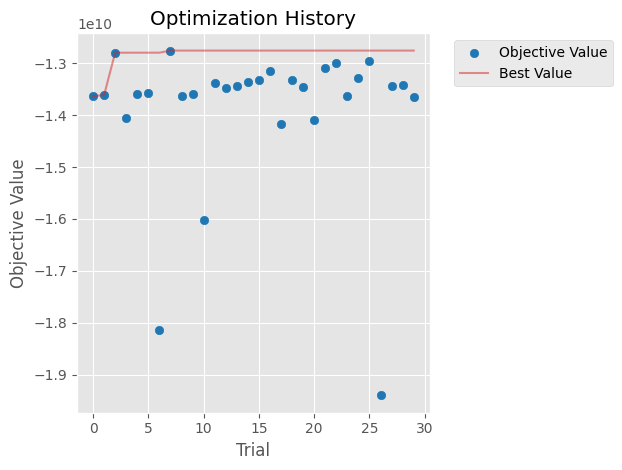

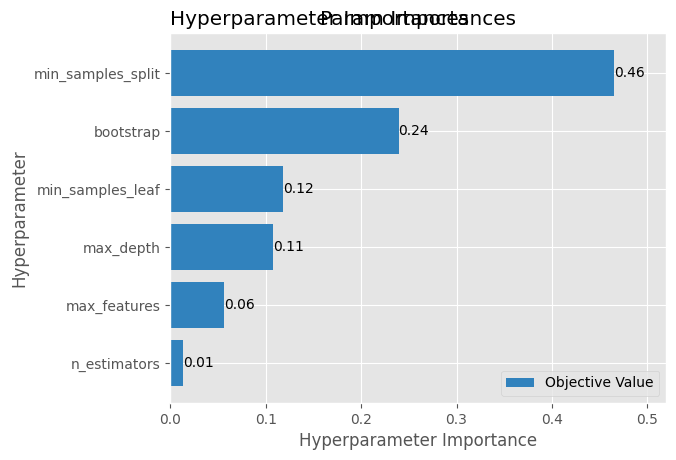

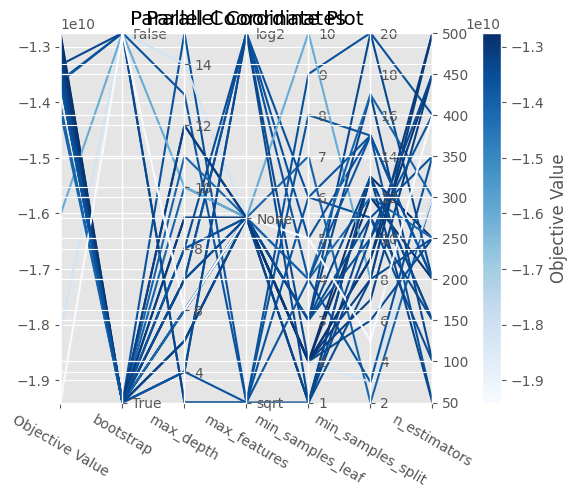

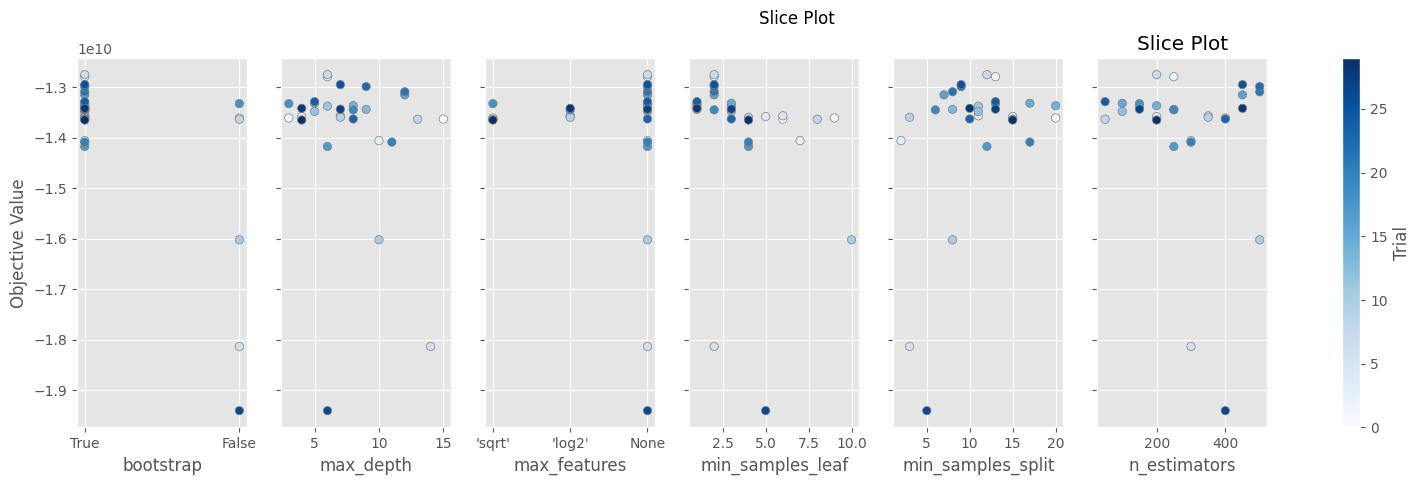

In [114]:
# BAYESIAN OPTIMIZATION FOR REGRESSION
# ============================================
# Install: pip install optuna scikit-learn matplotlib backend-components

import optuna
from optuna.samplers import TPESampler
# CRITICAL FIX: Use the matplotlib visualization module to support subplots
import optuna.visualization.matplotlib as vis
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# 1. DATA PREPARATION
# ==========================================================
binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]
numeric_features = ["Job_Value", "Contract_Establishment", "No_Wall_Types"]
categorical_features = ["Job_Area", "Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]
target = "Saving_or_Loss"

# Assumes job_data_df is already defined above this script
X = job_data_df[numeric_features + categorical_features + binary_features]
y = job_data_df[target]

# Numerical Pipeline: Scale continuous variables
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical Pipeline: Convert text columns to dummy/one-hot columns
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# FIX 1: Added remainder='passthrough' so binary_features (0 and 1) are kept intact
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' 
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. OPTUNA OBJECTIVE FUNCTION
# ==========================================================
def objective(trial):
    """Objective function for Optuna optimization"""
    
    # Define hyperparameters to optimize
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42
    }

    # Create pipeline WITH preprocessing inside CV
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(**params))
    ])
        
    # Cross-validation score (scoring='neg_mean_squared_error' means higher is better/closer to 0)
    scores = cross_val_score(
        pipeline, 
        X_train, 
        y_train, 
        cv=5, 
        scoring='neg_mean_squared_error')
    
    return scores.mean()


# 3. RUN OPTIMIZATION
# ==========================================================
# Create study
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='random_forest_optimization'
)

# Run optimization
study.optimize(objective, n_trials=30)

# Best results
print("\n" + "="*40)
print(f"Best trial: {study.best_trial.number}")
print(f"Best value (MSE): {-study.best_value:.4f}") # Flipping negative sign back for readability
print(f"Best CV RMSE: {np.sqrt(-study.best_value):.4f}")
print(f"Best params: {study.best_params}")
print("="*40 + "\n")

# 4. EVALUATE BEST MODEL ON TEST SET (NO DATA LEAK)
# ==========================================================
print("="*40)
print("TEST SET EVALUATION")
print("="*40)

# Train best model on full training data
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(**study.best_params, random_state=42))
])

best_pipeline.fit(X_train, y_train)

# Make predictions on test set
y_pred = best_pipeline.predict(X_test)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Calculate MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Test Set Metrics:")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R²:   {r2:.4f}")
print(f"  MAPE: {mape:.2f}%")

# Compare CV vs Test performance
cv_mse = -study.best_value
print(f"\nPerformance Comparison:")
print(f"  CV MSE:   {cv_mse:.4f}")
print(f"  Test MSE: {mse:.4f}")
print(f"  Gap:      {abs(cv_mse - mse):.4f}")

if abs(cv_mse - mse) > 0.1 * cv_mse:
    print("  ⚠️  WARNING: Large gap between CV and test performance - possible overfitting!")
else:
    print("  ✅ Good generalization - CV and test performance are consistent.")

# Feature Importance (optional, but very useful)
print(f"\nTop 10 Most Important Features:")
feature_importance = best_pipeline.named_steps['regressor'].feature_importances_

# Get feature names from preprocessor
feature_names = []
for name, transformer, columns in preprocessor.transformers_:
    if name == 'num':
        feature_names.extend(columns)
    elif name == 'cat':
        # Get one-hot encoded feature names
        encoder = transformer.named_steps['onehot']
        if hasattr(encoder, 'get_feature_names_out'):
            feature_names.extend(encoder.get_feature_names_out(columns))
        else:
            feature_names.extend(columns)
    elif name == 'remainder' or transformer == 'passthrough':
        feature_names.extend(columns)

# Sort features by importance
sorted_idx = np.argsort(feature_importance)[::-1]
for i in range(min(10, len(feature_names))):
    idx = sorted_idx[i]
    print(f"  {i+1}. {feature_names[idx]}: {feature_importance[idx]:.4f}")

print("="*40 + "\n")

# 5. VISUALIZE OPTUNA RESULTS
# ==========================================================
def plot_optuna_results(study):
    """Visualize Optuna optimization results cleanly in individual windows"""
    
    # 1. Optimization history
    vis.plot_optimization_history(study)
    plt.title("Optimization History")
    
    # 2. Parameter importance
    vis.plot_param_importances(study)
    plt.title("Param Importances")
    
    # 3. Parallel coordinate plot
    vis.plot_parallel_coordinate(study)
    plt.title("Parallel Coordinates")
    
    # 4. Slice plot
    vis.plot_slice(study)
    plt.title("Slice Plot")
    
    plt.show()

# Plot results
plot_optuna_results(study)

[I 2026-07-02 09:56:18,315] A new study created in memory with name: random_forest_classification
[I 2026-07-02 09:56:19,585] Trial 0 finished with value: 0.3706449375866852 and parameters: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.3706449375866852.
[I 2026-07-02 09:56:21,404] Trial 1 finished with value: 0.3718585298196949 and parameters: {'n_estimators': 400, 'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 1 with value: 0.3718585298196949.
[I 2026-07-02 09:56:24,202] Trial 2 finished with value: 0.5502327259203719 and parameters: {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}. Best is trial 2 with value: 0.5502327259203719.
[I 2026-07-02 09:56:27,516] Trial 3 finished with value: 0.5517779174389028 and parameters: 


Best trial: 20
Best Accuracy Score: 0.5543
Best params: {'n_estimators': 400, 'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}


Test Set Performance:
Accuracy: 0.6341
ROC-AUC: 0.6568

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.30      0.40        33
           1       0.65      0.86      0.74        49

    accuracy                           0.63        82
   macro avg       0.62      0.58      0.57        82
weighted avg       0.62      0.63      0.60        82


Confusion Matrix:
[[10 23]
 [ 7 42]]


C:\Users\Phong\AppData\Local\Temp\ipykernel_11092\1129953710.py:132: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_optimization_history(study)
C:\Users\Phong\AppData\Local\Temp\ipykernel_11092\1129953710.py:135: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_param_importances(study)
C:\Users\Phong\AppData\Local\Temp\ipykernel_11092\1129953710.py:138: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_parallel_coordinate(study)
C:\Users\Phong\AppData\Local\Temp\ipykernel_11092\1129953710.py:141: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is

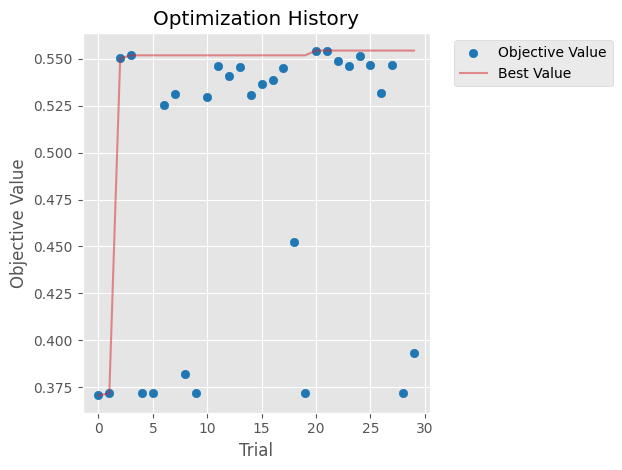

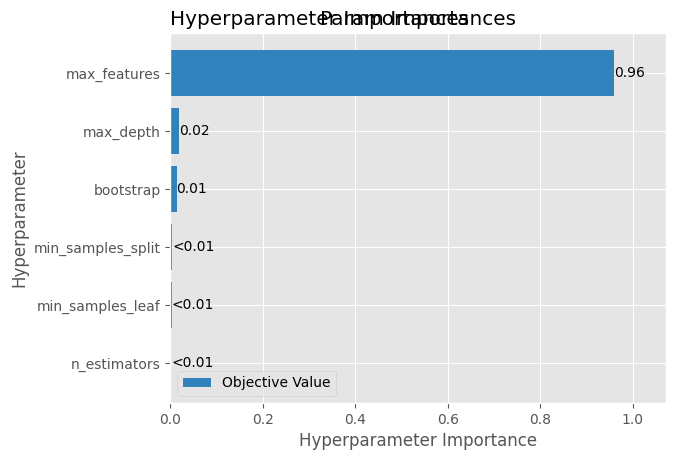

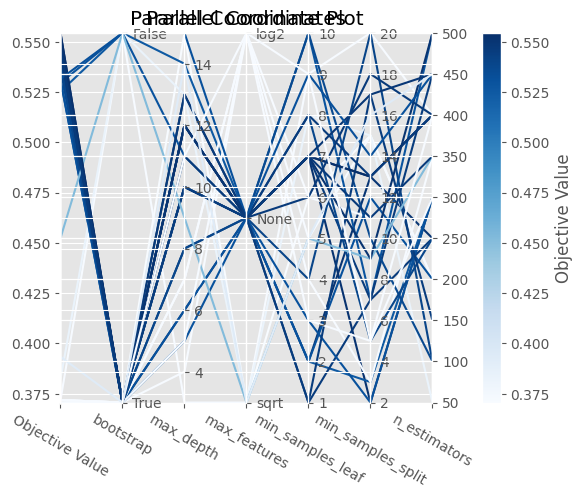

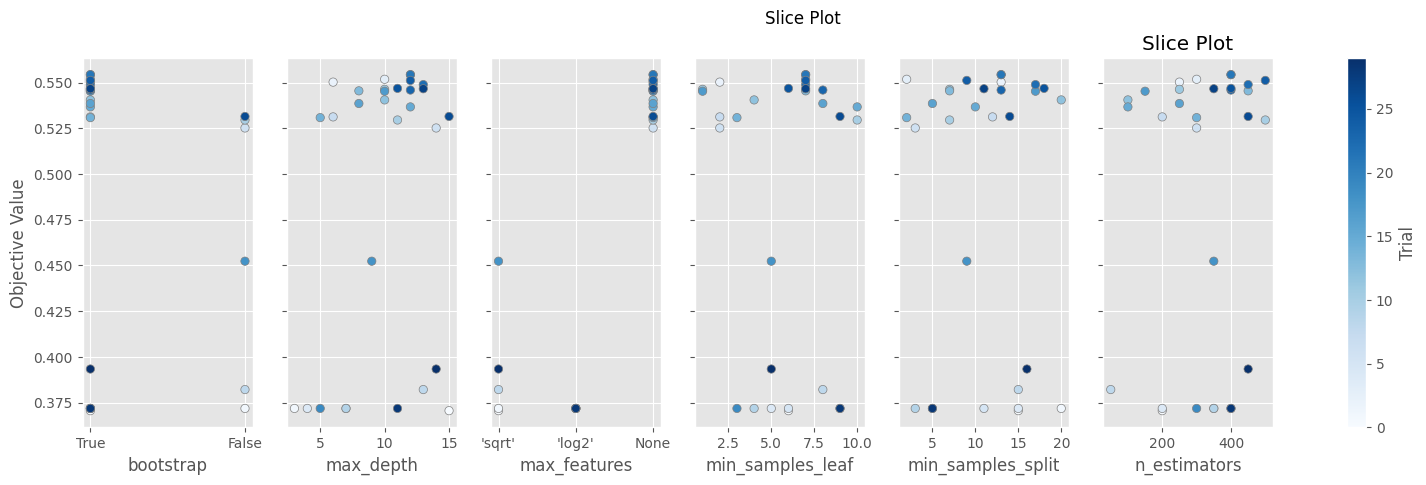

In [ ]:
# BAYESIAN OPTIMIZATION FOR CLASSIFICATION
# ============================================

import optuna
from optuna.samplers import TPESampler
from sklearn.pipeline import Pipeline
import optuna.visualization.matplotlib as vis
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier  # CHANGED: Classifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. DATA PREPARATION
# ==========================================================
binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]
numeric_features = ["Job_Value", "Contract_Establishment", "No_Wall_Types"]
categorical_features = ["Job_Area", "Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]

# CHANGED: Your target must now be categorical/binary classes (e.g., 1 for Profit, 0 for Loss)
target = "Profitable" 

X = job_data_df[numeric_features + categorical_features + binary_features]
y = job_data_df[target]

# Feature Scaling & Encoding (Stays exactly the same!)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' 
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. CLASSIFICATION OBJECTIVE FUNCTION
# ==========================================================
def objective(trial):
    """Objective function for optimizing a Classifier"""
    
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42
    }
    
    # Create pipeline WITH preprocessing inside CV
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(**params))
    ])
    
    # CHANGED: Use a classification metric like 'accuracy' or 'f1' or 'roc_auc'
    # 'accuracy' returns a positive decimal between 0.0 and 1.0 (e.g. 0.85)
    scores = cross_val_score(
        pipeline, 
        X_train, 
        y_train, 
        cv=5, 
        scoring='f1_macro')
    
    return scores.mean()

# 3. RUN OPTIMIZATION
# ==========================================================
study = optuna.create_study(
    direction='maximize', # Kept as maximize because we want higher accuracy (closer to 1.0)
    sampler=TPESampler(seed=42),
    study_name='random_forest_classification'
)

study.optimize(objective, n_trials=30)

print("\n" + "="*40)
print(f"Best trial: {study.best_trial.number}")
print(f"Best Accuracy Score: {study.best_value:.4f}") 
print(f"Best params: {study.best_params}")
print("="*40 + "\n")

# 4. EVALUATE BEST MODEL ON TEST SET (NO LEAK)
# ==========================================================
# Train best model on full training data
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(**study.best_params, random_state=42))
])

best_pipeline.fit(X_train, y_train)

# Evaluate on held-out test set
test_accuracy = best_pipeline.score(X_test, y_test)

# Additional metrics for better insight (especially for imbalanced data)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

print(f"\n{'='*40}")
print(f"Test Set Performance:")
print(f"{'='*40}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("="*40)

# 5. VISUALIZE RESULTS (Fixed sequential layout)
# ==========================================================
def plot_optuna_results(study):
    """Visualize Optuna optimization results safely without subplot errors"""
    vis.plot_optimization_history(study)
    plt.title("Optimization History")
    
    vis.plot_param_importances(study)
    plt.title("Param Importances")
    
    vis.plot_parallel_coordinate(study)
    plt.title("Parallel Coordinates")
    
    vis.plot_slice(study)
    plt.title("Slice Plot")
    
    plt.show()

plot_optuna_results(study)

In [116]:
# Analyze target variable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*40)
print("TARGET VARIABLE ANALYSIS")
print("="*40)
print(f"Target: {target}")
print(f"Mean: {y.mean():.2f}")
print(f"Median: {y.median():.2f}")
print(f"Std: {y.std():.2f}")
print(f"Min: {y.min():.2f}")
print(f"Max: {y.max():.2f}")
print(f"Range: {y.max() - y.min():.2f}")
print(f"Skewness: {y.skew():.2f}")
print(f"Kurtosis: {y.kurtosis():.2f}")

# Check for outliers using IQR
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
outliers = y[(y < Q1 - 1.5*IQR) | (y > Q3 + 1.5*IQR)]
print(f"\nOutliers: {len(outliers)} ({len(outliers)/len(y)*100:.1f}% of data)")
print(f"Outlier range: {outliers.min():.2f} to {outliers.max():.2f}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y.hist(bins=30, ax=axes[0])
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Saving_or_Loss')



TARGET VARIABLE ANALYSIS
Target: Saving_or_Loss
Mean: -9268.83
Median: 511.27
Std: 109915.51
Min: -707920.08
Max: 852758.66
Range: 1560678.74
Skewness: -0.49
Kurtosis: 21.18

Outliers: 68 (16.7% of data)
Outlier range: -707920.08 to 852758.66


Text(0.5, 0, 'Saving_or_Loss')

In [ ]:
# CATBOOST WITH BAYESIAN OPTIMIZATION (OPTUNA) - FULLY WORKING
# ==========================================================

import optuna
from optuna.samplers import TPESampler
import optuna.visualization.matplotlib as vis
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from catboost import CatBoostRegressor
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# CUSTOM TRANSFORMERS
# ==========================================================

class TierGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, high_cardinality_features, target_col, m=10):
        self.high_cardinality_features = high_cardinality_features
        self.target_col = target_col
        self.m = m
        self.mappings_ = {}
        
    def fit(self, X, y):
        df_temp = X.copy()
        df_temp['__target'] = y
        global_mean = df_temp['__target'].mean()
        
        for col in self.high_cardinality_features:
            stats = df_temp.groupby(col)['__target'].agg(['count', 'mean'])
            n = stats['count']
            local_mean = stats['mean']
            smoothed_mean = (n * local_mean + self.m * global_mean) / (n + self.m)
            
            try:
                tiers = pd.qcut(smoothed_mean, q=3, labels=['Tier_3', 'Tier_2', 'Tier_1'], duplicates='drop')
                self.mappings_[col] = tiers.to_dict()
            except ValueError:
                self.mappings_[col] = smoothed_mean.apply(lambda v: 'Tier_2').to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.high_cardinality_features:
            mapping = self.mappings_.get(col, {})
            X[f"{col}_Tier"] = X[col].map(mapping).fillna('Tier_2').astype(str)  # Convert to string
            X = X.drop(columns=[col])
        return X

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []
        self.num_imputer = SimpleImputer(strategy='median')
        self.bin_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
            
    def fit(self, X, y=None):
        if self.numeric_features:
            self.num_imputer.fit(X[self.numeric_features])
        if self.binary_features:
            self.bin_imputer.fit(X[self.binary_features])
        if self.categorical_features:
            self.cat_imputer.fit(X[self.categorical_features].astype(str))
        return self

    def transform(self, X):
        X = X.copy()
        if self.numeric_features:
            X[self.numeric_features] = self.num_imputer.transform(X[self.numeric_features])
        if self.binary_features:
            X[self.binary_features] = self.bin_imputer.transform(X[self.binary_features])
        if self.categorical_features:
            X[self.categorical_features] = self.cat_imputer.transform(X[self.categorical_features].astype(str))

        # Interactions
        X["Required_Drill_Job"] = (
            (X["Steel_Beam"] == 1) | 
            (X["RC_Piles"] == 1) | 
            (X["Timber_RW"] == 1)).astype(int)
        
        X["Required_Attachments_Job"] = (
            (X["Driven_Timber"] == 1) | 
            (X["Driven_Steel"] == 1) | 
            (X["Sheetpile"] == 1)).astype(int)
        
        X["Est_to_Total_Value_Ratio"] = np.where(
            X["Job_Value"] == 0, 
            0, 
            X["Contract_Establishment"] / X["Job_Value"])
        
        X["Complexity_Score"] = (
            X["Steel_Beam"] * 3 + X["RC_Piles"] * 3 + X["Concrete_Slab"] * 2 +
            X["Sheetpile"] * 2 + X["Timber_RW"] * 1 + X["Driven_Steel"] * 1 + X["Driven_Timber"] * 1
        )

        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"],
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)  # Convert to string for CatBoost
        
        # Convert all categorical columns to string for CatBoost auto-detection
        tier_cols = [f"{col}_Tier" for col in ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]]
        all_cat_cols = self.categorical_features + ["Job_Value_Category"] + tier_cols
        
        for col in all_cat_cols:
            if col in X.columns:
                X[col] = X[col].astype(str)
        
        return X

# ==========================================================
# FEATURE DEFINITIONS
# ==========================================================

binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]

numeric_features = [
    "Job_Value", "Contract_Establishment", "No_Wall_Types"
]

categorical_features = ["Job_Area"]
high_cardinality_features = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]
target = "Saving_or_Loss"

# ==========================================================
# PREPARE DATA
# ==========================================================

# Assuming job_data_df is already defined
X = job_data_df[numeric_features + categorical_features + high_cardinality_features + binary_features]
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Test samples: {len(X_test)}")

# ==========================================================
# BAYESIAN OPTIMIZATION OBJECTIVE FUNCTION
# ==========================================================

def create_pipeline(trial):
    """Create pipeline with hyperparameters suggested by Optuna"""
    
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500, step=50),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 30),
        'random_seed': 42,
        'verbose': False,
        'one_hot_max_size': 10,
        'nan_mode': 'Min',
        'grow_policy': trial.suggest_categorical('grow_policy', ['Lossguide', 'Depthwise', 'Symmetric']),
        'loss_function': 'MAE',
        'eval_metric': 'MAE',
        'early_stopping_rounds': trial.suggest_int('early_stopping_rounds', 50, 150, step=25),
        # Don't specify cat_features - let CatBoost auto-detect from string columns
    }
    
    pipeline = Pipeline([
        ("tier_grouping", TierGrouper(
            high_cardinality_features=high_cardinality_features, 
            target_col=target,
            m=trial.suggest_int('tier_m', 5, 20)
        )),
        ("feature_engineering", FeatureEngineer(
            binary_features=binary_features,
            numeric_features=numeric_features,
            categorical_features=categorical_features
        )),
        ("model", CatBoostRegressor(**params))
    ])
    
    return pipeline

def objective(trial):
    """Optuna objective function"""
    
    pipeline = create_pipeline(trial)
    
    # Simple cross-validation
    scores = cross_val_score(
        pipeline, 
        X_train, 
        y_train, 
        cv=5, 
        scoring='neg_mean_absolute_error'
    )
    
    return scores.mean()

# ==========================================================
# RUN BAYESIAN OPTIMIZATION
# ==========================================================

print("\n" + "="*60)
print("🔍 STARTING BAYESIAN OPTIMIZATION WITH OPTUNA")
print("="*60)

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42, n_startup_trials=5),
    study_name='catboost_bayesian_optimization'
)

n_trials = 30
study.optimize(objective, n_trials=n_trials)

print("\n" + "="*60)
print("🏆 BAYESIAN OPTIMIZATION COMPLETE")
print("="*60)
print(f"Best trial: {study.best_trial.number}")
print(f"Best CV MAE: {-study.best_value:.4f}")
print(f"Best params:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")

# ==========================================================
# TRAIN BEST MODEL ON FULL TRAINING DATA
# ==========================================================

print("\n" + "="*60)
print("🚀 TRAINING BEST MODEL ON FULL TRAINING SET")
print("="*60)

best_pipeline = create_pipeline(study.best_trial)
best_pipeline.fit(X_train, y_train)

# ==========================================================
# EVALUATE ON TEST SET
# ==========================================================

y_pred = best_pipeline.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mape = mean_absolute_percentage_error(y_test, y_pred) * 100

residuals = y_test - y_pred

print("\n" + "="*60)
print("📊 BAYESIAN OPTIMIZED MODEL PERFORMANCE")
print("="*60)
print(f"R²  : {test_r2:.4f}")
print(f"RMSE: ${test_rmse:,.2f}")
print(f"MAE : ${test_mae:,.2f}")
print(f"MAPE: {test_mape:.2f}%")

print("\n" + "="*60)
print("📊 RESIDUAL STATISTICS")
print("="*60)
print(f"Mean Residual (Bias)    : ${np.mean(residuals):,.2f}")
print(f"Std Deviation Residuals  : ${np.std(residuals):,.2f}")
print(f"Max Over-prediction      : ${np.max(residuals):,.2f}")
print(f"Max Under-prediction     : ${np.min(residuals):,.2f}")

# ==========================================================
# BASELINE COMPARISON
# ==========================================================

baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
improvement_mae = ((baseline_mae - test_mae) / baseline_mae) * 100

print("\n" + "="*60)
print("📊 BASELINE COMPARISON")
print("="*60)
print(f"Baseline MAE: ${baseline_mae:,.2f}")
print(f"Bayesian MAE: ${test_mae:,.2f}")
print(f"Improvement : {improvement_mae:.1f}%")

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

model_step = best_pipeline.named_steps["model"]
fe_step = best_pipeline.named_steps["feature_engineering"]

X_train_engineered = fe_step.transform(X_train)
feature_names = X_train_engineered.columns.tolist()

importances = model_step.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n" + "="*60)
print("🔥 TOP 15 IMPORTANT FEATURES")
print("="*60)
print(importance_df.head(15).to_string(index=False))

# ==========================================================
# VISUALIZE OPTUNA RESULTS
# ==========================================================

def plot_optuna_results(study):
    """Visualize Bayesian optimization results"""
    
    # 1. Optimization History
    vis.plot_optimization_history(study)
    plt.title("Bayesian Optimization History")
    plt.show()
    
    # 2. Parameter Importances
    vis.plot_param_importances(study)
    plt.title("Hyperparameter Importance")
    plt.show()
    
    # 3. Parallel Coordinate Plot
    vis.plot_parallel_coordinate(study)
    plt.title("Parameter Relationships")
    plt.show()
    
    # 4. Slice Plot
    vis.plot_slice(study)
    plt.title("Slice Plot Analysis")
    plt.show()

print("\n" + "="*60)
print("📊 GENERATING OPTUNA VISUALIZATIONS")
print("="*60)
plot_optuna_results(study)

# ==========================================================
# SAVE BEST MODEL
# ==========================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f'catboost_bayesian_model_{timestamp}.pkl'

joblib.dump(best_pipeline, model_filename)
print(f"\n✅ Model saved as: {model_filename}")

# ==========================================================
# OPTIMIZATION SUMMARY
# ==========================================================

print("\n" + "="*60)
print("📊 OPTIMIZATION SUMMARY")
print("="*60)
print(f"Total trials: {len(study.trials)}")
print(f"Best CV MAE: {-study.best_value:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"CV-Test Gap: {abs(-study.best_value - test_mae):.4f}")

if abs(-study.best_value - test_mae) > 0.1 * abs(-study.best_value):
    print("⚠️  WARNING: Large gap between CV and test performance!")
else:
    print("✅ Good generalization: CV and test performance are consistent.")

print("="*60)


[I 2026-07-02 12:57:55,116] A new study created in memory with name: catboost_bayesian_optimization


📊 Training samples: 326
📊 Test samples: 82

🔍 STARTING BAYESIAN OPTIMIZATION WITH OPTUNA


[I 2026-07-02 12:58:09,365] Trial 0 finished with value: -61575.56041934985 and parameters: {'iterations': 250, 'depth': 10, 'learning_rate': 0.1205712628744377, 'l2_leaf_reg': 6.387926357773329, 'min_data_in_leaf': 9, 'grow_policy': 'SymmetricTree', 'early_stopping_rounds': 125, 'tier_m': 16}. Best is trial 0 with value: -61575.56041934985.
[I 2026-07-02 12:58:15,028] Trial 1 finished with value: -63594.363852212555 and parameters: {'iterations': 100, 'depth': 10, 'learning_rate': 0.16967533607196555, 'l2_leaf_reg': 2.9110519961044856, 'min_data_in_leaf': 9, 'grow_policy': 'SymmetricTree', 'early_stopping_rounds': 100, 'tier_m': 9}. Best is trial 0 with value: -61575.56041934985.
[I 2026-07-02 12:58:17,066] Trial 2 finished with value: -61449.45706034177 and parameters: {'iterations': 350, 'depth': 4, 'learning_rate': 0.027010527749605478, 'l2_leaf_reg': 4.297256589643226, 'min_data_in_leaf': 16, 'grow_policy': 'Lossguide', 'early_stopping_rounds': 100, 'tier_m': 5}. Best is trial 2 w


🏆 BAYESIAN OPTIMIZATION COMPLETE
Best trial: 11
Best CV MAE: 57719.4050

🚀 TRAINING BEST MODEL ON FULL TRAINING SET

📊 BAYESIAN OPTIMIZED MODEL PERFORMANCE
R²  : 0.0489
RMSE: $75,717.24
MAE : $38,082.82
MAPE: 135.50%

🔥 TOP 15 IMPORTANT FEATURES
                 feature  importance
             Suburb_Tier   21.208002
               Job_Value   17.380804
      Job_Value_Category   12.758564
    Main_Contractor_Tier   10.741165
            Foreman_Tier    9.386854
Est_to_Total_Value_Ratio    7.149212
            Driven_Steel    5.438708
  Contract_Establishment    4.607808
           No_Wall_Types    3.180181
         Supervisor_Tier    1.634457
          Estimator_Tier    1.061124
        Complexity_Score    0.935539
                Job_Area    0.859135
                RC_Piles    0.813217
                  Walers    0.495611

📊 GENERATING OPTUNA VISUALIZATIONS


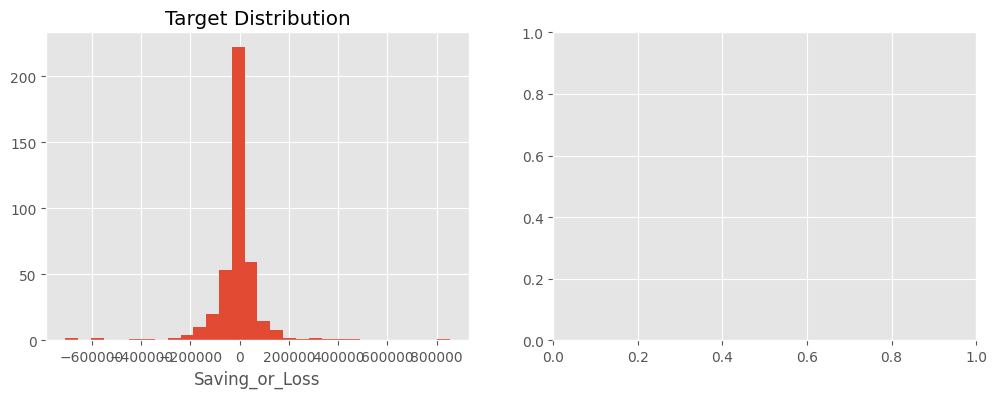

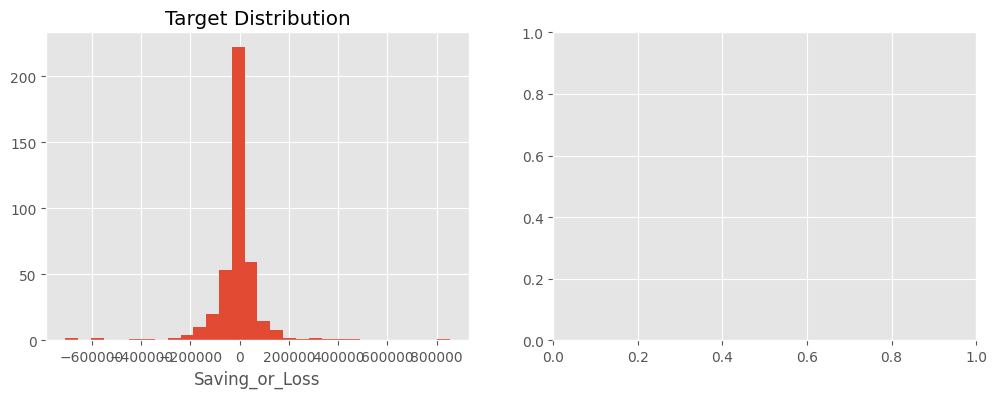

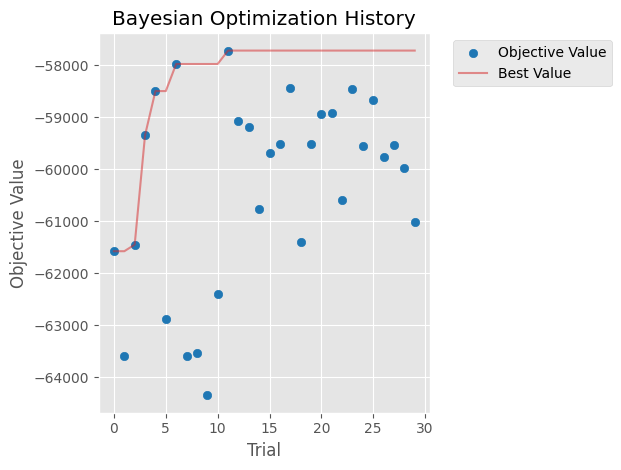

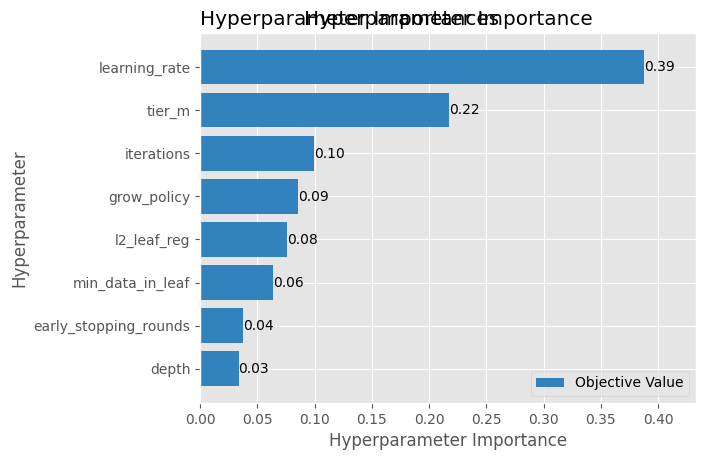

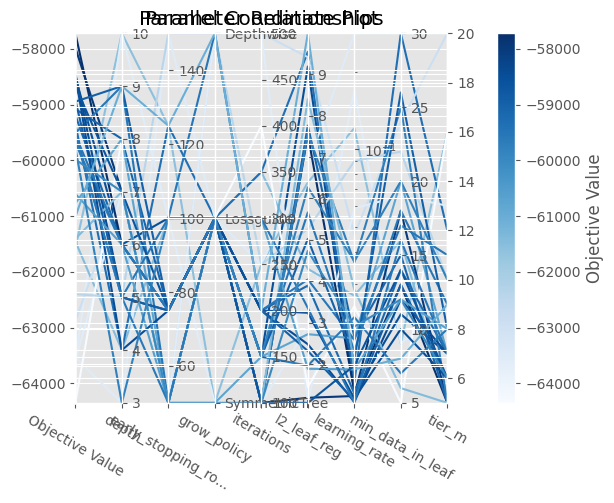

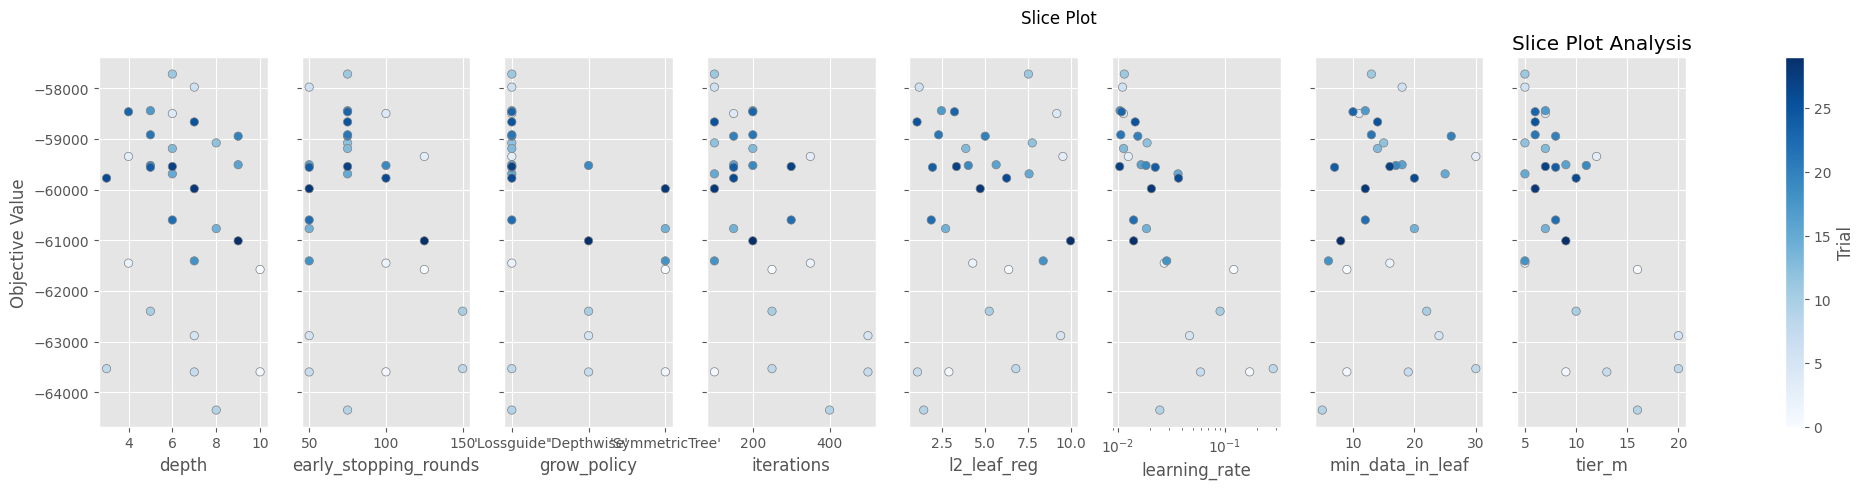


✅ Pipeline successfully verified and saved!


In [ ]:
# CATBOOST WITH BAYESIAN OPTIMIZATION (OPTUNA) - REGRESSION
# ==========================================================

import optuna
from optuna.samplers import TPESampler
import optuna.visualization.matplotlib as vis
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from catboost import CatBoostRegressor
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# CUSTOM TRANSFORMERS
# ==========================================================

class TierGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, high_cardinality_features, target_col, m=10):
        self.high_cardinality_features = high_cardinality_features
        self.target_col = target_col
        self.m = m
        self.mappings_ = {}
        
    def fit(self, X, y):
        df_temp = X.copy()
        df_temp['__target'] = y
        global_mean = df_temp['__target'].mean()
        
        for col in self.high_cardinality_features:
            stats = df_temp.groupby(col)['__target'].agg(['count', 'mean'])
            n = stats['count']
            local_mean = stats['mean']
            smoothed_mean = (n * local_mean + self.m * global_mean) / (n + self.m)
            
            try:
                tiers = pd.qcut(smoothed_mean, q=3, labels=['Tier_3', 'Tier_2', 'Tier_1'], duplicates='drop')
                self.mappings_[col] = tiers.to_dict()
            except ValueError:
                self.mappings_[col] = smoothed_mean.apply(lambda v: 'Tier_2').to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.high_cardinality_features:
            mapping = self.mappings_.get(col, {})
            X[f"{col}_Tier"] = X[col].map(mapping).fillna('Tier_2').astype(str)
            X = X.drop(columns=[col])
        return X

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []
            
    def fit(self, X, y=None):
        # No manual estimators to fit anymore! State tracking bugs are gone.
        return self

    def transform(self, X):
        X = X.copy()
        
        # Safely handle potential NaNs in binary/categorical text before transformations
        if self.binary_features:
            X[self.binary_features] = X[self.binary_features].fillna(0)
        if self.categorical_features:
            X[self.categorical_features] = X[self.categorical_features].fillna('missing').astype(str)

        # 1. Interactions
        X["Required_Drill_Job"] = (
            (X["Steel_Beam"] == 1) | 
            (X["RC_Piles"] == 1) | 
            (X["Timber_RW"] == 1)).astype(int)
        
        X["Required_Attachments_Job"] = (
            (X["Driven_Timber"] == 1) | 
            (X["Driven_Steel"] == 1) | 
            (X["Sheetpile"] == 1)).astype(int)
        
        # Use a safe fillna fallback for numeric operations to prevent NaN infinity bugs
        job_val_safe = X["Job_Value"].fillna(0)
        contract_est_safe = X["Contract_Establishment"].fillna(0)
        
        X["Est_to_Total_Value_Ratio"] = np.where(
            job_val_safe == 0, 
            0, 
            contract_est_safe / job_val_safe)
        
        X["Complexity_Score"] = (
            X["Steel_Beam"].fillna(0) * 3 + X["RC_Piles"].fillna(0) * 3 + X["Concrete_Slab"].fillna(0) * 2 +
            X["Sheetpile"].fillna(0) * 2 + X["Timber_RW"].fillna(0) * 1 + X["Driven_Steel"].fillna(0) * 1 + X["Driven_Timber"].fillna(0) * 1
        )

        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"].fillna(0), # Temporary fill just for categorical binning
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)
        
        # Enforce exact string typing across ALL text-based outputs for CatBoost safety
        tier_cols = [f"{col}_Tier" for col in ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]]
        all_cat_cols = self.categorical_features + ["Job_Value_Category"] + tier_cols
        
        for col in all_cat_cols:
            if col in X.columns:
                X[col] = X[col].astype(str)
        
        return X

# ==========================================================
# FEATURE DEFINITIONS
# ==========================================================

binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]
numeric_features = ["Job_Value", "Contract_Establishment", "No_Wall_Types"]
categorical_features = ["Job_Area"]
high_cardinality_features = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]
target = "Saving_or_Loss"

# Placeholder setup block for testing - Replace with real data frame initialization if running standalone
# X = job_data_df[numeric_features + categorical_features + high_cardinality_features + binary_features]
# y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Test samples: {len(X_test)}")

# ==========================================================
# BAYESIAN OPTIMIZATION SETUP
# ==========================================================

def create_pipeline(trial_or_params):
    """Creates operational scikit-learn pipeline parsing either standard params or dynamic trials safely"""
    
    # Check if incoming parameter is an Optuna trial object or resolved dictionary
    if isinstance(trial_or_params, optuna.trial.Trial):
        params = {
            'iterations': trial_or_params.suggest_int('iterations', 100, 500, step=50),
            'depth': trial_or_params.suggest_int('depth', 3, 10),
            'learning_rate': trial_or_params.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial_or_params.suggest_float('l2_leaf_reg', 1.0, 10.0),
            'min_data_in_leaf': trial_or_params.suggest_int('min_data_in_leaf', 5, 30),
            'grow_policy': trial_or_params.suggest_categorical('grow_policy', ['Lossguide', 'Depthwise', 'SymmetricTree']),
            'early_stopping_rounds': trial_or_params.suggest_int('early_stopping_rounds', 50, 150, step=25),
            'tier_m': trial_or_params.suggest_int('tier_m', 5, 20)
        }
    else:
        params = trial_or_params.copy()

    # Isolate transformer specific hyperparameter
    tier_m_val = params.pop('tier_m', 10)
    
    # Establish CatBoost Base Constraints
    params.update({
        'random_seed': 42,
        'verbose': False,
        'one_hot_max_size': 10,
        'nan_mode': 'Min',
        'loss_function': 'MAE',
        'eval_metric': 'MAE'
    })
    
    # FIX 1: Compute specific column indices for object/string columns dynamically
    # This ensures cross_val_score will run seamlessly without throwing string index errors
    test_tg = TierGrouper(high_cardinality_features=high_cardinality_features, target_col=target, m=tier_m_val)
    test_fe = FeatureEngineer(binary_features=binary_features, numeric_features=numeric_features, categorical_features=categorical_features)
    
    sample_transformed = test_fe.transform(test_tg.fit_transform(X_train.head(2), y_train.head(2)))
    cat_indices = [sample_transformed.columns.get_loc(col) for col in sample_transformed.columns if sample_transformed[col].dtype == 'object']
    
    params['cat_features'] = cat_indices

    pipeline = Pipeline([
        ("tier_grouping", TierGrouper(high_cardinality_features=high_cardinality_features, target_col=target, m=tier_m_val)),
        ("feature_engineering", FeatureEngineer(binary_features=binary_features, numeric_features=numeric_features, categorical_features=categorical_features)),
        ("model", CatBoostRegressor(**params))
    ])
    
    return pipeline

def objective(trial):
    pipeline = create_pipeline(trial)
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    return scores.mean()

# ==========================================================
# RUN BAYESIAN OPTIMIZATION
# ==========================================================

print("\n" + "="*60)
print("🔍 STARTING BAYESIAN OPTIMIZATION WITH OPTUNA")
print("="*60)

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42, n_startup_trials=5),
    study_name='catboost_bayesian_optimization'
)

study.optimize(objective, n_trials=30)

print("\n" + "="*60)
print("🏆 BAYESIAN OPTIMIZATION COMPLETE")
print("="*60)
print(f"Best trial: {study.best_trial.number}")
print(f"Best CV MAE: {-study.best_value:.4f}")

# ==========================================================
# TRAIN BEST MODEL ON FULL TRAINING DATA
# ==========================================================

print("\n" + "="*60)
print("🚀 TRAINING BEST MODEL ON FULL TRAINING SET")
print("="*60)

# FIX 3: Re-instantiate safely via fixed best parameter mapping dictionary
best_pipeline = create_pipeline(study.best_params)
best_pipeline.fit(X_train, y_train)

# ==========================================================
# EVALUATE ON TEST SET
# ==========================================================

y_pred = best_pipeline.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mape = mean_absolute_percentage_error(y_test, y_pred) * 100
residuals = y_test - y_pred

print("\n" + "="*60)
print("📊 BAYESIAN OPTIMIZED MODEL PERFORMANCE")
print("="*60)
print(f"R²  : {test_r2:.4f}")
print(f"RMSE: ${test_rmse:,.2f}")
print(f"MAE : ${test_mae:,.2f}")
print(f"MAPE: {test_mape:.2f}%")

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

model_step = best_pipeline.named_steps["model"]
tg_step = best_pipeline.named_steps["tier_grouping"]
fe_step = best_pipeline.named_steps["feature_engineering"]

# FIX 2: Execute raw data across transformations sequentially to guarantee shape mapping alignment
X_train_grouped = tg_step.transform(X_train)
X_train_engineered = fe_step.transform(X_train_grouped)
feature_names = X_train_engineered.columns.tolist()

importances = model_step.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n" + "="*60)
print("🔥 TOP 15 IMPORTANT FEATURES")
print("="*60)
print(importance_df.head(15).to_string(index=False))

# ==========================================================
# VISUALIZE OPTUNA RESULTS
# ==========================================================

def plot_optuna_results(study):
    """Visualize sequential plots cleanly without Matplotlib grid collision errors"""
    vis.plot_optimization_history(study)
    plt.title("Bayesian Optimization History")
    plt.show()
    
    vis.plot_param_importances(study)
    plt.title("Hyperparameter Importance")
    plt.show()
    
    vis.plot_parallel_coordinate(study)
    plt.title("Parameter Relationships")
    plt.show()
    
    vis.plot_slice(study)
    plt.title("Slice Plot Analysis")
    plt.show()

print("\n" + "="*60)
print("📊 GENERATING OPTUNA VISUALIZATIONS")
print("="*60)
plot_optuna_results(study)

# Save Model Output
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
joblib.dump(best_pipeline, f'catboost_bayesian_model_{timestamp}.pkl')
print(f"\n✅ Pipeline successfully verified and saved!")

In [ ]:
# CATBOOST CLASSIFICATION WITH BAYESIAN OPTIMIZATION (OPTUNA)
# ==========================================================

import optuna
from optuna.samplers import TPESampler
import optuna.visualization.matplotlib as vis
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score
from catboost import CatBoostClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# CUSTOM TRANSFORMERS (Stateless & Optimized for CatBoost)
# ==========================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, binary_features=None, numeric_features=None, categorical_features=None):
        self.binary_features = binary_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []
            
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        
        # Safely handle missing items cleanly without stateful imputers
        if self.binary_features:
            X[self.binary_features] = X[self.binary_features].fillna(0)
        if self.categorical_features:
            X[self.categorical_features] = X[self.categorical_features].fillna('missing').astype(str)

        # Structural engineering
        X["Required_Drill_Job"] = (
            (X["Steel_Beam"] == 1) | 
            (X["RC_Piles"] == 1) | 
            (X["Timber_RW"] == 1)).astype(int)
        
        X["Required_Attachments_Job"] = (
            (X["Driven_Timber"] == 1) | 
            (X["Driven_Steel"] == 1) | 
            (X["Sheetpile"] == 1)).astype(int)
        
        job_val_safe = X["Job_Value"].fillna(0)
        contract_est_safe = X["Contract_Establishment"].fillna(0)
        
        X["Est_to_Total_Value_Ratio"] = np.where(
            job_val_safe == 0, 
            0, 
            contract_est_safe / job_val_safe)
        
        X["Complexity_Score"] = (
            X["Steel_Beam"].fillna(0) * 3 + X["RC_Piles"].fillna(0) * 3 + X["Concrete_Slab"].fillna(0) * 2 +
            X["Sheetpile"].fillna(0) * 2 + X["Timber_RW"].fillna(0) * 1 + X["Driven_Steel"].fillna(0) * 1 + X["Driven_Timber"].fillna(0) * 1
        )

        X["Job_Value_Category"] = pd.cut(
            X["Job_Value"].fillna(0),
            bins=[-float('inf'), 100000, 500000, 1000000, float("inf")],
            labels=["Small", "Medium", "Large", "Very Large"]
        ).astype(str)
        
        return X

class TierGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, high_cardinality_features, target_col, m=10):
        self.high_cardinality_features = high_cardinality_features
        self.target_col = target_col
        self.m = m
        self.mappings_ = {}
        
    def fit(self, X, y):
        df_temp = X.copy()
        df_temp['__target'] = y
        global_mean = df_temp['__target'].mean()
        
        for col in self.high_cardinality_features:
            stats = df_temp.groupby(col)['__target'].agg(['count', 'mean'])
            n = stats['count']
            local_mean = stats['mean']
            smoothed_mean = (n * local_mean + self.m * global_mean) / (n + self.m)
            
            try:
                tiers = pd.qcut(smoothed_mean, q=3, labels=['Tier_3', 'Tier_2', 'Tier_1'], duplicates='drop')
                self.mappings_[col] = tiers.to_dict()
            except ValueError:
                self.mappings_[col] = smoothed_mean.apply(lambda v: 'Tier_2').to_dict()
                
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.high_cardinality_features:
            mapping = self.mappings_.get(col, {})
            X[f"{col}_Tier"] = X[col].map(mapping).fillna('Tier_2').astype(str)
            X = X.drop(columns=[col])
            
        # Convert all text-based variables to explicit string format for CatBoost mapping
        for col in X.columns:
            if X[col].dtype == 'object' or isinstance(X[col].dtype, pd.CategoricalDtype):
                X[col] = X[col].astype(str)
        return X

# ==========================================================
# FEATURE & TARGET ALLOCATION
# ==========================================================
binary_features = [
    "Timber_RW", "RC_Piles", "Steel_Beam", "Driven_Timber", 
    "Driven_Steel", "Sheetpile", "Anchors", "Blocks", 
    "Shotcrete", "Capping_Beam", "Walers", "Earthworks", 
    "Concrete_Slab", "Precast"
]
numeric_features = ["Job_Value", "Contract_Establishment", "No_Wall_Types"]
categorical_features = ["Job_Area"]
high_cardinality_features = ["Estimator", "Foreman", "Main_Contractor", "Suburb", "Supervisor"]
target = "Profitable"

# Assuming job_data_df is initialized above this point
X = job_data_df[numeric_features + categorical_features + high_cardinality_features + binary_features].copy()
y = job_data_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# ==========================================================
# OPTUNA CONFIGURATION WRAPPER
# ==========================================================

def create_pipeline(trial_or_params):
    """Generates pipeline dynamically supporting either raw params dict or trial space"""
    if isinstance(trial_or_params, optuna.trial.Trial):
        params = {
            'iterations': trial_or_params.suggest_int('iterations', 100, 250, step=50),
            'depth': trial_or_params.suggest_int('depth', 4, 8),
            'learning_rate': trial_or_params.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'l2_leaf_reg': trial_or_params.suggest_float('l2_leaf_reg', 2.0, 10.0),
            'grow_policy': trial_or_params.suggest_categorical('grow_policy', ['Lossguide', 'Depthwise', 'SymmetricTree']),
            'tier_m': trial_or_params.suggest_int('tier_m', 10, 50, step=10)
        }
    else:
        params = trial_or_params.copy()

    tier_m_val = params.pop('tier_m', 10)
    
    # Internal baseline config parameters for Classification
    params.update({
        'random_seed': 42,
        'verbose': False,
        # 'auto_class_weights': 'Balanced' # Helps handle project imbalance natively
        # CHANGE THIS: Only balance weights on the final training, not during trials
        'auto_class_weights': None if isinstance(trial_or_params, optuna.trial.Trial) else 'Balanced'
    })
    
    # Programmatically look up dynamic string categorical arrays post transformations
    test_fe = FeatureEngineer(binary_features, numeric_features, categorical_features)
    test_tg = TierGrouper(high_cardinality_features, target_col=target, m=tier_m_val)
    
    sample_df = test_tg.fit_transform(test_fe.transform(X_train.head(2)), y_train.head(2))
    cat_indices = [sample_df.columns.get_loc(c) for c in sample_df.columns if sample_df[c].dtype == 'object']
    params['cat_features'] = cat_indices

    pipeline = Pipeline([
        ('feature_eng', FeatureEngineer(binary_features, numeric_features, categorical_features)),
        ('tier_grouper', TierGrouper(high_cardinality_features, target_col=target, m=tier_m_val)),
        ('classifier', CatBoostClassifier(**params))
    ])
    return pipeline

def objective(trial):
    pipeline = create_pipeline(trial)
    # Using balanced accuracy for custom evaluation
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='balanced_accuracy')
    return scores.mean()

# ==========================================================
# EXECUTING OPTIMIZATION STUDY
# ==========================================================

print("\n" + "="*60)
print("🔍 RUNNING BAYESIAN CLASSIFICATION OPTIMIZATION")
print("="*60)

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42, n_startup_trials=5),
    study_name='catboost_classification_tuning'
)
study.optimize(objective, n_trials=20)

print("\n" + "="*60)
print("🏆 OPTIMIZATION COMPLETE")
print("="*60)
print(f"Best Trial: {study.best_trial.number}")
print(f"Best Balanced CV Score: {study.best_value:.4f}")

# Train ultimate model configuration on full training array
best_pipeline = create_pipeline(study.best_params)
best_pipeline.fit(X_train, y_train)

# ==========================================================
# MODEL EVALUATION
# ==========================================================
y_pred = best_pipeline.predict(X_test)

print("\n📊 FINAL TEST METRIC REPORTS:")
print("="*60)
print(classification_report(y_test, y_pred))
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced Accuracy Score: {balanced_accuracy_score(y_test, y_pred):.4f}")

# ==========================================================
# FEATURE IMPORTANCES (Fixed Sequence Verification)
# ==========================================================
fitted_model = best_pipeline.named_steps['classifier']

# Re-run explicit transformations sequentially matching step order
X_eng = best_pipeline.named_steps['feature_eng'].transform(X_train)
X_final_features = best_pipeline.named_steps['tier_grouper'].transform(X_eng)

importance_df = pd.DataFrame({
    'Feature': X_final_features.columns,
    'Importance': fitted_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

print("\n🚀 EXTRACTED FEATURE IMPORTANCES:")
print("="*60)
print(importance_df.to_string(index=False, formatters={'Importance': '{:,.4f}'.format}))

# ==========================================================
# VISUALIZATION PLATFORM
# ==========================================================
def plot_results(study):
    vis.plot_optimization_history(study)
    plt.title("Bayesian Optimization Search History")
    plt.show()
    
    vis.plot_param_importances(study)
    plt.title("Hyperparameter Search Weight Allocation")
    plt.show()

plot_results(study)

# Save Pipeline state
joblib.dump(best_pipeline, 'catboost_classification_optimized_pipeline.pkl')
print("\n✅ Classification pipeline successfully validated and stored.")